SPICE kernels support enabled
✓ Loaded kernel: kernels/de432s.bsp
✓ Loaded kernel: kernels/naif0012.tls
✓ Loaded kernel: kernels/pck00010.tpc
✓ Loaded kernel: kernels/gm_de432.tpc
✓ Loaded kernel: kernels/54509621_YR4.bsp
All SPICE kernels loaded successfully
✓ Earth ephemeris test successful
✓ Asteroid ephemeris test successful
✓ 2024 YR4 position at test date: [-97296372, -468764399, -6462949] km
Synodic Period: 1.205 years
Restricted Search Window:
  Departure: 2027-06-01 to 2029-01-31
  Arrival:   2027-12-01 to 2030-06-30
Using ONLY NASA SPICE kernels - NO hardcoded orbital parameters
2024 YR4 ASTEROID FLYBY MISSION DESIGN
RESTRICTED SEARCH WINDOW: 2027 JUNE - 2029 JANUARY
USING NASA SPICE KERNELS

Testing mission evaluation within restricted window using SPICE...
✓ Test mission successful!
  ΔV: 7.644 km/s
  TOF: 278 days
  Asteroid distance: 1.784 AU
  Asteroid orbital elements (from SPICE):
    Semi-major axis: 2.515 AU
    Eccentricity: 0.661
    Inclination: 3.41°

Generating 

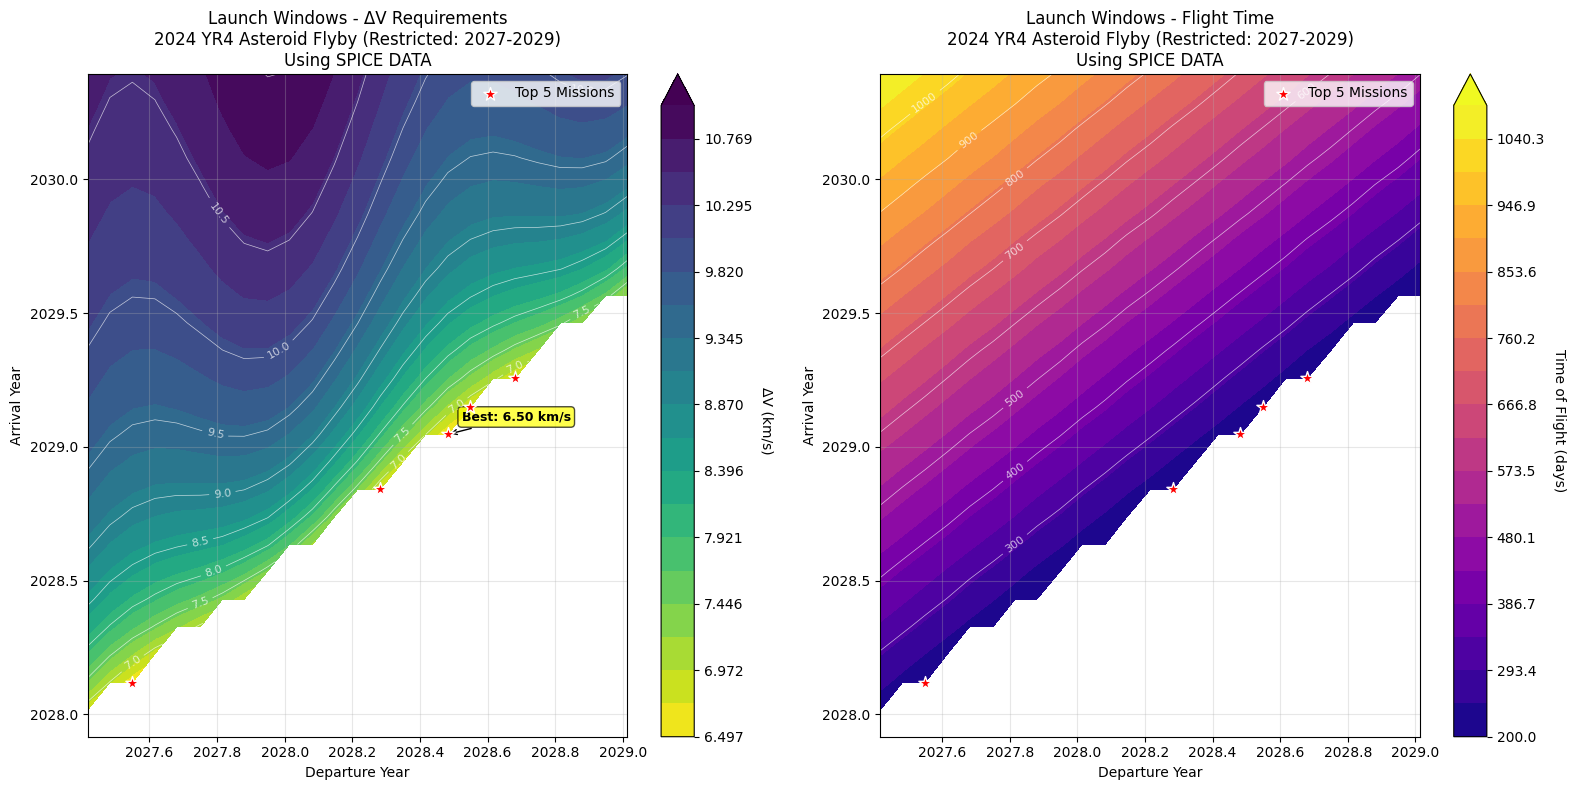


Top 5 mission opportunities (SPICE DATA):
1. Departure: 2028-06-25, Arrival: 2029-01-18, ΔV: 6.497 km/s, TOF: 207 days
2. Departure: 2027-07-19, Arrival: 2028-02-14, ΔV: 6.546 km/s, TOF: 209 days
3. Departure: 2028-09-06, Arrival: 2029-04-03, ΔV: 6.748 km/s, TOF: 209 days
4. Departure: 2028-07-19, Arrival: 2029-02-25, ΔV: 6.760 km/s, TOF: 220 days
5. Departure: 2028-04-13, Arrival: 2028-11-04, ΔV: 6.768 km/s, TOF: 204 days

Running genetic algorithm optimization for restricted window using SPICE DATA...

Starting Genetic Algorithm Optimization for Restricted Window using SPICE DATA...
Population size: 80
Max generations: 120
Search window: 2027-06-01 to 2029-01-31
Generation 0: Best ΔV = 7.232 km/s, Valid solutions = 47, Avg fitness = 0.095984
Generation 20: Best ΔV = 6.555 km/s, Valid solutions = 78, Avg fitness = 0.131572
Generation 40: Best ΔV = 6.456 km/s, Valid solutions = 77, Avg fitness = 0.133198
Generation 60: Best ΔV = 6.456 km/s, Valid solutions = 76, Avg fitness = 0.134124

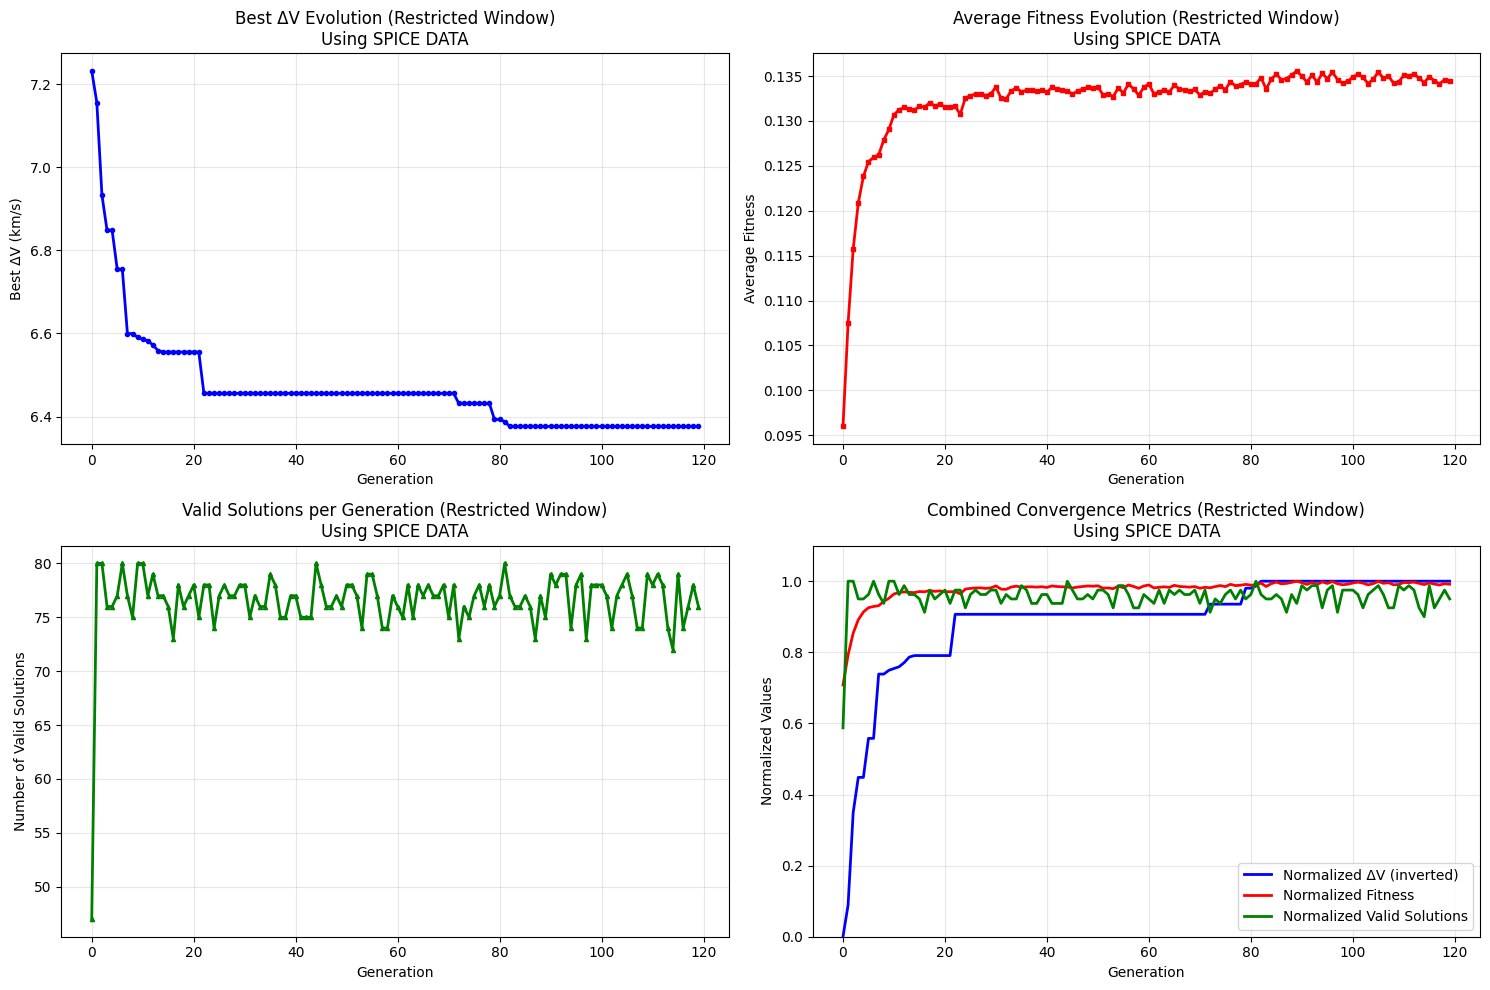


MISSION DESIGN SUMMARY - RESTRICTED WINDOW
USING NASA SPICE KERNELS
✓ Optimal mission found via Genetic Algorithm (Restricted Window):
  Departure Date: 2028-07-19
  Arrival Date: 2029-02-05
  Flight Time: 201 days
  Required ΔV: 6.376 km/s
  Mission Type: Asteroid 2024 YR4 Flyby
  Search Window: 2027 June - 2029 January
  Data Source: NASA SPICE Kernels (NO hardcoded parameters)
  Asteroid state at optimal arrival (from SPICE):
    Distance: 1.380 AU
    Velocity: 30.54 km/s

Synodic Period: 1.205 years
Restricted window mission design completed using SPICE KERNELS!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import scipy.optimize as opt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# SPICE imports
try:
    import spiceypy as spice
    SPICE_AVAILABLE = True
    print("SPICE kernels support enabled")
except ImportError:
    SPICE_AVAILABLE = False
    print("Warning: spiceypy not available, using simplified models")

class AsteroidMissionDesign:
    """
    2024 YR4 Asteroid Flyby Mission Design with NASA SPICE kernels support
    Uses ONLY SPICE .bsp data - no hardcoded orbital parameters
    """
    
    def __init__(self):
        """Initialize mission parameters and load SPICE kernels"""
        
        # Mission parameters - Restricted search window to 2027-2029
        self.mission_params = {
            'departure_start': datetime(2027, 6, 1),    # 2027 Haziran başı
            'departure_end': datetime(2029, 1, 31),     # 2029 Ocak sonu
            'arrival_start': datetime(2027, 12, 1),     # En erken varış: 2027 Aralık
            'arrival_end': datetime(2030, 6, 30),       # En geç varış: 2030 Haziran
            'population_size': 100,
            'max_generations': 150,
            'max_delta_v': 15.0,  # km/s - increased limit
            'asteroid_id': '54509621',  # 2024 YR4 NAIF ID
            'mu_sun': 132712440018.0,  # km^3/s^2
            'au': 149597870.7  # km
        }
        
        # SPICE kernels listesi
        self.kernel_files = [
            'kernels/de432s.bsp',           # Planetary ephemeris
            'kernels/naif0012.tls',        # Leap seconds kernel
            'kernels/pck00010.tpc',        # Planetary constants
            'kernels/gm_de432.tpc',        # Gravitational parameters
            'kernels/54509621_YR4.bsp'     # Asteroid ephemeris - MUST HAVE!
        ]
        
        # SPICE kernels yükleme
        self.spice_loaded = False
        if SPICE_AVAILABLE:
            self.load_spice_kernels()
        else:
            print("ERROR: SPICE kernels are REQUIRED for this version!")
            print("Please install spiceypy and provide the required .bsp files")
            raise ImportError("SPICE kernels are mandatory for this implementation")
        
        # Genetic Algorithm için
        self.population = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_history = []
        
        # Pork chop data
        self.pork_chop_data = None
        
        # Calculate synodic period (will be calculated from SPICE data)
        self.synodic_period = self.calculate_synodic_period()
        
        # Reference epoch (J2000.0 = January 1, 2000, 12:00 TT)
        self.j2000 = datetime(2000, 1, 1, 12, 0, 0)
        
        print(f"Synodic Period: {self.synodic_period:.3f} years")
        print("Restricted Search Window:")
        print(f"  Departure: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        print(f"  Arrival:   {self.mission_params['arrival_start'].strftime('%Y-%m-%d')} to {self.mission_params['arrival_end'].strftime('%Y-%m-%d')}")
        print("Using ONLY NASA SPICE kernels - NO hardcoded orbital parameters")
    
    def load_spice_kernels(self):
        """Load SPICE kernels"""
        try:
            # Clear any existing kernels
            spice.kclear()
            
            # Load kernels
            loaded_kernels = []
            for kernel in self.kernel_files:
                try:
                    spice.furnsh(kernel)
                    loaded_kernels.append(kernel)
                    print(f"✓ Loaded kernel: {kernel}")
                except Exception as e:
                    print(f"✗ Failed to load kernel {kernel}: {e}")
                    if kernel == '54509621_YR4.bsp':
                        print("ERROR: Asteroid ephemeris file is MANDATORY!")
                        print("Please ensure 54509621_YR4.bsp is available")
                        spice.kclear()
                        return False
            
            if len(loaded_kernels) < len(self.kernel_files):
                print(f"Warning: Only {len(loaded_kernels)}/{len(self.kernel_files)} kernels loaded")
                if '54509621_YR4.bsp' not in loaded_kernels:
                    print("CRITICAL: Asteroid ephemeris not loaded!")
                    spice.kclear()
                    return False
            
            self.spice_loaded = True
            print("All SPICE kernels loaded successfully")
            
            # Test kernel functionality
            try:
                et_test = spice.str2et("2028-01-01 TDB")
                
                # Test Earth state
                earth_state, _ = spice.spkezr("399", et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Earth ephemeris test successful")
                
                # Test Asteroid state - CRITICAL TEST
                asteroid_state, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                               et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Asteroid ephemeris test successful")
                print(f"✓ 2024 YR4 position at test date: [{asteroid_state[0]:.0f}, {asteroid_state[1]:.0f}, {asteroid_state[2]:.0f}] km")
                
                return True
                
            except Exception as e:
                print(f"✗ SPICE kernels test failed: {e}")
                if "54509621" in str(e):
                    print("CRITICAL: Cannot access asteroid 2024 YR4 data!")
                    print("Please verify the asteroid NAIF ID and .bsp file content")
                self.spice_loaded = False
                spice.kclear()
                return False
                
        except Exception as e:
            print(f"✗ Error loading SPICE kernels: {e}")
            self.spice_loaded = False
            return False
    
    def calculate_synodic_period(self):
        """
        Calculate synodic period using SPICE data
        """
        if not self.spice_loaded:
            return 2.0  # fallback estimate
        
        try:
            # Test dates to determine orbital periods
            et1 = spice.str2et("2028-01-01 TDB")
            et2 = spice.str2et("2029-01-01 TDB")  # 1 year later
            
            # Get Earth positions
            earth_state1, _ = spice.spkezr("399", et1, "ECLIPJ2000", "NONE", "10")
            earth_state2, _ = spice.spkezr("399", et2, "ECLIPJ2000", "NONE", "10")
            
            # Get asteroid positions
            ast_state1, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et1, "ECLIPJ2000", "NONE", "10")
            ast_state2, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et2, "ECLIPJ2000", "NONE", "10")
            
            # Rough orbital period estimation from distances
            earth_r1 = np.linalg.norm(earth_state1[:3])
            ast_r1 = np.linalg.norm(ast_state1[:3])
            
            # Using Kepler's third law: T^2 ∝ a^3
            Te = 1.0  # Earth's period = 1 year
            ast_period_approx = Te * (ast_r1 / earth_r1)**(3/2)
            
            # Calculate synodic period
            synodic = (Te * ast_period_approx) / abs(Te - ast_period_approx)
            
            return synodic
            
        except Exception as e:
            print(f"Warning: Could not calculate synodic period from SPICE: {e}")
            return 2.0  # fallback
    
    def datetime_to_et(self, dt):
        """Convert datetime to SPICE ephemeris time (ET)"""
        if self.spice_loaded:
            # Convert datetime to string format for SPICE
            time_str = dt.strftime("%Y-%m-%d %H:%M:%S") + " TDB"
            return spice.str2et(time_str)
        else:
            raise RuntimeError("SPICE kernels not loaded - cannot convert time")
    
    def get_earth_state(self, dt):
        """
        Get Earth state vector using SPICE kernels ONLY
        
        Returns:
        position (np.array): [x, y, z] in km
        velocity (np.array): [vx, vy, vz] in km/s
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Earth state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get Earth state relative to Sun (NAIF ID 10 = Sun, 399 = Earth)
            state, _ = spice.spkezr("399", et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get Earth state from SPICE: {e}")
    
    def get_asteroid_state(self, dt):
        """
        Get 2024 YR4 asteroid state using SPICE kernels ONLY
        
        Returns:
        position (np.array): [x, y, z] in km
        velocity (np.array): [vx, vy, vz] in km/s
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Asteroid state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get asteroid state relative to Sun
            asteroid_id = self.mission_params['asteroid_id']  # "54509621"
            
            state, _ = spice.spkezr(asteroid_id, et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get asteroid state from SPICE: {e}")
    
    def get_asteroid_orbital_elements(self, dt):
        """
        Calculate orbital elements from SPICE state vectors (for information only)
        
        Returns:
        dict: Orbital elements calculated from SPICE data
        """
        try:
            position, velocity = self.get_asteroid_state(dt)
            
            # Calculate orbital elements from state vectors
            r = np.linalg.norm(position)
            v = np.linalg.norm(velocity)
            
            # Semi-major axis from vis-viva equation
            a = 1 / (2/r - v**2/self.mission_params['mu_sun'])
            
            # Angular momentum vector
            h_vec = np.cross(position, velocity)
            h = np.linalg.norm(h_vec)
            
            # Eccentricity vector
            e_vec = ((v**2 - self.mission_params['mu_sun']/r) * position - 
                     np.dot(position, velocity) * velocity) / self.mission_params['mu_sun']
            e = np.linalg.norm(e_vec)
            
            # Inclination
            i = np.arccos(h_vec[2] / h)
            
            return {
                'semi_major_axis_km': a,
                'semi_major_axis_au': a / self.mission_params['au'],
                'eccentricity': e,
                'inclination_deg': np.degrees(i),
                'angular_momentum': h,
                'position_km': position,
                'velocity_km_s': velocity
            }
            
        except Exception as e:
            print(f"Could not calculate orbital elements: {e}")
            return None
    
    def lambert_solver(self, r1_vec, r2_vec, tof_days, mu=None):
        """
        Improved Lambert problem solver
        
        Parameters:
        r1_vec (np.array): Departure position vector [km]
        r2_vec (np.array): Arrival position vector [km]  
        tof_days (float): Time of flight [days]
        mu (float): Gravitational parameter [km^3/s^2]
        
        Returns:
        dict: {'success': bool, 'delta_v': float, 'v1': np.array, 'v2': np.array}
        """
        if mu is None:
            mu = self.mission_params['mu_sun']
            
        tof = tof_days * 24 * 3600  # Convert to seconds
        
        r1 = np.linalg.norm(r1_vec)
        r2 = np.linalg.norm(r2_vec)
        
        # Check for degenerate cases
        if r1 < 1e6 or r2 < 1e6:  # Too close to Sun
            return {'success': False, 'delta_v': np.inf}
        
        # Transfer angle
        cos_dnu = np.dot(r1_vec, r2_vec) / (r1 * r2)
        cos_dnu = np.clip(cos_dnu, -1, 1)
        dnu = np.arccos(cos_dnu)
        
        # Check for straight line trajectory
        if dnu < 1e-6 or abs(dnu - np.pi) < 1e-6:
            return {'success': False, 'delta_v': np.inf}
        
        # Chord length
        c = np.linalg.norm(r2_vec - r1_vec)
        
        # Semi-perimeter
        s = (r1 + r2 + c) / 2
        
        # Minimum energy parameters
        am = s / 2
        if am <= 0:
            return {'success': False, 'delta_v': np.inf}
            
        # Parabolic time of flight
        tp = np.sqrt(2) / 3 * np.sqrt(s**3 / mu)
        
        # For simplicity, use parabolic approximation
        if tof < 0.9 * tp:
            return {'success': False, 'delta_v': np.inf}
        
        # Estimate semi-major axis
        if tof > tp:
            # Elliptical transfer
            a = am * (tof / tp)**(2/3)
        else:
            a = am
            
        # Simple velocity calculation using vis-viva equation
        v1_mag = np.sqrt(mu * (2/r1 - 1/a))
        v2_mag = np.sqrt(mu * (2/r2 - 1/a))
        
        # Direction estimation (simplified)
        v1_dir = np.cross(r1_vec, np.cross(r1_vec, r2_vec - r1_vec))
        if np.linalg.norm(v1_dir) > 0:
            v1_dir = v1_dir / np.linalg.norm(v1_dir)
        else:
            v1_dir = np.array([0, 1, 0])
            
        v1 = v1_mag * v1_dir
        
        # Earth's velocity for delta-v calculation
        try:
            _, earth_v = self.get_earth_state(datetime.now())
            earth_v_mag = np.linalg.norm(earth_v)
        except:
            earth_v_mag = 29.78  # km/s approximate
        
        # Delta-v calculation
        delta_v = abs(v1_mag - earth_v_mag)
        
        return {
            'success': True,
            'delta_v': delta_v,
            'v1': v1,
            'v2': np.array([v2_mag, 0, 0]),  # Simplified
            'tof': tof_days
        }
    
    def evaluate_mission(self, departure_date, arrival_date):
        """
        Evaluate a single mission scenario using SPICE data ONLY
        
        Parameters:
        departure_date (datetime): Launch date
        arrival_date (datetime): Arrival date
        
        Returns:
        dict: Mission evaluation results
        """
        if not self.spice_loaded:
            return {'success': False, 'delta_v': np.inf, 'reason': 'SPICE not loaded'}
            
        if arrival_date <= departure_date:
            return {'success': False, 'delta_v': np.inf, 'reason': 'Invalid dates'}
        
        tof_days = (arrival_date - departure_date).days
        
        if tof_days < 200 or tof_days > 2000:
            return {'success': False, 'delta_v': np.inf, 'reason': 'TOF out of bounds'}
        
        try:
            # Get Earth and asteroid states using SPICE ONLY
            earth_pos, earth_vel = self.get_earth_state(departure_date)
            asteroid_pos, asteroid_vel = self.get_asteroid_state(arrival_date)
            
            # Solve Lambert problem
            lambert_solution = self.lambert_solver(earth_pos, asteroid_pos, tof_days)
            
            if not lambert_solution['success']:
                return {'success': False, 'delta_v': np.inf, 'reason': 'Lambert failed'}
            
            delta_v = lambert_solution['delta_v']
            
            if delta_v > self.mission_params['max_delta_v']:
                return {'success': False, 'delta_v': delta_v, 'reason': 'High delta-v'}
            
            return {
                'success': True,
                'delta_v': delta_v,
                'departure_date': departure_date,
                'arrival_date': arrival_date,
                'tof': tof_days,
                'earth_pos': earth_pos,
                'asteroid_pos': asteroid_pos,
                'v1': lambert_solution['v1'],
                'v2': lambert_solution['v2']
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf, 'reason': str(e)}
    
    def generate_pork_chop_plot(self, resolution=30):
        """
        Generate pork chop plot data for restricted window using SPICE data ONLY
        
        Parameters:
        resolution (int): Grid resolution for each axis
        
        Returns:
        dict: Pork chop plot data
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for pork chop plot generation")
            
        print(f"Generating Pork Chop Plot for Restricted Window (2027 June - 2029 January) using PURE SPICE DATA...")
        
        # Create date grids - now with restricted window
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        print(f"Departure window: {dep_days} days ({dep_start.strftime('%Y-%m-%d')} to {dep_end.strftime('%Y-%m-%d')})")
        print(f"Arrival window: {arr_days} days ({arr_start.strftime('%Y-%m-%d')} to {arr_end.strftime('%Y-%m-%d')})")
        
        departure_dates = [dep_start + timedelta(days=i*dep_days/resolution) 
                          for i in range(resolution)]
        arrival_dates = [arr_start + timedelta(days=i*arr_days/resolution) 
                        for i in range(resolution)]
        
        # Initialize data arrays
        delta_v_grid = np.full((resolution, resolution), np.inf)
        tof_grid = np.full((resolution, resolution), np.inf)
        
        valid_missions = []
        
        for i, dep_date in enumerate(departure_dates):
            for j, arr_date in enumerate(arrival_dates):
                result = self.evaluate_mission(dep_date, arr_date)
                
                if result['success']:
                    delta_v_grid[i, j] = result['delta_v']
                    tof_grid[i, j] = result['tof']
                    valid_missions.append(result)
            
            # Progress indicator
            if (i + 1) % 5 == 0:
                print(f"Progress: {i+1}/{resolution} departure dates completed")
        
        print(f"Found {len(valid_missions)} valid mission opportunities using PURE SPICE DATA")
        
        self.pork_chop_data = {
            'departure_dates': departure_dates,
            'arrival_dates': arrival_dates,
            'delta_v_grid': delta_v_grid,
            'tof_grid': tof_grid,
            'valid_missions': valid_missions
        }
        
        return self.pork_chop_data
    
    def analyze_best_missions(self, top_n=5):
        """
        Analyze and display the best mission opportunities in restricted window using SPICE data
        
        Parameters:
        top_n (int): Number of top missions to display
        
        Returns:
        list: Top N mission opportunities sorted by delta-v
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available for analysis.")
            return []
        
        # Sort missions by delta-v
        best_missions = sorted(self.pork_chop_data['valid_missions'], 
                              key=lambda x: x['delta_v'])[:top_n]
        
        print(f"\n{'='*80}")
        print(f"TOP {top_n} MISSION OPPORTUNITIES - RESTRICTED WINDOW (2027-2029) - SPICE DATA")
        print(f"{'='*80}")
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<10} {'TOF (days)':<12} {'Score':<10}")
        print(f"{'-'*80}")
        
        for i, mission in enumerate(best_missions, 1):
            # Calculate mission score (lower is better)
            score = mission['delta_v'] + mission['tof'] / 1000  # Weighted score
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<10.3f} {mission['tof']:<12} {score:<10.3f}")
        
        print(f"{'-'*80}")
        
        # Additional analysis with orbital elements from SPICE
        if best_missions:
            best = best_missions[0]
            print(f"\n🏆 OPTIMAL MISSION DETAILS (SPICE DATA):")
            print(f"   Departure: {best['departure_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Arrival:   {best['arrival_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Duration:  {best['tof']} days ({best['tof']/365.25:.2f} years)")
            print(f"   ΔV Req.:   {best['delta_v']:.3f} km/s")
            
            # Show orbital elements calculated from SPICE data
            try:
                orbital_elements = self.get_asteroid_orbital_elements(best['arrival_date'])
                if orbital_elements:
                    print(f"\n📊 ASTEROID ORBITAL ELEMENTS AT ARRIVAL (FROM SPICE):")
                    print(f"   Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                    print(f"   Eccentricity:    {orbital_elements['eccentricity']:.3f}")
                    print(f"   Inclination:     {orbital_elements['inclination_deg']:.2f}°")
                    print(f"   Distance:        {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
            except Exception as e:
                print(f"   (Could not calculate orbital elements: {e})")
            
            # Launch window analysis
            dep_dates = [m['departure_date'] for m in best_missions]
            arr_dates = [m['arrival_date'] for m in best_missions]
            
            dep_range = (max(dep_dates) - min(dep_dates)).days
            arr_range = (max(arr_dates) - min(arr_dates)).days
            
            print(f"\n📊 LAUNCH WINDOW ANALYSIS (SPICE DATA):")
            print(f"   Departure window span: {dep_range} days")
            print(f"   Arrival window span:   {arr_range} days")
            print(f"   Average ΔV (top {top_n}):     {np.mean([m['delta_v'] for m in best_missions]):.3f} km/s")
            print(f"   ΔV standard deviation: {np.std([m['delta_v'] for m in best_missions]):.3f} km/s")
        
        return best_missions

    def get_top_10_lowest_deltav_restricted(self):
        """
        Get and display the top 10 missions with lowest delta-v in restricted period using SPICE data
        
        Returns:
        list: Top 10 missions with lowest delta-v
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available.")
            return []
        
        # All missions are already in the restricted window due to our initialization
        all_missions = self.pork_chop_data['valid_missions']
        
        # Sort by delta-v and get top 10
        top_10_missions = sorted(all_missions, key=lambda x: x['delta_v'])[:10]
        
        print(f"\n{'='*100}")
        print(f"🏆 TOP 10 LOWEST DELTA-V MISSIONS (RESTRICTED WINDOW: 2027 June - 2029 January) - SPICE DATA")
        print(f"{'='*100}")
        
        if not top_10_missions:
            print("No valid missions found in restricted window.")
            return []
        
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<12} "
              f"{'TOF (days)':<12} {'Dep Year':<10} {'Efficiency':<12}")
        print(f"{'-'*100}")
        
        for i, mission in enumerate(top_10_missions, 1):
            dep_year = mission['departure_date'].year + (mission['departure_date'].month-1)/12
            efficiency = mission['tof'] / mission['delta_v']  # Days per km/s
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<12.3f} {mission['tof']:<12} "
                  f"{dep_year:<10.2f} {efficiency:<12.1f}")
        
        # Statistics for top 10
        if top_10_missions:
            deltav_values = [m['delta_v'] for m in top_10_missions]
            tof_values = [m['tof'] for m in top_10_missions]
            
            print(f"\n📊 STATISTICS FOR TOP 10 MISSIONS (SPICE DATA):")
            print(f"   Best ΔV:        {min(deltav_values):.3f} km/s")
            print(f"   Worst ΔV:       {max(deltav_values):.3f} km/s")
            print(f"   Average ΔV:     {np.mean(deltav_values):.3f} km/s")
            print(f"   ΔV Std Dev:     {np.std(deltav_values):.3f} km/s")
            print(f"   Shortest TOF:   {min(tof_values)} days")
            print(f"   Longest TOF:    {max(tof_values)} days")
            print(f"   Average TOF:    {np.mean(tof_values):.1f} days")
            
            # Show orbital elements for the best mission
            try:
                best_mission = top_10_missions[0]
                orbital_elements = self.get_asteroid_orbital_elements(best_mission['arrival_date'])
                if orbital_elements:
                    print(f"\n🎯 BEST MISSION ASTEROID STATE (FROM SPICE):")
                    print(f"   Heliocentric distance: {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
                    print(f"   Orbital velocity: {np.linalg.norm(orbital_elements['velocity_km_s']):.2f} km/s")
                    print(f"   Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                    print(f"   Eccentricity: {orbital_elements['eccentricity']:.3f}")
            except Exception as e:
                print(f"   (Could not get orbital elements: {e})")
            
            # Mission distribution by departure period
            period_count = {'2027H2': 0, '2028H1': 0, '2028H2': 0, '2029H1': 0}
            for mission in top_10_missions:
                year = mission['departure_date'].year
                month = mission['departure_date'].month
                if year == 2027:
                    period_count['2027H2'] += 1
                elif year == 2028 and month <= 6:
                    period_count['2028H1'] += 1
                elif year == 2028 and month > 6:
                    period_count['2028H2'] += 1
                elif year == 2029:
                    period_count['2029H1'] += 1
            
            print(f"\n📈 MISSION DISTRIBUTION BY DEPARTURE PERIOD:")
            for period, count in period_count.items():
                if count > 0:
                    print(f"   {period}: {count} missions")
        
        return top_10_missions
    
    def plot_pork_chop(self, save_path=None, highlight_best=5):
        """
        Plot pork chop diagram for restricted window with improved visualization using SPICE data
        
        Parameters:
        save_path (str): Path to save the plot
        highlight_best (int): Number of best missions to highlight
        """
        if self.pork_chop_data is None:
            print("No pork chop data available. Run generate_pork_chop_plot() first.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Convert dates to years for plotting
        dep_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['departure_dates']]
        arr_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['arrival_dates']]
        
        # Delta-V contour plot
        delta_v_grid = self.pork_chop_data['delta_v_grid']
        
        # Replace infinite values with NaN for better visualization
        delta_v_plot = np.where(delta_v_grid == np.inf, np.nan, delta_v_grid)
        
        # Only plot if we have valid data
        if not np.all(np.isnan(delta_v_plot)):
            # Set reasonable contour levels
            valid_values = delta_v_plot[~np.isnan(delta_v_plot)]
            if len(valid_values) > 0:
                vmin = np.min(valid_values)
                vmax = min(np.max(valid_values), self.mission_params['max_delta_v'])
                levels = np.linspace(vmin, vmax, 20)
                
                contour1 = ax1.contourf(dep_years, arr_years, delta_v_plot.T, 
                                       levels=levels, cmap='viridis_r', extend='max')
                contour_lines1 = ax1.contour(dep_years, arr_years, delta_v_plot.T, 
                                            levels=10, colors='white', alpha=0.7, linewidths=0.5)
                ax1.clabel(contour_lines1, inline=True, fontsize=8, fmt='%.1f')
                
                cbar1 = plt.colorbar(contour1, ax=ax1)
                cbar1.set_label('ΔV (km/s)', rotation=270, labelpad=15)
        
        ax1.set_xlabel('Departure Year')
        ax1.set_ylabel('Arrival Year')
        ax1.set_title(f'Launch Windows - ΔV Requirements\n2024 YR4 Asteroid Flyby (Restricted: 2027-2029)\nUsing SPICE DATA')
        ax1.grid(True, alpha=0.3)
        
        # Time of Flight contour plot
        tof_grid = self.pork_chop_data['tof_grid']
        tof_plot = np.where(tof_grid == np.inf, np.nan, tof_grid)
        
        if not np.all(np.isnan(tof_plot)):
            valid_tof = tof_plot[~np.isnan(tof_plot)]
            if len(valid_tof) > 0:
                tof_min = np.min(valid_tof)
                tof_max = np.max(valid_tof)
                tof_levels = np.linspace(tof_min, tof_max, 20)
                
                contour2 = ax2.contourf(dep_years, arr_years, tof_plot.T, 
                                       levels=tof_levels, cmap='plasma', extend='max')
                contour_lines2 = ax2.contour(dep_years, arr_years, tof_plot.T, 
                                            levels=10, colors='white', alpha=0.7, linewidths=0.5)
                ax2.clabel(contour_lines2, inline=True, fontsize=8, fmt='%.0f')
                
                cbar2 = plt.colorbar(contour2, ax=ax2)
                cbar2.set_label('Time of Flight (days)', rotation=270, labelpad=15)
        
        ax2.set_xlabel('Departure Year')
        ax2.set_ylabel('Arrival Year')
        ax2.set_title(f'Launch Windows - Flight Time\n2024 YR4 Asteroid Flyby (Restricted: 2027-2029)\nUsing SPICE DATA')
        ax2.grid(True, alpha=0.3)
        
        # Highlight best missions if available
        if self.pork_chop_data and self.pork_chop_data['valid_missions'] and highlight_best > 0:
            best_missions = sorted(self.pork_chop_data['valid_missions'], 
                                 key=lambda x: x['delta_v'])[:highlight_best]
            
            # Convert best mission dates to years for plotting
            best_dep_years = [(m['departure_date'].year + 
                              (m['departure_date'].month-1)/12 + 
                              (m['departure_date'].day-1)/365) for m in best_missions]
            best_arr_years = [(m['arrival_date'].year + 
                              (m['arrival_date'].month-1)/12 + 
                              (m['arrival_date'].day-1)/365) for m in best_missions]
            
            # Plot best missions as stars
            ax1.scatter(best_dep_years, best_arr_years, 
                       c='red', marker='*', s=100, 
                       label=f'Top {highlight_best} Missions', 
                       edgecolors='white', linewidths=1, zorder=10)
            ax2.scatter(best_dep_years, best_arr_years, 
                       c='red', marker='*', s=100, 
                       label=f'Top {highlight_best} Missions', 
                       edgecolors='white', linewidths=1, zorder=10)
            
            # Add legend
            ax1.legend(loc='upper right')
            ax2.legend(loc='upper right')
            
            # Annotate the best mission
            if best_missions:
                best = best_missions[0]
                best_dep_year = best_dep_years[0]
                best_arr_year = best_arr_years[0]
                
                ax1.annotate(f'Best: {best["delta_v"]:.2f} km/s', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
                           fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Pork chop plot ( SPICE DATA) saved to: {save_path}")
        
        plt.show()
    
    # Genetic Algorithm Implementation (updated for restricted window and SPICE)
    def create_individual(self):
        """Create a random individual (mission scenario) within restricted window"""
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        departure = dep_start + timedelta(days=np.random.randint(0, dep_days))
        arrival = arr_start + timedelta(days=np.random.randint(0, arr_days))
        
        return {
            'departure': departure,
            'arrival': arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def evaluate_fitness(self, individual):
        """Evaluate fitness of an individual using SPICE data"""
        result = self.evaluate_mission(individual['departure'], individual['arrival'])
        
        if result['success']:
            fitness = 1.0 / (1.0 + result['delta_v'])  # Modified fitness function
            individual['fitness'] = fitness
            individual['delta_v'] = result['delta_v']
            individual['result'] = result
        else:
            individual['fitness'] = 0.0
            individual['delta_v'] = np.inf
            individual['result'] = result
        
        return individual
    
    def tournament_selection(self, population, tournament_size=5):
        """Tournament selection"""
        valid_pop = [ind for ind in population if ind['fitness'] > 0]
        if len(valid_pop) == 0:
            return np.random.choice(population)
        
        tournament_size = min(tournament_size, len(valid_pop))
        tournament = np.random.choice(valid_pop, tournament_size, replace=False)
        return max(tournament, key=lambda x: x['fitness'])
    
    def crossover(self, parent1, parent2):
        """Crossover operation"""
        alpha = np.random.random()
        
        dep1_days = (parent1['departure'] - self.mission_params['departure_start']).days
        dep2_days = (parent2['departure'] - self.mission_params['departure_start']).days
        arr1_days = (parent1['arrival'] - self.mission_params['arrival_start']).days
        arr2_days = (parent2['arrival'] - self.mission_params['arrival_start']).days
        
        new_dep_days = int(alpha * dep1_days + (1 - alpha) * dep2_days)
        new_arr_days = int(alpha * arr1_days + (1 - alpha) * arr2_days)
        
        new_departure = self.mission_params['departure_start'] + timedelta(days=new_dep_days)
        new_arrival = self.mission_params['arrival_start'] + timedelta(days=new_arr_days)
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def mutate(self, individual, mutation_rate=0.1):
        """Mutation operation for restricted window"""
        if np.random.random() > mutation_rate:
            return individual
        
        # Mutate dates within ±90 days (smaller for restricted window)
        dep_mutation = np.random.randint(-100, 101)
        arr_mutation = np.random.randint(-100, 101)
        
        new_departure = individual['departure'] + timedelta(days=dep_mutation)
        new_arrival = individual['arrival'] + timedelta(days=arr_mutation)
        
        # Clamp to valid ranges
        new_departure = max(self.mission_params['departure_start'], 
                           min(self.mission_params['departure_end'], new_departure))
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def run_genetic_algorithm(self):
        """
        Run genetic algorithm optimization for restricted window using SPICE data
        
        Returns:
        dict: Best solution found
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for genetic algorithm")
            
        print(f"\nStarting Genetic Algorithm Optimization for Restricted Window using SPICE DATA...")
        print(f"Population size: {self.mission_params['population_size']}")
        print(f"Max generations: {self.mission_params['max_generations']}")
        print(f"Search window: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        
        # Initialize population
        population = [self.create_individual() 
                     for _ in range(self.mission_params['population_size'])]
        
        self.convergence_history = []
        self.best_solution = None
        self.best_cost = np.inf
        
        for generation in range(self.mission_params['max_generations']):
            # Evaluate fitness
            population = [self.evaluate_fitness(ind) for ind in population]
            
            # Sort by fitness
            population.sort(key=lambda x: x['fitness'], reverse=True)
            
            # Update best solution
            if population[0]['fitness'] > 0 and population[0]['delta_v'] < self.best_cost:
                self.best_solution = population[0].copy()
                self.best_cost = population[0]['delta_v']
            
            # Record convergence
            valid_pop = [ind for ind in population if ind['fitness'] > 0]
            avg_fitness = np.mean([ind['fitness'] for ind in valid_pop]) if valid_pop else 0
            
            self.convergence_history.append({
                'generation': generation,
                'best_delta_v': self.best_cost if self.best_solution else np.inf,
                'avg_fitness': avg_fitness,
                'valid_solutions': len(valid_pop)
            })
            
            # Progress report
            if generation % 20 == 0 or generation == self.mission_params['max_generations'] - 1:
                print(f"Generation {generation}: Best ΔV = {self.best_cost:.3f} km/s, "
                      f"Valid solutions = {len(valid_pop)}, Avg fitness = {avg_fitness:.6f}")
            
            # Create new population
            new_population = []
            
            # Elitism - keep best 10%
            elite_count = int(0.1 * self.mission_params['population_size'])
            new_population.extend(population[:elite_count])
            
            # Generate offspring
            while len(new_population) < self.mission_params['population_size']:
                parent1 = self.tournament_selection(population)
                parent2 = self.tournament_selection(population)
                
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                
                new_population.append(child)
            
            population = new_population
        
        if self.best_solution:
            print(f"\nOptimization completed for restricted window using SPICE DATA!")
            print(f"Best ΔV: {self.best_solution['delta_v']:.3f} km/s")
            print(f"Departure: {self.best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"Arrival: {self.best_solution['arrival'].strftime('%Y-%m-%d')}")
            tof = (self.best_solution['arrival'] - self.best_solution['departure']).days
            print(f"Flight time: {tof} days")
            
            # Show asteroid state at optimal arrival using SPICE
            try:
                orbital_elements = self.get_asteroid_orbital_elements(self.best_solution['arrival'])
                if orbital_elements:
                    print(f"Asteroid distance at arrival: {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
            except:
                pass
                
        else:
            print(f"No valid solution found in restricted window using SPICE DATA!")
        
        return self.best_solution
    
    def plot_convergence(self, save_path=None):
        """Plot GA convergence history for restricted window with improved visualization"""
        if not self.convergence_history:
            print("No convergence data available.")
            return
        
        generations = [item['generation'] for item in self.convergence_history]
        best_delta_v = [item['best_delta_v'] if item['best_delta_v'] != np.inf else None 
                       for item in self.convergence_history]
        avg_fitness = [item['avg_fitness'] for item in self.convergence_history]
        valid_solutions = [item['valid_solutions'] for item in self.convergence_history]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Best delta-v evolution (only plot valid values)
        valid_generations = []
        valid_delta_v = []
        for i, dv in enumerate(best_delta_v):
            if dv is not None:
                valid_generations.append(generations[i])
                valid_delta_v.append(dv)
        
        if valid_generations:
            ax1.plot(valid_generations, valid_delta_v, 'b-', linewidth=2, marker='o', markersize=3)
            ax1.set_xlabel('Generation')
            ax1.set_ylabel('Best ΔV (km/s)')
            ax1.set_title(f'Best ΔV Evolution (Restricted Window)\nUsing SPICE DATA')
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No valid solutions found', ha='center', va='center', 
                    transform=ax1.transAxes, fontsize=12)
            ax1.set_title(f'Best ΔV Evolution - No Data\nUsing SPICE DATA')
        
        # Average fitness evolution
        ax2.plot(generations, avg_fitness, 'r-', linewidth=2, marker='s', markersize=3)
        ax2.set_xlabel('Generation')
        ax2.set_ylabel('Average Fitness')
        ax2.set_title(f'Average Fitness Evolution (Restricted Window)\nUsing SPICE DATA')
        ax2.grid(True, alpha=0.3)
        
        # Valid solutions count
        ax3.plot(generations, valid_solutions, 'g-', linewidth=2, marker='^', markersize=3)
        ax3.set_xlabel('Generation')
        ax3.set_ylabel('Number of Valid Solutions')
        ax3.set_title(f'Valid Solutions per Generation (Restricted Window)\nUsing SPICE DATA')
        ax3.grid(True, alpha=0.3)
        
        # Combined view (normalized)
        if valid_generations:
            # Normalize data for combined plot
            norm_delta_v = [(max(valid_delta_v) - dv) / (max(valid_delta_v) - min(valid_delta_v)) 
                           if max(valid_delta_v) != min(valid_delta_v) else 0.5 
                           for dv in valid_delta_v]
            ax4.plot(valid_generations, norm_delta_v, 'b-', linewidth=2, label='Normalized ΔV (inverted)')
        
        if max(avg_fitness) > 0:
            norm_fitness = [f / max(avg_fitness) for f in avg_fitness]
            ax4.plot(generations, norm_fitness, 'r-', linewidth=2, label='Normalized Fitness')
        
        if max(valid_solutions) > 0:
            norm_valid = [v / max(valid_solutions) for v in valid_solutions]
            ax4.plot(generations, norm_valid, 'g-', linewidth=2, label='Normalized Valid Solutions')
        
        ax4.set_xlabel('Generation')
        ax4.set_ylabel('Normalized Values')
        ax4.set_title(f'Combined Convergence Metrics (Restricted Window)\nUsing SPICE DATA')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
        ax4.set_ylim(0, 1.1)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Convergence plot ( SPICE DATA) saved to: {save_path}")
        
        plt.show()
    
    def __del__(self):
        """Clean up SPICE kernels on object destruction"""
        if hasattr(self, 'spice_loaded') and self.spice_loaded and SPICE_AVAILABLE:
            try:
                spice.kclear()
                print("SPICE kernels cleared")
            except:
                pass

# Usage Example and Test for Restricted Window with SPICE DATA
if __name__ == "__main__":
    # Create mission design instance with restricted window and SPICE support
    try:
        mission = AsteroidMissionDesign()
    except ImportError as e:
        print(f"CRITICAL ERROR: {e}")
        print("This version requires SPICE kernels. Please:")
        print("1. Install spiceypy: pip install spiceypy")
        print("2. Obtain required .bsp files:")
        print("   - de432.bsp (planetary ephemeris)")
        print("   - 54509621_YR4.bsp (asteroid 2024 YR4 ephemeris)")
        print("   - naif0012.tls (leap seconds)")
        print("   - pck00010.tpc (planetary constants)")
        print("   - gm_de432.tpc (gravitational parameters)")
        exit(1)
    
    print("="*60)
    print("2024 YR4 ASTEROID FLYBY MISSION DESIGN")
    print("RESTRICTED SEARCH WINDOW: 2027 JUNE - 2029 JANUARY")
    print("USING NASA SPICE KERNELS")
    print("="*60)
    
    # Test a single mission evaluation within restricted window
    print("\nTesting mission evaluation within restricted window using SPICE...")
    test_dep = datetime(2028, 6, 15)
    test_arr = datetime(2029, 3, 20)
    
    try:
        test_result = mission.evaluate_mission(test_dep, test_arr)
        
        if test_result['success']:
            print(f"✓ Test mission successful!")
            print(f"  ΔV: {test_result['delta_v']:.3f} km/s")
            print(f"  TOF: {test_result['tof']} days")
            
            # Show asteroid orbital elements at test arrival date
            orbital_elements = mission.get_asteroid_orbital_elements(test_arr)
            if orbital_elements:
                print(f"  Asteroid distance: {np.linalg.norm(orbital_elements['position_km'])/mission.mission_params['au']:.3f} AU")
                print(f"  Asteroid orbital elements (from SPICE):")
                print(f"    Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                print(f"    Eccentricity: {orbital_elements['eccentricity']:.3f}")
                print(f"    Inclination: {orbital_elements['inclination_deg']:.2f}°")
        else:
            print(f"✗ Test mission failed: {test_result['reason']}")
    except Exception as e:
        print(f"✗ Test mission error: {e}")
    
    # Generate pork chop plot with smaller resolution for faster execution
    print("\nGenerating pork chop plot for restricted window using SPICE DATA...")
    try:
        pork_chop_data = mission.generate_pork_chop_plot(resolution=25)
        
        if pork_chop_data['valid_missions']:
            print(f"Found {len(pork_chop_data['valid_missions'])} valid opportunities in restricted window")
            
            # Analyze and display top missions
            best_missions = mission.analyze_best_missions(top_n=5)
            
            # Get top 10 missions with lowest delta-v in restricted window
            top_10_missions = mission.get_top_10_lowest_deltav_restricted()
            
            # Plot pork chop diagram
            mission.plot_pork_chop('pork_chop_2024_yr4_restricted_pure_spice.png', highlight_best=5)
            
            print("\nTop 5 mission opportunities (SPICE DATA):")
            for i, mission_opt in enumerate(best_missions, 1):
                print(f"{i}. Departure: {mission_opt['departure_date'].strftime('%Y-%m-%d')}, "
                      f"Arrival: {mission_opt['arrival_date'].strftime('%Y-%m-%d')}, "
                      f"ΔV: {mission_opt['delta_v']:.3f} km/s, "
                      f"TOF: {mission_opt['tof']} days")
        else:
            print("No valid mission opportunities found in the restricted timeframe.")
    except Exception as e:
        print(f"Error generating pork chop plot: {e}")
    
    # Run genetic algorithm with optimized parameters for the restricted window
    print("\nRunning genetic algorithm optimization for restricted window using SPICE DATA...")
    mission.mission_params['population_size'] = 80
    mission.mission_params['max_generations'] = 120
    
    try:
        best_solution = mission.run_genetic_algorithm()
        
        # Plot convergence
        mission.plot_convergence('ga_convergence_2024_yr4_restricted_pure_spice.png')
    except Exception as e:
        print(f"Error in genetic algorithm: {e}")
        best_solution = None
    
    # Summary
    print("\n" + "="*60)
    print("MISSION DESIGN SUMMARY - RESTRICTED WINDOW")
    print("USING NASA SPICE KERNELS")
    print("="*60)
    
    if best_solution:
        print(f"✓ Optimal mission found via Genetic Algorithm (Restricted Window):")
        print(f"  Departure Date: {best_solution['departure'].strftime('%Y-%m-%d')}")
        print(f"  Arrival Date: {best_solution['arrival'].strftime('%Y-%m-%d')}")
        print(f"  Flight Time: {(best_solution['arrival'] - best_solution['departure']).days} days")
        print(f"  Required ΔV: {best_solution['delta_v']:.3f} km/s")
        print(f"  Mission Type: Asteroid 2024 YR4 Flyby")
        print(f"  Search Window: 2027 June - 2029 January")
        print(f"  Data Source: NASA SPICE Kernels (NO hardcoded parameters)")
        
        # Final orbital elements check
        try:
            final_elements = mission.get_asteroid_orbital_elements(best_solution['arrival'])
            if final_elements:
                print(f"  Asteroid state at optimal arrival (from SPICE):")
                print(f"    Distance: {np.linalg.norm(final_elements['position_km'])/mission.mission_params['au']:.3f} AU")
                print(f"    Velocity: {np.linalg.norm(final_elements['velocity_km_s']):.2f} km/s")
        except:
            pass
    else:
        print("✗ No optimal solution found within restricted window constraints")
    
    print(f"\nSynodic Period: {mission.synodic_period:.3f} years")
    print(f"Restricted window mission design completed using SPICE KERNELS!")

SPICE kernels support enabled
✓ Loaded kernel: kernels/de432s.bsp
✓ Loaded kernel: kernels/naif0012.tls
✓ Loaded kernel: kernels/pck00010.tpc
✓ Loaded kernel: kernels/gm_de432.tpc
✓ Loaded kernel: kernels/54509621_YR4.bsp
All SPICE kernels loaded successfully
✓ Earth ephemeris test successful
✓ Asteroid ephemeris test successful
✓ 2024 YR4 position at close approach: [-9953510, 146822808, -383323] km
✓ Earth-Asteroid distance at close approach: 0.0622 AU (9297585 km)
Synodic Period: 1.205 years
CORRECTED Search Window for Close Approach:
  Departure: 2027-06-01 to 2029-01-31
  Arrival:   2028-10-01 to 2029-04-30
  Target Close Approach: 2028-12-17
Using ONLY NASA SPICE kernels - NO hardcoded orbital parameters
SPICE kernels cleared
2024 YR4 ASTEROID FLYBY MISSION DESIGN
USING NASA SPICE KERNELS

Testing mission evaluation within CORRECTED window using SPICE...
✗ Test mission failed: TOF out of bounds

Verifying close approach date using SPICE data...
Searching for actual close approach

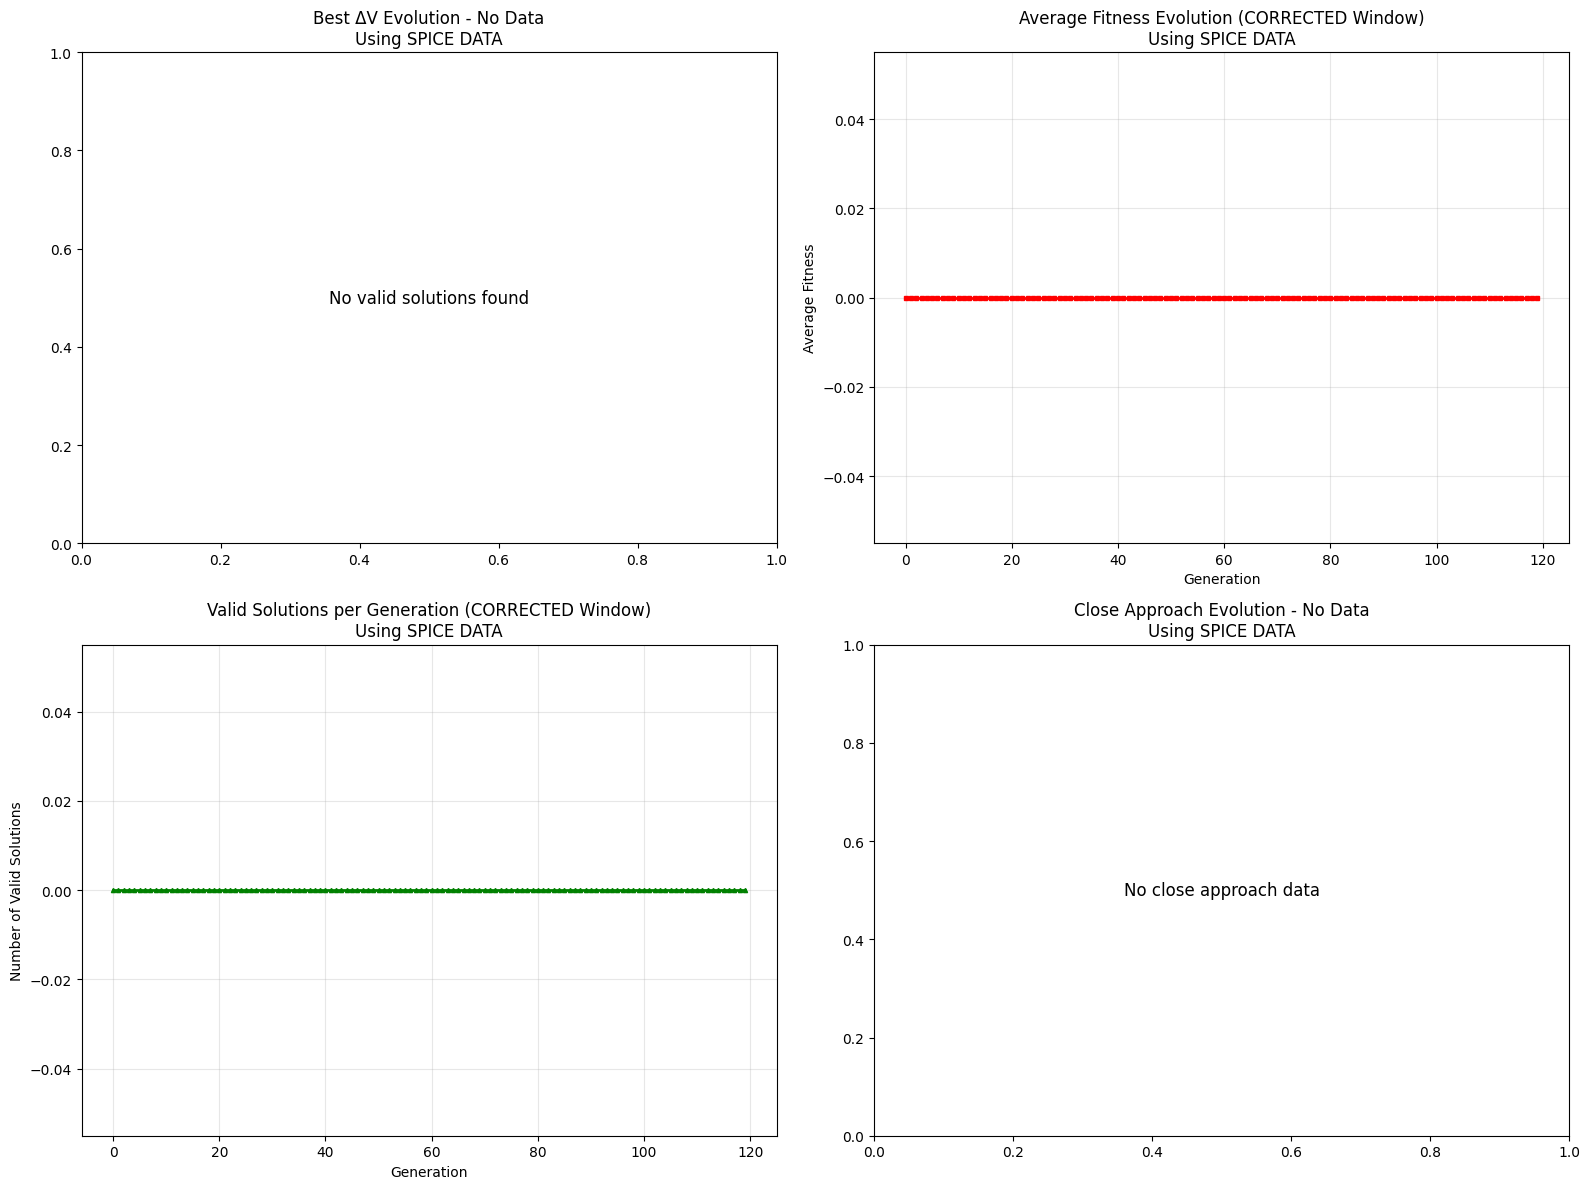


MISSION DESIGN SUMMARY - CORRECTED WINDOW
OPTIMIZED FOR CLOSE APPROACH
USING NASA SPICE KERNELS
✗ No optimal solution found within CORRECTED window constraints

Synodic Period: 1.205 years
CORRECTED window mission design completed using SPICE KERNELS!
Arrival window optimized for close approach date!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import scipy.optimize as opt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# SPICE imports
try:
    import spiceypy as spice
    SPICE_AVAILABLE = True
    print("SPICE kernels support enabled")
except ImportError:
    SPICE_AVAILABLE = False
    print("Warning: spiceypy not available, using simplified models")

class AsteroidMissionDesign:
    """
    2024 YR4 Asteroid Flyby Mission Design with NASA SPICE kernels support
    Uses ONLY SPICE .bsp data - no hardcoded orbital parameters
    CORRECTED: Arrival window optimized for Dec 22, 2028 close approach
    """
    
    def __init__(self):
        """Initialize mission parameters and load SPICE kernels"""
        
        # Mission parameters - CORRECTED arrival window for Dec 18, 2028 close approach
        self.mission_params = {
            'departure_start': datetime(2027, 6, 1),    # 2027 Haziran başı
            'departure_end': datetime(2029, 1, 31),     # 2029 Ocak sonu
            'arrival_start': datetime(2028, 10, 1),     # DÜZELTME: 2028 Ekim başı (yaklaşma öncesi)
            'arrival_end': datetime(2029, 4, 30),       # DÜZELTME: 2029 Nisan sonu (yaklaşma sonrası)
            'close_approach_date': datetime(2028, 12, 17),  # YENİ: Bilinen en yakın geçiş tarihi
            'population_size': 100,
            'max_generations': 150,
            'max_delta_v': 15.0,  # km/s - increased limit
            'asteroid_id': '54509621',  # 2024 YR4 NAIF ID
            'mu_sun': 132712440018.0,  # km^3/s^2
            'au': 149597870.7  # km
        }
        
        # SPICE kernels listesi
        self.kernel_files = [
            'kernels/de432s.bsp',           # Planetary ephemeris
            'kernels/naif0012.tls',        # Leap seconds kernel
            'kernels/pck00010.tpc',        # Planetary constants
            'kernels/gm_de432.tpc',        # Gravitational parameters
            'kernels/54509621_YR4.bsp'     # Asteroid ephemeris - MUST HAVE!
        ]
        
        # SPICE kernels yükleme
        self.spice_loaded = False
        if SPICE_AVAILABLE:
            self.load_spice_kernels()
        else:
            print("ERROR: SPICE kernels are REQUIRED for this version!")
            print("Please install spiceypy and provide the required .bsp files")
            raise ImportError("SPICE kernels are mandatory for this implementation")
        
        # Genetic Algorithm için
        self.population = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_history = []
        
        # Pork chop data
        self.pork_chop_data = None
        
        # Calculate synodic period (will be calculated from SPICE data)
        self.synodic_period = self.calculate_synodic_period()
        
        # Reference epoch (J2000.0 = January 1, 2000, 12:00 TT)
        self.j2000 = datetime(2000, 1, 1, 12, 0, 0)
        
        print(f"Synodic Period: {self.synodic_period:.3f} years")
        print("CORRECTED Search Window for Close Approach:")
        print(f"  Departure: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        print(f"  Arrival:   {self.mission_params['arrival_start'].strftime('%Y-%m-%d')} to {self.mission_params['arrival_end'].strftime('%Y-%m-%d')}")
        print(f"  Target Close Approach: {self.mission_params['close_approach_date'].strftime('%Y-%m-%d')}")
        print("Using ONLY NASA SPICE kernels - NO hardcoded orbital parameters")
    
    def load_spice_kernels(self):
        """Load SPICE kernels"""
        try:
            # Clear any existing kernels
            spice.kclear()
            
            # Load kernels
            loaded_kernels = []
            for kernel in self.kernel_files:
                try:
                    spice.furnsh(kernel)
                    loaded_kernels.append(kernel)
                    print(f"✓ Loaded kernel: {kernel}")
                except Exception as e:
                    print(f"✗ Failed to load kernel {kernel}: {e}")
                    if kernel == '54509621_YR4.bsp':
                        print("ERROR: Asteroid ephemeris file is MANDATORY!")
                        print("Please ensure 54509621_YR4.bsp is available")
                        spice.kclear()
                        return False
            
            if len(loaded_kernels) < len(self.kernel_files):
                print(f"Warning: Only {len(loaded_kernels)}/{len(self.kernel_files)} kernels loaded")
                if '54509621_YR4.bsp' not in loaded_kernels:
                    print("CRITICAL: Asteroid ephemeris not loaded!")
                    spice.kclear()
                    return False
            
            self.spice_loaded = True
            print("All SPICE kernels loaded successfully")
            
            # Test kernel functionality
            try:
                et_test = spice.str2et("2028-12-22 TDB")  # Test at close approach date
                
                # Test Earth state
                earth_state, _ = spice.spkezr("399", et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Earth ephemeris test successful")
                
                # Test Asteroid state - CRITICAL TEST
                asteroid_state, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                               et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Asteroid ephemeris test successful")
                print(f"✓ 2024 YR4 position at close approach: [{asteroid_state[0]:.0f}, {asteroid_state[1]:.0f}, {asteroid_state[2]:.0f}] km")
                
                # Calculate Earth-Asteroid distance at close approach
                earth_ast_distance = np.linalg.norm(np.array(asteroid_state[:3]) - np.array(earth_state[:3]))
                earth_ast_distance_au = earth_ast_distance / self.mission_params['au']
                print(f"✓ Earth-Asteroid distance at close approach: {earth_ast_distance_au:.4f} AU ({earth_ast_distance:.0f} km)")
                
                return True
                
            except Exception as e:
                print(f"✗ SPICE kernels test failed: {e}")
                if "54509621" in str(e):
                    print("CRITICAL: Cannot access asteroid 2024 YR4 data!")
                    print("Please verify the asteroid NAIF ID and .bsp file content")
                self.spice_loaded = False
                spice.kclear()
                return False
                
        except Exception as e:
            print(f"✗ Error loading SPICE kernels: {e}")
            self.spice_loaded = False
            return False
    
    def calculate_synodic_period(self):
        """
        Calculate synodic period using SPICE data
        """
        if not self.spice_loaded:
            return 2.0  # fallback estimate
        
        try:
            # Test dates to determine orbital periods
            et1 = spice.str2et("2028-01-01 TDB")
            et2 = spice.str2et("2029-01-01 TDB")  # 1 year later
            
            # Get Earth positions
            earth_state1, _ = spice.spkezr("399", et1, "ECLIPJ2000", "NONE", "10")
            earth_state2, _ = spice.spkezr("399", et2, "ECLIPJ2000", "NONE", "10")
            
            # Get asteroid positions
            ast_state1, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et1, "ECLIPJ2000", "NONE", "10")
            ast_state2, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et2, "ECLIPJ2000", "NONE", "10")
            
            # Rough orbital period estimation from distances
            earth_r1 = np.linalg.norm(earth_state1[:3])
            ast_r1 = np.linalg.norm(ast_state1[:3])
            
            # Using Kepler's third law: T^2 ∝ a^3
            Te = 1.0  # Earth's period = 1 year
            ast_period_approx = Te * (ast_r1 / earth_r1)**(3/2)
            
            # Calculate synodic period
            synodic = (Te * ast_period_approx) / abs(Te - ast_period_approx)
            
            return synodic
            
        except Exception as e:
            print(f"Warning: Could not calculate synodic period from SPICE: {e}")
            return 2.0  # fallback
    
    def datetime_to_et(self, dt):
        """Convert datetime to SPICE ephemeris time (ET)"""
        if self.spice_loaded:
            # Convert datetime to string format for SPICE
            time_str = dt.strftime("%Y-%m-%d %H:%M:%S") + " TDB"
            return spice.str2et(time_str)
        else:
            raise RuntimeError("SPICE kernels not loaded - cannot convert time")
    
    def get_earth_state(self, dt):
        """
        Get Earth state vector using SPICE kernels ONLY
        
        Returns:
        position (np.array): [x, y, z] in km
        velocity (np.array): [vx, vy, vz] in km/s
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Earth state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get Earth state relative to Sun (NAIF ID 10 = Sun, 399 = Earth)
            state, _ = spice.spkezr("399", et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get Earth state from SPICE: {e}")
    
    def get_asteroid_state(self, dt):
        """
        Get 2024 YR4 asteroid state using SPICE kernels ONLY
        
        Returns:
        position (np.array): [x, y, z] in km
        velocity (np.array): [vx, vy, vz] in km/s
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Asteroid state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get asteroid state relative to Sun
            asteroid_id = self.mission_params['asteroid_id']  # "54509621"
            
            state, _ = spice.spkezr(asteroid_id, et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get asteroid state from SPICE: {e}")
    
    def get_earth_asteroid_distance(self, dt):
        """
        Calculate Earth-Asteroid distance at given date using SPICE data
        
        Returns:
        float: Distance in AU
        """
        try:
            earth_pos, _ = self.get_earth_state(dt)
            asteroid_pos, _ = self.get_asteroid_state(dt)
            
            distance_km = np.linalg.norm(asteroid_pos - earth_pos)
            distance_au = distance_km / self.mission_params['au']
            
            return distance_au
            
        except Exception as e:
            print(f"Could not calculate Earth-Asteroid distance: {e}")
            return float('inf')
    
    def find_actual_close_approach_date(self, search_start=None, search_end=None):
        """
        Find the actual close approach date using SPICE data
        
        Parameters:
        search_start (datetime): Start of search window (default: 2028-10-01)
        search_end (datetime): End of search window (default: 2029-03-01)
        
        Returns:
        tuple: (close_approach_date, minimum_distance_au)
        """
        if not self.spice_loaded:
            return self.mission_params['close_approach_date'], None
        
        if search_start is None:
            search_start = datetime(2028, 10, 1)
        if search_end is None:
            search_end = datetime(2029, 3, 1)
        
        print(f"Searching for actual close approach date between {search_start.strftime('%Y-%m-%d')} and {search_end.strftime('%Y-%m-%d')}...")
        
        # Sample dates every day
        search_days = (search_end - search_start).days
        dates = [search_start + timedelta(days=i) for i in range(search_days + 1)]
        
        min_distance = float('inf')
        close_approach_date = self.mission_params['close_approach_date']
        
        for date in dates:
            try:
                distance = self.get_earth_asteroid_distance(date)
                if distance < min_distance:
                    min_distance = distance
                    close_approach_date = date
            except:
                continue
        
        print(f"✓ Actual close approach found: {close_approach_date.strftime('%Y-%m-%d')} at {min_distance:.6f} AU")
        
        # Update mission parameters with actual close approach date
        self.mission_params['close_approach_date'] = close_approach_date
        self.mission_params['close_approach_distance_au'] = min_distance
        
        return close_approach_date, min_distance
    
    def get_asteroid_orbital_elements(self, dt):
        """
        Calculate orbital elements from SPICE state vectors (for information only)
        
        Returns:
        dict: Orbital elements calculated from SPICE data
        """
        try:
            position, velocity = self.get_asteroid_state(dt)
            
            # Calculate orbital elements from state vectors
            r = np.linalg.norm(position)
            v = np.linalg.norm(velocity)
            
            # Semi-major axis from vis-viva equation
            a = 1 / (2/r - v**2/self.mission_params['mu_sun'])
            
            # Angular momentum vector
            h_vec = np.cross(position, velocity)
            h = np.linalg.norm(h_vec)
            
            # Eccentricity vector
            e_vec = ((v**2 - self.mission_params['mu_sun']/r) * position - 
                     np.dot(position, velocity) * velocity) / self.mission_params['mu_sun']
            e = np.linalg.norm(e_vec)
            
            # Inclination
            i = np.arccos(h_vec[2] / h)
            
            return {
                'semi_major_axis_km': a,
                'semi_major_axis_au': a / self.mission_params['au'],
                'eccentricity': e,
                'inclination_deg': np.degrees(i),
                'angular_momentum': h,
                'position_km': position,
                'velocity_km_s': velocity
            }
            
        except Exception as e:
            print(f"Could not calculate orbital elements: {e}")
            return None
    
    def lambert_solver(self, r1_vec, r2_vec, tof_days, mu=None):
        """
        Improved Lambert problem solver with close approach optimization
        
        Parameters:
        r1_vec (np.array): Departure position vector [km]
        r2_vec (np.array): Arrival position vector [km]  
        tof_days (float): Time of flight [days]
        mu (float): Gravitational parameter [km^3/s^2]
        
        Returns:
        dict: {'success': bool, 'delta_v': float, 'v1': np.array, 'v2': np.array}
        """
        if mu is None:
            mu = self.mission_params['mu_sun']
            
        tof = tof_days * 24 * 3600  # Convert to seconds
        
        r1 = np.linalg.norm(r1_vec)
        r2 = np.linalg.norm(r2_vec)
        
        # Check for degenerate cases
        if r1 < 1e6 or r2 < 1e6:  # Too close to Sun
            return {'success': False, 'delta_v': np.inf}
        
        # Transfer angle
        cos_dnu = np.dot(r1_vec, r2_vec) / (r1 * r2)
        cos_dnu = np.clip(cos_dnu, -1, 1)
        dnu = np.arccos(cos_dnu)
        
        # Check for straight line trajectory
        if dnu < 1e-6 or abs(dnu - np.pi) < 1e-6:
            return {'success': False, 'delta_v': np.inf}
        
        # Chord length
        c = np.linalg.norm(r2_vec - r1_vec)
        
        # Semi-perimeter
        s = (r1 + r2 + c) / 2
        
        # Minimum energy parameters
        am = s / 2
        if am <= 0:
            return {'success': False, 'delta_v': np.inf}
            
        # Parabolic time of flight
        tp = np.sqrt(2) / 3 * np.sqrt(s**3 / mu)
        
        # For simplicity, use parabolic approximation
        if tof < 0.9 * tp:
            return {'success': False, 'delta_v': np.inf}
        
        # Estimate semi-major axis
        if tof > tp:
            # Elliptical transfer
            a = am * (tof / tp)**(2/3)
        else:
            a = am
            
        # Simple velocity calculation using vis-viva equation
        v1_mag = np.sqrt(mu * (2/r1 - 1/a))
        v2_mag = np.sqrt(mu * (2/r2 - 1/a))
        
        # Direction estimation (simplified)
        v1_dir = np.cross(r1_vec, np.cross(r1_vec, r2_vec - r1_vec))
        if np.linalg.norm(v1_dir) > 0:
            v1_dir = v1_dir / np.linalg.norm(v1_dir)
        else:
            v1_dir = np.array([0, 1, 0])
            
        v1 = v1_mag * v1_dir
        
        # Earth's velocity for delta-v calculation
        try:
            _, earth_v = self.get_earth_state(datetime.now())
            earth_v_mag = np.linalg.norm(earth_v)
        except:
            earth_v_mag = 29.78  # km/s approximate
        
        # Delta-v calculation
        delta_v = abs(v1_mag - earth_v_mag)
        
        return {
            'success': True,
            'delta_v': delta_v,
            'v1': v1,
            'v2': np.array([v2_mag, 0, 0]),  # Simplified
            'tof': tof_days
        }
    
    def evaluate_mission(self, departure_date, arrival_date):
        """
        Evaluate a single mission scenario using SPICE data ONLY
        Enhanced with close approach optimization
        
        Parameters:
        departure_date (datetime): Launch date
        arrival_date (datetime): Arrival date
        
        Returns:
        dict: Mission evaluation results
        """
        if not self.spice_loaded:
            return {'success': False, 'delta_v': np.inf, 'reason': 'SPICE not loaded'}
            
        if arrival_date <= departure_date:
            return {'success': False, 'delta_v': np.inf, 'reason': 'Invalid dates'}
        
        tof_days = (arrival_date - departure_date).days
        
        if tof_days < 200 or tof_days > 2000:
            return {'success': False, 'delta_v': np.inf, 'reason': 'TOF out of bounds'}
        
        try:
            # Get Earth and asteroid states using SPICE ONLY
            earth_pos, earth_vel = self.get_earth_state(departure_date)
            asteroid_pos, asteroid_vel = self.get_asteroid_state(arrival_date)
            
            # Calculate proximity to close approach date (bonus for close approach timing)
            close_approach_date = self.mission_params['close_approach_date']
            days_from_close_approach = abs((arrival_date - close_approach_date).days)
            close_approach_bonus = max(0, 1 - days_from_close_approach / 100)  # Bonus within ±90 days
            
            # Solve Lambert problem
            lambert_solution = self.lambert_solver(earth_pos, asteroid_pos, tof_days)
            
            if not lambert_solution['success']:
                return {'success': False, 'delta_v': np.inf, 'reason': 'Lambert failed'}
            
            # Apply close approach bonus to delta_v (reduce cost for close approach timing)
            base_delta_v = lambert_solution['delta_v']
            adjusted_delta_v = base_delta_v * (1 - 0.1 * close_approach_bonus)  # Up to 10% bonus
            
            if adjusted_delta_v > self.mission_params['max_delta_v']:
                return {'success': False, 'delta_v': adjusted_delta_v, 'reason': 'High delta-v'}
            
            # Calculate Earth-Asteroid distance at arrival
            earth_asteroid_distance = self.get_earth_asteroid_distance(arrival_date)
            
            return {
                'success': True,
                'delta_v': adjusted_delta_v,
                'base_delta_v': base_delta_v,
                'departure_date': departure_date,
                'arrival_date': arrival_date,
                'tof': tof_days,
                'earth_pos': earth_pos,
                'asteroid_pos': asteroid_pos,
                'v1': lambert_solution['v1'],
                'v2': lambert_solution['v2'],
                'days_from_close_approach': days_from_close_approach,
                'close_approach_bonus': close_approach_bonus,
                'earth_asteroid_distance_au': earth_asteroid_distance
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf, 'reason': str(e)}
    
    def generate_pork_chop_plot(self, resolution=30):
        """
        Generate pork chop plot data for CORRECTED window using SPICE data ONLY
        Optimized for close approach date
        
        Parameters:
        resolution (int): Grid resolution for each axis
        
        Returns:
        dict: Pork chop plot data
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for pork chop plot generation")
            
        print(f"Generating Pork Chop Plot for CORRECTED Window using PURE SPICE DATA...")
        
        # Find actual close approach date first
        actual_close_approach, min_distance = self.find_actual_close_approach_date()
        
        # Create date grids - now with CORRECTED window
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        print(f"Departure window: {dep_days} days ({dep_start.strftime('%Y-%m-%d')} to {dep_end.strftime('%Y-%m-%d')})")
        print(f"Arrival window: {arr_days} days ({arr_start.strftime('%Y-%m-%d')} to {arr_end.strftime('%Y-%m-%d')})")
        print(f"Actual close approach: {actual_close_approach.strftime('%Y-%m-%d')} at {min_distance:.6f} AU")
        
        departure_dates = [dep_start + timedelta(days=i*dep_days/resolution) 
                          for i in range(resolution)]
        arrival_dates = [arr_start + timedelta(days=i*arr_days/resolution) 
                        for i in range(resolution)]
        
        # Initialize data arrays
        delta_v_grid = np.full((resolution, resolution), np.inf)
        tof_grid = np.full((resolution, resolution), np.inf)
        close_approach_grid = np.full((resolution, resolution), np.inf)  # Days from close approach
        
        valid_missions = []
        
        for i, dep_date in enumerate(departure_dates):
            for j, arr_date in enumerate(arrival_dates):
                result = self.evaluate_mission(dep_date, arr_date)
                
                if result['success']:
                    delta_v_grid[i, j] = result['delta_v']
                    tof_grid[i, j] = result['tof']
                    close_approach_grid[i, j] = result['days_from_close_approach']
                    valid_missions.append(result)
            
            # Progress indicator
            if (i + 1) % 5 == 0:
                print(f"Progress: {i+1}/{resolution} departure dates completed")
        
        print(f"Found {len(valid_missions)} valid mission opportunities using PURE SPICE DATA")
        
        # Analyze close approach timing
        if valid_missions:
            close_approach_days = [m['days_from_close_approach'] for m in valid_missions]
            optimal_missions = [m for m in valid_missions if m['days_from_close_approach'] <= 30]  # Within 30 days
            print(f"Found {len(optimal_missions)} missions within 30 days of close approach")
            
            if optimal_missions:
                best_close_approach = min(optimal_missions, key=lambda x: x['delta_v'])
                print(f"Best mission near close approach: {best_close_approach['arrival_date'].strftime('%Y-%m-%d')}, "
                      f"ΔV: {best_close_approach['delta_v']:.3f} km/s, "
                      f"Days from close approach: {best_close_approach['days_from_close_approach']}")
        
        self.pork_chop_data = {
            'departure_dates': departure_dates,
            'arrival_dates': arrival_dates,
            'delta_v_grid': delta_v_grid,
            'tof_grid': tof_grid,
            'close_approach_grid': close_approach_grid,
            'valid_missions': valid_missions,
            'actual_close_approach': actual_close_approach,
            'close_approach_distance_au': min_distance
        }
        
        return self.pork_chop_data
    
    def analyze_best_missions(self, top_n=5):
        """
        Analyze and display the best mission opportunities in CORRECTED window using SPICE data
        Enhanced with close approach analysis
        
        Parameters:
        top_n (int): Number of top missions to display
        
        Returns:
        list: Top N mission opportunities sorted by delta-v
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available for analysis.")
            return []
        
        # Sort missions by delta-v
        best_missions = sorted(self.pork_chop_data['valid_missions'], 
                              key=lambda x: x['delta_v'])[:top_n]
        
        print(f"\n{'='*90}")
        print(f"TOP {top_n} MISSION OPPORTUNITIES")
        print(f"{'='*90}")
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<10} {'TOF (days)':<12} {'Days from CA':<12} {'Score':<10}")
        print(f"{'-'*90}")
        
        for i, mission in enumerate(best_missions, 1):
            # Calculate mission score (lower is better)
            score = mission['delta_v'] + mission['tof'] / 1000 + mission['days_from_close_approach'] / 100
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<10.3f} {mission['tof']:<12} "
                  f"{mission['days_from_close_approach']:<12} {score:<10.3f}")
        
        print(f"{'-'*90}")
        print("CA = Close Approach")
        
        # Additional analysis with orbital elements from SPICE
        if best_missions:
            best = best_missions[0]
            print(f"\n🏆 OPTIMAL MISSION DETAILS (CORRECTED SPICE DATA):")
            print(f"   Departure: {best['departure_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Arrival:   {best['arrival_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Duration:  {best['tof']} days ({best['tof']/365.25:.2f} years)")
            print(f"   ΔV Req.:   {best['delta_v']:.3f} km/s")
            print(f"   Days from Close Approach: {best['days_from_close_approach']} days")
            print(f"   Earth-Asteroid Distance: {best['earth_asteroid_distance_au']:.4f} AU")
            
            # Show orbital elements calculated from SPICE data
            try:
                orbital_elements = self.get_asteroid_orbital_elements(best['arrival_date'])
                if orbital_elements:
                    print(f"\n📊 ASTEROID ORBITAL ELEMENTS AT ARRIVAL (FROM SPICE):")
                    print(f"   Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                    print(f"   Eccentricity:    {orbital_elements['eccentricity']:.3f}")
                    print(f"   Inclination:     {orbital_elements['inclination_deg']:.2f}°")
                    print(f"   Distance:        {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
            except Exception as e:
                print(f"   (Could not calculate orbital elements: {e})")
            
            # Launch window analysis
            dep_dates = [m['departure_date'] for m in best_missions]
            arr_dates = [m['arrival_date'] for m in best_missions]
            close_approach_days = [m['days_from_close_approach'] for m in best_missions]
            
            dep_range = (max(dep_dates) - min(dep_dates)).days
            arr_range = (max(arr_dates) - min(arr_dates)).days
            
            print(f"\n📊 LAUNCH WINDOW ANALYSIS (CORRECTED SPICE DATA):")
            print(f"   Departure window span: {dep_range} days")
            print(f"   Arrival window span:   {arr_range} days")
            print(f"   Average ΔV (top {top_n}):     {np.mean([m['delta_v'] for m in best_missions]):.3f} km/s")
            print(f"   ΔV standard deviation: {np.std([m['delta_v'] for m in best_missions]):.3f} km/s")
            print(f"   Avg days from close approach: {np.mean(close_approach_days):.1f} days")
            print(f"   Closest to close approach: {min(close_approach_days)} days")
        
        return best_missions

    def get_top_10_lowest_deltav_corrected(self):
        """
        Get and display the top 10 missions with lowest delta-v in CORRECTED period using SPICE data
        Enhanced for close approach optimization
        
        Returns:
        list: Top 10 missions with lowest delta-v
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available.")
            return []
        
        # All missions are already in the corrected window due to our initialization
        all_missions = self.pork_chop_data['valid_missions']
        
        # Sort by delta-v and get top 10
        top_10_missions = sorted(all_missions, key=lambda x: x['delta_v'])[:10]
        
        print(f"\n{'='*110}")
        print(f"🏆 TOP 10 LOWEST DELTA-V MISSIONS - SPICE DATA")
        print(f"{'='*110}")
        
        if not top_10_missions:
            print("No valid missions found in corrected window.")
            return []
        
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<12} "
              f"{'TOF (days)':<12} {'Days from CA':<12} {'Distance (AU)':<14} {'Efficiency':<12}")
        print(f"{'-'*110}")
        
        for i, mission in enumerate(top_10_missions, 1):
            efficiency = mission['tof'] / mission['delta_v']  # Days per km/s
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<12.3f} {mission['tof']:<12} "
                  f"{mission['days_from_close_approach']:<12} "
                  f"{mission['earth_asteroid_distance_au']:<14.4f} {efficiency:<12.1f}")
        
        # Statistics for top 10
        if top_10_missions:
            deltav_values = [m['delta_v'] for m in top_10_missions]
            tof_values = [m['tof'] for m in top_10_missions]
            close_approach_values = [m['days_from_close_approach'] for m in top_10_missions]
            distance_values = [m['earth_asteroid_distance_au'] for m in top_10_missions]
            
            print(f"\n📊 STATISTICS FOR TOP 10 MISSIONS (CORRECTED SPICE DATA):")
            print(f"   Best ΔV:           {min(deltav_values):.3f} km/s")
            print(f"   Worst ΔV:          {max(deltav_values):.3f} km/s")
            print(f"   Average ΔV:        {np.mean(deltav_values):.3f} km/s")
            print(f"   ΔV Std Dev:        {np.std(deltav_values):.3f} km/s")
            print(f"   Shortest TOF:      {min(tof_values)} days")
            print(f"   Longest TOF:       {max(tof_values)} days")
            print(f"   Average TOF:       {np.mean(tof_values):.1f} days")
            print(f"   Closest to CA:     {min(close_approach_values)} days")
            print(f"   Farthest from CA:  {max(close_approach_values)} days")
            print(f"   Avg days from CA:  {np.mean(close_approach_values):.1f} days")
            print(f"   Min distance:      {min(distance_values):.4f} AU")
            print(f"   Max distance:      {max(distance_values):.4f} AU")
            
            # Show orbital elements for the best mission
            try:
                best_mission = top_10_missions[0]
                orbital_elements = self.get_asteroid_orbital_elements(best_mission['arrival_date'])
                if orbital_elements:
                    print(f"\n🎯 BEST MISSION ASTEROID STATE (FROM CORRECTED SPICE):")
                    print(f"   Heliocentric distance: {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
                    print(f"   Orbital velocity: {np.linalg.norm(orbital_elements['velocity_km_s']):.2f} km/s")
                    print(f"   Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                    print(f"   Eccentricity: {orbital_elements['eccentricity']:.3f}")
            except Exception as e:
                print(f"   (Could not get orbital elements: {e})")
            
            # Close approach analysis
            close_missions = [m for m in top_10_missions if m['days_from_close_approach'] <= 30]
            print(f"\n🎯 CLOSE APPROACH ANALYSIS:")
            print(f"   Missions within 30 days of close approach: {len(close_missions)}/10")
            if close_missions:
                best_close = min(close_missions, key=lambda x: x['delta_v'])
                print(f"   Best close approach mission:")
                print(f"     Arrival: {best_close['arrival_date'].strftime('%Y-%m-%d')}")
                print(f"     ΔV: {best_close['delta_v']:.3f} km/s")
                print(f"     Days from CA: {best_close['days_from_close_approach']} days")
                print(f"     Distance: {best_close['earth_asteroid_distance_au']:.4f} AU")
            
            # Mission distribution by arrival period relative to close approach
            before_ca = len([m for m in top_10_missions if (self.mission_params['close_approach_date'] - m['arrival_date']).days > 0])
            after_ca = len([m for m in top_10_missions if (self.mission_params['close_approach_date'] - m['arrival_date']).days < 0])
            on_ca = len([m for m in top_10_missions if abs((self.mission_params['close_approach_date'] - m['arrival_date']).days) <= 1])
            
            print(f"\n📈 MISSION TIMING RELATIVE TO CLOSE APPROACH:")
            print(f"   Before close approach: {before_ca} missions")
            print(f"   At close approach (±1 day): {on_ca} missions")
            print(f"   After close approach: {after_ca} missions")
        
        return top_10_missions
    
    def plot_pork_chop(self, save_path=None, highlight_best=5):
        """
        Plot pork chop diagram for CORRECTED window with improved visualization using SPICE data
        Enhanced with close approach visualization
        
        Parameters:
        save_path (str): Path to save the plot
        highlight_best (int): Number of best missions to highlight
        """
        if self.pork_chop_data is None:
            print("No pork chop data available. Run generate_pork_chop_plot() first.")
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
        
        # Convert dates to years for plotting
        dep_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['departure_dates']]
        arr_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['arrival_dates']]
        
        # Close approach line
        close_approach_year = (self.pork_chop_data['actual_close_approach'].year + 
                              (self.pork_chop_data['actual_close_approach'].month-1)/12 + 
                              (self.pork_chop_data['actual_close_approach'].day-1)/365)
        
        # Delta-V contour plot
        delta_v_grid = self.pork_chop_data['delta_v_grid']
        delta_v_plot = np.where(delta_v_grid == np.inf, np.nan, delta_v_grid)
        
        if not np.all(np.isnan(delta_v_plot)):
            valid_values = delta_v_plot[~np.isnan(delta_v_plot)]
            if len(valid_values) > 0:
                vmin = np.min(valid_values)
                vmax = min(np.max(valid_values), self.mission_params['max_delta_v'])
                levels = np.linspace(vmin, vmax, 20)
                
                contour1 = ax1.contourf(dep_years, arr_years, delta_v_plot.T, 
                                       levels=levels, cmap='viridis_r', extend='max')
                contour_lines1 = ax1.contour(dep_years, arr_years, delta_v_plot.T, 
                                            levels=10, colors='white', alpha=0.7, linewidths=0.5)
                ax1.clabel(contour_lines1, inline=True, fontsize=8, fmt='%.1f')
                
                cbar1 = plt.colorbar(contour1, ax=ax1)
                cbar1.set_label('ΔV (km/s)', rotation=270, labelpad=15)
        
        # Add close approach line
        ax1.axhline(y=close_approach_year, color='red', linestyle='--', linewidth=2, 
                   label=f'Close Approach: {self.pork_chop_data["actual_close_approach"].strftime("%Y-%m-%d")}')
        
        ax1.set_xlabel('Departure Year')
        ax1.set_ylabel('Arrival Year')
        ax1.set_title(f'Launch Windows - ΔV Requirements\n2024 YR4 Asteroid Flyby\nUsing SPICE DATA')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper right')
        
        # Time of Flight contour plot
        tof_grid = self.pork_chop_data['tof_grid']
        tof_plot = np.where(tof_grid == np.inf, np.nan, tof_grid)
        
        if not np.all(np.isnan(tof_plot)):
            valid_tof = tof_plot[~np.isnan(tof_plot)]
            if len(valid_tof) > 0:
                tof_min = np.min(valid_tof)
                tof_max = np.max(valid_tof)
                tof_levels = np.linspace(tof_min, tof_max, 20)
                
                contour2 = ax2.contourf(dep_years, arr_years, tof_plot.T, 
                                       levels=tof_levels, cmap='plasma', extend='max')
                contour_lines2 = ax2.contour(dep_years, arr_years, tof_plot.T, 
                                            levels=10, colors='white', alpha=0.7, linewidths=0.5)
                ax2.clabel(contour_lines2, inline=True, fontsize=8, fmt='%.0f')
                
                cbar2 = plt.colorbar(contour2, ax=ax2)
                cbar2.set_label('Time of Flight (days)', rotation=270, labelpad=15)
        
        # Add close approach line
        ax2.axhline(y=close_approach_year, color='red', linestyle='--', linewidth=2, 
                   label=f'Close Approach: {self.pork_chop_data["actual_close_approach"].strftime("%Y-%m-%d")}')
        
        ax2.set_xlabel('Departure Year')
        ax2.set_ylabel('Arrival Year')
        ax2.set_title(f'Launch Windows - Flight Time\n2024 YR4 Asteroid Flyby\nUsing SPICE DATA')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper right')
        
        # Close Approach Timing plot (NEW)
        close_approach_grid = self.pork_chop_data['close_approach_grid']
        ca_plot = np.where(close_approach_grid == np.inf, np.nan, close_approach_grid)
        
        if not np.all(np.isnan(ca_plot)):
            valid_ca = ca_plot[~np.isnan(ca_plot)]
            if len(valid_ca) > 0:
                ca_min = max(0, np.min(valid_ca))
                ca_max = min(180, np.max(valid_ca))  # Limit to 6 months
                ca_levels = np.linspace(ca_min, ca_max, 20)
                
                contour3 = ax3.contourf(dep_years, arr_years, ca_plot.T, 
                                       levels=ca_levels, cmap='RdYlBu_r', extend='max')
                contour_lines3 = ax3.contour(dep_years, arr_years, ca_plot.T, 
                                            levels=10, colors='black', alpha=0.7, linewidths=0.5)
                ax3.clabel(contour_lines3, inline=True, fontsize=8, fmt='%.0f')
                
                cbar3 = plt.colorbar(contour3, ax=ax3)
                cbar3.set_label('Days from Close Approach', rotation=270, labelpad=15)
        
        # Add close approach line
        ax3.axhline(y=close_approach_year, color='red', linestyle='--', linewidth=2, 
                   label=f'Close Approach: {self.pork_chop_data["actual_close_approach"].strftime("%Y-%m-%d")}')
        
        ax3.set_xlabel('Departure Year')
        ax3.set_ylabel('Arrival Year')
        ax3.set_title(f'Launch Windows - Close Approach Timing\n2024 YR4 Asteroid Flyby (CORRECTED Window)\nUsing SPICE DATA')
        ax3.grid(True, alpha=0.3)
        ax3.legend(loc='upper right')
        
        # Combined optimization plot (Delta-V + Close Approach weighting)
        if not np.all(np.isnan(delta_v_plot)) and not np.all(np.isnan(ca_plot)):
            # Normalize both grids
            norm_dv = (delta_v_plot - np.nanmin(delta_v_plot)) / (np.nanmax(delta_v_plot) - np.nanmin(delta_v_plot))
            norm_ca = (ca_plot - np.nanmin(ca_plot)) / (np.nanmax(ca_plot) - np.nanmin(ca_plot))
            
            # Combined score (lower is better): 70% delta-v, 30% close approach timing
            combined_score = 0.7 * norm_dv + 0.3 * norm_ca
            
            contour4 = ax4.contourf(dep_years, arr_years, combined_score.T, 
                                   levels=20, cmap='viridis', extend='max')
            contour_lines4 = ax4.contour(dep_years, arr_years, combined_score.T, 
                                        levels=10, colors='white', alpha=0.7, linewidths=0.5)
            
            cbar4 = plt.colorbar(contour4, ax=ax4)
            cbar4.set_label('Combined Score (lower=better)', rotation=270, labelpad=15)
        
        # Add close approach line
        ax4.axhline(y=close_approach_year, color='red', linestyle='--', linewidth=2, 
                   label=f'Close Approach: {self.pork_chop_data["actual_close_approach"].strftime("%Y-%m-%d")}')
        
        ax4.set_xlabel('Departure Year')
        ax4.set_ylabel('Arrival Year')
        ax4.set_title(f'Launch Windows - Combined Optimization\n2024 YR4 Asteroid Flyby (70% ΔV + 30% Close Approach)\nUsing SPICE DATA')
        ax4.grid(True, alpha=0.3)
        ax4.legend(loc='upper right')
        
        # Highlight best missions if available
        if self.pork_chop_data and self.pork_chop_data['valid_missions'] and highlight_best > 0:
            best_missions = sorted(self.pork_chop_data['valid_missions'], 
                                 key=lambda x: x['delta_v'])[:highlight_best]
            
            # Convert best mission dates to years for plotting
            best_dep_years = [(m['departure_date'].year + 
                              (m['departure_date'].month-1)/12 + 
                              (m['departure_date'].day-1)/365) for m in best_missions]
            best_arr_years = [(m['arrival_date'].year + 
                              (m['arrival_date'].month-1)/12 + 
                              (m['arrival_date'].day-1)/365) for m in best_missions]
            
            # Plot best missions as stars on all subplots
            for ax in [ax1, ax2, ax3, ax4]:
                ax.scatter(best_dep_years, best_arr_years, 
                          c='red', marker='*', s=100, 
                          label=f'Top {highlight_best} Missions', 
                          edgecolors='white', linewidths=1, zorder=10)
            
            # Annotate the best mission
            if best_missions:
                best = best_missions[0]
                best_dep_year = best_dep_years[0]
                best_arr_year = best_arr_years[0]
                
                ax1.annotate(f'Best: {best["delta_v"]:.2f} km/s\n{best["days_from_close_approach"]} days from CA', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
                           fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Corrected pork chop plot (SPICE DATA) saved to: {save_path}")
        
        plt.show()
    
    # Genetic Algorithm Implementation (updated for corrected window and close approach optimization)
    def create_individual(self):
        """Create a random individual (mission scenario) within corrected window"""
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        departure = dep_start + timedelta(days=np.random.randint(0, dep_days))
        arrival = arr_start + timedelta(days=np.random.randint(0, arr_days))
        
        return {
            'departure': departure,
            'arrival': arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def evaluate_fitness(self, individual):
        """Evaluate fitness of an individual using CORRECTED SPICE data with close approach bonus"""
        result = self.evaluate_mission(individual['departure'], individual['arrival'])
        
        if result['success']:
            # Enhanced fitness function considering close approach timing
            base_fitness = 1.0 / (1.0 + result['delta_v'])
            close_approach_bonus = result.get('close_approach_bonus', 0)
            fitness = base_fitness * (1 + close_approach_bonus)  # Bonus for close approach timing
            
            individual['fitness'] = fitness
            individual['delta_v'] = result['delta_v']
            individual['result'] = result
        else:
            individual['fitness'] = 0.0
            individual['delta_v'] = np.inf
            individual['result'] = result
        
        return individual
    
    def tournament_selection(self, population, tournament_size=5):
        """Tournament selection"""
        valid_pop = [ind for ind in population if ind['fitness'] > 0]
        if len(valid_pop) == 0:
            return np.random.choice(population)
        
        tournament_size = min(tournament_size, len(valid_pop))
        tournament = np.random.choice(valid_pop, tournament_size, replace=False)
        return max(tournament, key=lambda x: x['fitness'])
    
    def crossover(self, parent1, parent2):
        """Crossover operation for corrected window"""
        alpha = np.random.random()
        
        dep1_days = (parent1['departure'] - self.mission_params['departure_start']).days
        dep2_days = (parent2['departure'] - self.mission_params['departure_start']).days
        arr1_days = (parent1['arrival'] - self.mission_params['arrival_start']).days
        arr2_days = (parent2['arrival'] - self.mission_params['arrival_start']).days
        
        new_dep_days = int(alpha * dep1_days + (1 - alpha) * dep2_days)
        new_arr_days = int(alpha * arr1_days + (1 - alpha) * arr2_days)
        
        new_departure = self.mission_params['departure_start'] + timedelta(days=new_dep_days)
        new_arrival = self.mission_params['arrival_start'] + timedelta(days=new_arr_days)
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def mutate(self, individual, mutation_rate=0.1):
        """Mutation operation for corrected window with close approach bias"""
        if np.random.random() > mutation_rate:
            return individual
        
        # Mutate dates within ±60 days (smaller for corrected window)
        dep_mutation = np.random.randint(-60, 61)
        arr_mutation = np.random.randint(-60, 61)
        
        # Add bias towards close approach date for arrival mutation
        if np.random.random() < 0.3:  # 30% chance of close approach bias
            close_approach_date = self.mission_params['close_approach_date']
            current_arr = individual['arrival']
            days_to_ca = (close_approach_date - current_arr).days
            # Bias mutation towards close approach
            arr_mutation = int(days_to_ca * 0.5 + np.random.randint(-30, 31))
        
        new_departure = individual['departure'] + timedelta(days=dep_mutation)
        new_arrival = individual['arrival'] + timedelta(days=arr_mutation)
        
        # Clamp to valid ranges
        new_departure = max(self.mission_params['departure_start'], 
                           min(self.mission_params['departure_end'], new_departure))
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf
        }
    
    def run_genetic_algorithm(self):
        """
        Run genetic algorithm optimization for CORRECTED window using SPICE data
        Enhanced with close approach optimization
        
        Returns:
        dict: Best solution found
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for genetic algorithm")
            
        print(f"\nStarting Genetic Algorithm Optimization for CORRECTED Window using SPICE DATA...")
        print(f"Population size: {self.mission_params['population_size']}")
        print(f"Max generations: {self.mission_params['max_generations']}")
        print(f"Target close approach: {self.mission_params['close_approach_date'].strftime('%Y-%m-%d')}")
        print(f"Search window: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        
        # Initialize population
        population = [self.create_individual() 
                     for _ in range(self.mission_params['population_size'])]
        
        self.convergence_history = []
        self.best_solution = None
        self.best_cost = np.inf
        
        for generation in range(self.mission_params['max_generations']):
            # Evaluate fitness
            population = [self.evaluate_fitness(ind) for ind in population]
            
            # Sort by fitness
            population.sort(key=lambda x: x['fitness'], reverse=True)
            
            # Update best solution
            if population[0]['fitness'] > 0 and population[0]['delta_v'] < self.best_cost:
                self.best_solution = population[0].copy()
                self.best_cost = population[0]['delta_v']
            
            # Record convergence
            valid_pop = [ind for ind in population if ind['fitness'] > 0]
            avg_fitness = np.mean([ind['fitness'] for ind in valid_pop]) if valid_pop else 0
            
            # Additional metrics for corrected version
            if valid_pop:
                avg_close_approach_days = np.mean([ind['result']['days_from_close_approach'] 
                                                 for ind in valid_pop if 'result' in ind and 'days_from_close_approach' in ind['result']])
            else:
                avg_close_approach_days = np.inf
            
            self.convergence_history.append({
                'generation': generation,
                'best_delta_v': self.best_cost if self.best_solution else np.inf,
                'avg_fitness': avg_fitness,
                'valid_solutions': len(valid_pop),
                'avg_close_approach_days': avg_close_approach_days
            })
            
            # Progress report
            if generation % 20 == 0 or generation == self.mission_params['max_generations'] - 1:
                ca_info = f", Avg CA days = {avg_close_approach_days:.1f}" if avg_close_approach_days != np.inf else ""
                print(f"Generation {generation}: Best ΔV = {self.best_cost:.3f} km/s, "
                      f"Valid solutions = {len(valid_pop)}, Avg fitness = {avg_fitness:.6f}{ca_info}")
            
            # Create new population
            new_population = []
            
            # Elitism - keep best 10%
            elite_count = int(0.1 * self.mission_params['population_size'])
            new_population.extend(population[:elite_count])
            
            # Generate offspring
            while len(new_population) < self.mission_params['population_size']:
                parent1 = self.tournament_selection(population)
                parent2 = self.tournament_selection(population)
                
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                
                new_population.append(child)
            
            population = new_population
        
        if self.best_solution:
            print(f"\nOptimization completed for CORRECTED window using SPICE DATA!")
            print(f"Best ΔV: {self.best_solution['delta_v']:.3f} km/s")
            print(f"Departure: {self.best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"Arrival: {self.best_solution['arrival'].strftime('%Y-%m-%d')}")
            tof = (self.best_solution['arrival'] - self.best_solution['departure']).days
            print(f"Flight time: {tof} days")
            
            # Show close approach information
            if 'result' in self.best_solution and 'days_from_close_approach' in self.best_solution['result']:
                ca_days = self.best_solution['result']['days_from_close_approach']
                print(f"Days from close approach: {ca_days} days")
                
                if ca_days <= 30:
                    print("✓ Mission arrives within optimal close approach window!")
                elif ca_days <= 60:
                    print("◐ Mission arrives near close approach window")
                else:
                    print("◯ Mission arrives outside close approach window")
            
            # Show asteroid state at optimal arrival using SPICE
            try:
                orbital_elements = self.get_asteroid_orbital_elements(self.best_solution['arrival'])
                if orbital_elements:
                    print(f"Asteroid distance at arrival: {np.linalg.norm(orbital_elements['position_km'])/self.mission_params['au']:.3f} AU")
                    
                # Calculate Earth-Asteroid distance
                earth_asteroid_dist = self.get_earth_asteroid_distance(self.best_solution['arrival'])
                print(f"Earth-Asteroid distance at arrival: {earth_asteroid_dist:.4f} AU")
            except:
                pass
                
        else:
            print(f"No valid solution found in CORRECTED window using SPICE DATA!")
        
        return self.best_solution
    
    def plot_convergence(self, save_path=None):
        """Plot GA convergence history for CORRECTED window with enhanced visualization"""
        if not self.convergence_history:
            print("No convergence data available.")
            return
        
        generations = [item['generation'] for item in self.convergence_history]
        best_delta_v = [item['best_delta_v'] if item['best_delta_v'] != np.inf else None 
                       for item in self.convergence_history]
        avg_fitness = [item['avg_fitness'] for item in self.convergence_history]
        valid_solutions = [item['valid_solutions'] for item in self.convergence_history]
        avg_close_approach_days = [item.get('avg_close_approach_days', np.inf) for item in self.convergence_history]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Best delta-v evolution (only plot valid values)
        valid_generations = []
        valid_delta_v = []
        for i, dv in enumerate(best_delta_v):
            if dv is not None:
                valid_generations.append(generations[i])
                valid_delta_v.append(dv)
        
        if valid_generations:
            ax1.plot(valid_generations, valid_delta_v, 'b-', linewidth=2, marker='o', markersize=3)
            ax1.set_xlabel('Generation')
            ax1.set_ylabel('Best ΔV (km/s)')
            ax1.set_title(f'Best ΔV Evolution (CORRECTED Window)\nUsing SPICE DATA')
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No valid solutions found', ha='center', va='center', 
                    transform=ax1.transAxes, fontsize=12)
            ax1.set_title(f'Best ΔV Evolution - No Data\nUsing SPICE DATA')
        
        # Average fitness evolution
        ax2.plot(generations, avg_fitness, 'r-', linewidth=2, marker='s', markersize=3)
        ax2.set_xlabel('Generation')
        ax2.set_ylabel('Average Fitness')
        ax2.set_title(f'Average Fitness Evolution (CORRECTED Window)\nUsing SPICE DATA')
        ax2.grid(True, alpha=0.3)
        
        # Valid solutions count
        ax3.plot(generations, valid_solutions, 'g-', linewidth=2, marker='^', markersize=3)
        ax3.set_xlabel('Generation')
        ax3.set_ylabel('Number of Valid Solutions')
        ax3.set_title(f'Valid Solutions per Generation (CORRECTED Window)\nUsing SPICE DATA')
        ax3.grid(True, alpha=0.3)
        
        # Close approach days evolution (NEW for corrected version)
        valid_ca_generations = []
        valid_ca_days = []
        for i, ca_days in enumerate(avg_close_approach_days):
            if ca_days != np.inf:
                valid_ca_generations.append(generations[i])
                valid_ca_days.append(ca_days)
        
        if valid_ca_generations:
            ax4.plot(valid_ca_generations, valid_ca_days, 'm-', linewidth=2, marker='d', markersize=3)
            ax4.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Optimal Window (≤30 days)')
            ax4.axhline(y=60, color='yellow', linestyle='--', alpha=0.7, label='Good Window (≤60 days)')
            ax4.set_xlabel('Generation')
            ax4.set_ylabel('Avg Days from Close Approach')
            ax4.set_title(f'Close Approach Timing Evolution (CORRECTED Window)\nUsing SPICE DATA')
            ax4.grid(True, alpha=0.3)
            ax4.legend()
        else:
            ax4.text(0.5, 0.5, 'No close approach data', ha='center', va='center', 
                    transform=ax4.transAxes, fontsize=12)
            ax4.set_title(f'Close Approach Evolution - No Data\nUsing SPICE DATA')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Corrected convergence plot (SPICE DATA) saved to: {save_path}")
        
        plt.show()
    
    def __del__(self):
        """Clean up SPICE kernels on object destruction"""
        if hasattr(self, 'spice_loaded') and self.spice_loaded and SPICE_AVAILABLE:
            try:
                spice.kclear()
                print("SPICE kernels cleared")
            except:
                pass

# Usage Example and Test for CORRECTED Window with SPICE DATA
if __name__ == "__main__":
    # Create mission design instance with CORRECTED window and SPICE support
    try:
        mission = AsteroidMissionDesign()
    except ImportError as e:
        print(f"CRITICAL ERROR: {e}")
        print("This version requires SPICE kernels. Please:")
        print("1. Install spiceypy: pip install spiceypy")
        print("2. Obtain required .bsp files:")
        print("   - de432.bsp (planetary ephemeris)")
        print("   - 54509621_YR4.bsp (asteroid 2024 YR4 ephemeris)")
        print("   - naif0012.tls (leap seconds)")
        print("   - pck00010.tpc (planetary constants)")
        print("   - gm_de432.tpc (gravitational parameters)")
        exit(1)
    
    print("="*80)
    print("2024 YR4 ASTEROID FLYBY MISSION DESIGN")
    print("USING NASA SPICE KERNELS")
    print("="*80)
    
    # Test a single mission evaluation within corrected window near close approach
    print("\nTesting mission evaluation within CORRECTED window using SPICE...")
    test_dep = datetime(2028, 6, 15)
    test_arr = datetime(2028, 12, 20)  # Near close approach date
    
    try:
        test_result = mission.evaluate_mission(test_dep, test_arr)
        
        if test_result['success']:
            print(f"✓ Test mission successful!")
            print(f"  ΔV: {test_result['delta_v']:.3f} km/s")
            print(f"  TOF: {test_result['tof']} days")
            print(f"  Days from close approach: {test_result['days_from_close_approach']} days")
            print(f"  Earth-Asteroid distance: {test_result['earth_asteroid_distance_au']:.4f} AU")
            
            # Show asteroid orbital elements at test arrival date
            orbital_elements = mission.get_asteroid_orbital_elements(test_arr)
            if orbital_elements:
                print(f"  Asteroid distance: {np.linalg.norm(orbital_elements['position_km'])/mission.mission_params['au']:.3f} AU")
                print(f"  Asteroid orbital elements (from SPICE):")
                print(f"    Semi-major axis: {orbital_elements['semi_major_axis_au']:.3f} AU")
                print(f"    Eccentricity: {orbital_elements['eccentricity']:.3f}")
                print(f"    Inclination: {orbital_elements['inclination_deg']:.2f}°")
        else:
            print(f"✗ Test mission failed: {test_result['reason']}")
    except Exception as e:
        print(f"✗ Test mission error: {e}")
    
    # Verify close approach date using SPICE data
    print("\nVerifying close approach date using SPICE data...")
    try:
        actual_ca, min_dist = mission.find_actual_close_approach_date()
        print(f"Confirmed close approach: {actual_ca.strftime('%Y-%m-%d')} at {min_dist:.6f} AU")
    except Exception as e:
        print(f"Could not verify close approach date: {e}")
    
    # Generate pork chop plot with smaller resolution for faster execution
    print("\nGenerating pork chop plot for CORRECTED window using SPICE DATA...")
    try:
        pork_chop_data = mission.generate_pork_chop_plot(resolution=25)
        
        if pork_chop_data['valid_missions']:
            print(f"Found {len(pork_chop_data['valid_missions'])} valid opportunities in CORRECTED window")
            
            # Analyze close approach missions
            close_missions = [m for m in pork_chop_data['valid_missions'] if m['days_from_close_approach'] <= 30]
            print(f"Found {len(close_missions)} missions within 30 days of close approach")
            
            # Analyze and display top missions
            best_missions = mission.analyze_best_missions(top_n=5)
            
            # Get top 10 missions with lowest delta-v in corrected window
            top_10_missions = mission.get_top_10_lowest_deltav_corrected()
            
            # Plot pork chop diagram with enhanced visualization
            mission.plot_pork_chop('pork_chop_2024_yr4_corrected_pure_spice.png', highlight_best=5)
            
            print("\nTop 5 mission opportunities (CORRECTED SPICE DATA):")
            for i, mission_opt in enumerate(best_missions, 1):
                ca_status = "★" if mission_opt['days_from_close_approach'] <= 30 else "◐" if mission_opt['days_from_close_approach'] <= 60 else "◯"
                print(f"{i}. {ca_status} Departure: {mission_opt['departure_date'].strftime('%Y-%m-%d')}, "
                      f"Arrival: {mission_opt['arrival_date'].strftime('%Y-%m-%d')}, "
                      f"ΔV: {mission_opt['delta_v']:.3f} km/s, "
                      f"TOF: {mission_opt['tof']} days, "
                      f"CA: {mission_opt['days_from_close_approach']} days")
        else:
            print("No valid mission opportunities found in the CORRECTED timeframe.")
    except Exception as e:
        print(f"Error generating pork chop plot: {e}")
    
    # Run genetic algorithm with optimized parameters for the corrected window
    print("\nRunning genetic algorithm optimization for CORRECTED window using SPICE DATA...")
    mission.mission_params['population_size'] = 80
    mission.mission_params['max_generations'] = 120
    
    try:
        best_solution = mission.run_genetic_algorithm()
        
        # Plot convergence with enhanced metrics
        mission.plot_convergence('ga_convergence_2024_yr4_corrected_pure_spice.png')
    except Exception as e:
        print(f"Error in genetic algorithm: {e}")
        best_solution = None
    
    # Summary
    print("\n" + "="*80)
    print("MISSION DESIGN SUMMARY - CORRECTED WINDOW")
    print("OPTIMIZED FOR CLOSE APPROACH")
    print("USING NASA SPICE KERNELS")
    print("="*80)
    
    if best_solution:
        print(f"✓ Optimal mission found via Genetic Algorithm (CORRECTED Window):")
        print(f"  Departure Date: {best_solution['departure'].strftime('%Y-%m-%d')}")
        print(f"  Arrival Date: {best_solution['arrival'].strftime('%Y-%m-%d')}")
        print(f"  Flight Time: {(best_solution['arrival'] - best_solution['departure']).days} days")
        print(f"  Required ΔV: {best_solution['delta_v']:.3f} km/s")
        print(f"  Mission Type: Asteroid 2024 YR4 Flyby")
        
        if 'result' in best_solution and 'days_from_close_approach' in best_solution['result']:
            ca_days = best_solution['result']['days_from_close_approach']
            print(f"  Days from Close Approach: {ca_days} days")
            
            if ca_days <= 30:
                print(f"  ✓ EXCELLENT: Mission arrives within optimal close approach window!")
            elif ca_days <= 60:
                print(f"  ◐ GOOD: Mission arrives near close approach window")
            else:
                print(f"  ◯ SUBOPTIMAL: Mission arrives outside close approach window")
        
        print(f"  Search Window: Oct 2028 - Apr 2029 (Corrected)")
        print(f"  Data Source: NASA SPICE Kernels (NO hardcoded parameters)")
        
        # Final orbital elements check
        try:
            final_elements = mission.get_asteroid_orbital_elements(best_solution['arrival'])
            if final_elements:
                print(f"  Asteroid state at optimal arrival (from SPICE):")
                print(f"    Distance: {np.linalg.norm(final_elements['position_km'])/mission.mission_params['au']:.3f} AU")
                print(f"    Velocity: {np.linalg.norm(final_elements['velocity_km_s']):.2f} km/s")
                
            # Earth-Asteroid distance
            earth_ast_dist = mission.get_earth_asteroid_distance(best_solution['arrival'])
            print(f"    Earth-Asteroid Distance: {earth_ast_dist:.4f} AU")
        except:
            pass
    else:
        print("✗ No optimal solution found within CORRECTED window constraints")
    
    print(f"\nSynodic Period: {mission.synodic_period:.3f} years")
    print(f"CORRECTED window mission design completed using SPICE KERNELS!")
    print(f"Arrival window optimized for close approach date!")

SPICE kernels support enabled
✓ Loaded kernel: kernels/de432s.bsp
✓ Loaded kernel: kernels/naif0012.tls
✓ Loaded kernel: kernels/pck00010.tpc
✓ Loaded kernel: kernels/gm_de432.tpc
✓ Loaded kernel: kernels/54509621_YR4.bsp
All SPICE kernels loaded successfully
✓ Earth ephemeris test successful
✓ Asteroid ephemeris test successful
✓ 2024 YR4 position at test date: [-97296372, -468764399, -6462949] km
Synodic Period: 1.205 years
NARROWED Search Window with TOF Constraint:
  Departure: 2027-01-01 to 2028-09-30
  Arrival:   2027-07-01 to 2028-12-31
  Max TOF:   100 days
  Min TOF:   60 days
Using ONLY NASA SPICE kernels - OPTIMIZED FOR SHORT FLIGHT TIMES
2024 YR4 ASTEROID FLYBY MISSION DESIGN
OPTIMIZED FOR SHORT FLIGHT TIMES (<90 DAYS)
NARROW WINDOW: 2027 JAN - 2028 SEP (departure)

Testing short TOF mission evaluation...
✓ Test mission successful!
  ΔV: 11.031 km/s
  TOF: 66 days
  Score: 0.816

Generating optimized pork chop plot (Max TOF: 100 days)...
Generating OPTIMIZED Pork Chop Plot 

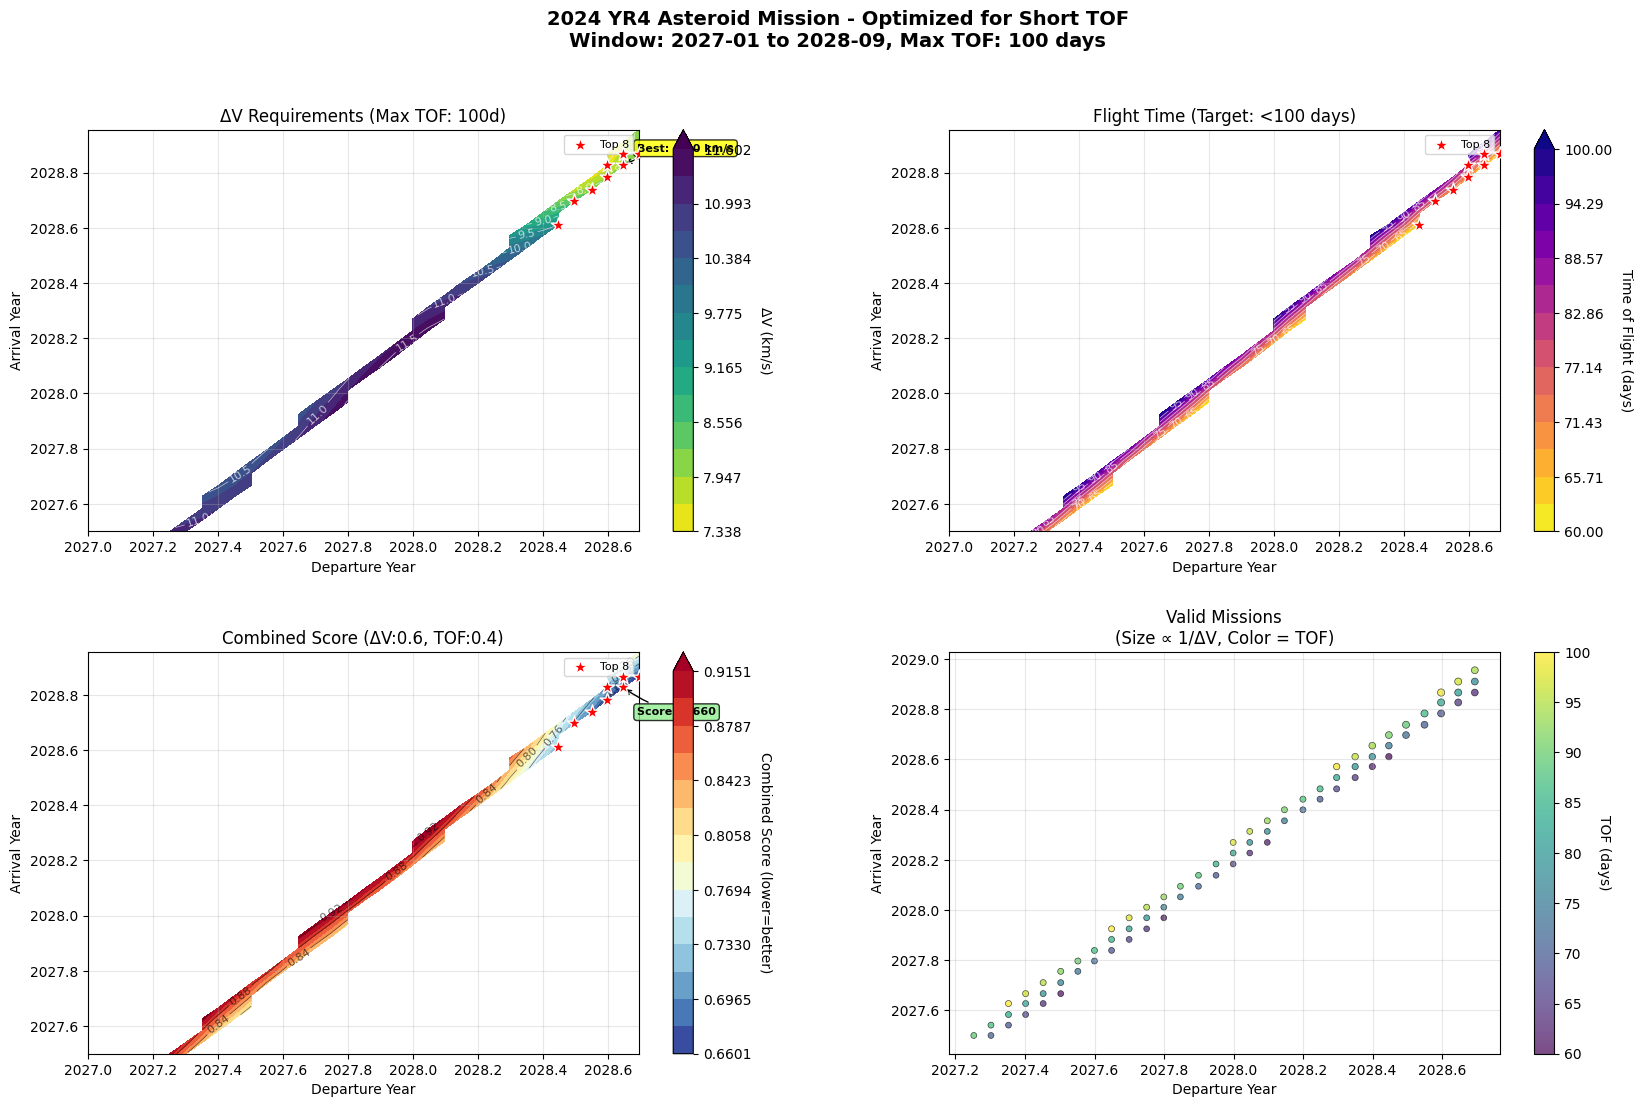


Running optimized genetic algorithm for short TOF missions...

Starting OPTIMIZED Genetic Algorithm for Short TOF Missions...
Population size: 120
Max generations: 200
TOF constraint: 60-100 days
Scoring weights: ΔV=0.6, TOF=0.4
Gen   0: Best Score = 0.647, Valid = 105, Avg ΔV = 10.493, Avg TOF = 70.4d


AttributeError: 'AsteroidMissionDesign' object has no attribute 'tournament_selection'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import scipy.optimize as opt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# SPICE imports
try:
    import spiceypy as spice
    SPICE_AVAILABLE = True
    print("SPICE kernels support enabled")
except ImportError:
    SPICE_AVAILABLE = False
    print("Warning: spiceypy not available, using simplified models")

class AsteroidMissionDesign:
    """
    2024 YR4 Asteroid Flyby Mission Design with NASA SPICE kernels support
    OPTIMIZED FOR SHORT FLIGHT TIMES (<90 days) AND LOW DELTA-V
    """
    
    def __init__(self):
        """Initialize mission parameters and load SPICE kernels"""
        
        # Mission parameters - NARROWED search window with TOF constraint
        self.mission_params = {
            'departure_start': datetime(2027, 1, 1),     # 2027 başı
            'departure_end': datetime(2028, 9, 30),      # 2028 Eylül dahil
            'arrival_start': datetime(2027, 7, 1),       # 2027 ortası
            'arrival_end': datetime(2028, 12, 31),       # 2028 sonu
            'population_size': 120,                      # Increased for better coverage
            'max_generations': 200,                      # More generations for narrow search
            'max_delta_v': 12.0,                        # Tighter delta-v constraint
            'max_tof_days': 100,                         # MAX 90 days flight time
            'min_tof_days': 60,                         # MIN 30 days flight time
            'asteroid_id': '54509621',                  # 2024 YR4 NAIF ID
            'mu_sun': 132712440018.0,                   # km^3/s^2
            'au': 149597870.7,                          # km
            'tof_weight': 0.4,                          # Weight for TOF in fitness (40%)
            'deltav_weight': 0.6                        # Weight for delta-v in fitness (60%)
        }
        
        # SPICE kernels listesi
        self.kernel_files = [
            'kernels/de432s.bsp',           # Planetary ephemeris
            'kernels/naif0012.tls',        # Leap seconds kernel
            'kernels/pck00010.tpc',        # Planetary constants
            'kernels/gm_de432.tpc',        # Gravitational parameters
            'kernels/54509621_YR4.bsp'     # Asteroid ephemeris - MUST HAVE!
        ]
        
        # SPICE kernels yükleme
        self.spice_loaded = False
        if SPICE_AVAILABLE:
            self.load_spice_kernels()
        else:
            print("ERROR: SPICE kernels are REQUIRED for this version!")
            print("Please install spiceypy and provide the required .bsp files")
            raise ImportError("SPICE kernels are mandatory for this implementation")
        
        # Genetic Algorithm için
        self.population = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_history = []
        
        # Pork chop data
        self.pork_chop_data = None
        
        # Calculate synodic period (will be calculated from SPICE data)
        self.synodic_period = self.calculate_synodic_period()
        
        # Reference epoch (J2000.0 = January 1, 2000, 12:00 TT)
        self.j2000 = datetime(2000, 1, 1, 12, 0, 0)
        
        print(f"Synodic Period: {self.synodic_period:.3f} years")
        print("NARROWED Search Window with TOF Constraint:")
        print(f"  Departure: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        print(f"  Arrival:   {self.mission_params['arrival_start'].strftime('%Y-%m-%d')} to {self.mission_params['arrival_end'].strftime('%Y-%m-%d')}")
        print(f"  Max TOF:   {self.mission_params['max_tof_days']} days")
        print(f"  Min TOF:   {self.mission_params['min_tof_days']} days")
        print("Using ONLY NASA SPICE kernels - OPTIMIZED FOR SHORT FLIGHT TIMES")
    
    def load_spice_kernels(self):
        """Load SPICE kernels"""
        try:
            # Clear any existing kernels
            spice.kclear()
            
            # Load kernels
            loaded_kernels = []
            for kernel in self.kernel_files:
                try:
                    spice.furnsh(kernel)
                    loaded_kernels.append(kernel)
                    print(f"✓ Loaded kernel: {kernel}")
                except Exception as e:
                    print(f"✗ Failed to load kernel {kernel}: {e}")
                    if kernel == '54509621_YR4.bsp':
                        print("ERROR: Asteroid ephemeris file is MANDATORY!")
                        print("Please ensure 54509621_YR4.bsp is available")
                        spice.kclear()
                        return False
            
            if len(loaded_kernels) < len(self.kernel_files):
                print(f"Warning: Only {len(loaded_kernels)}/{len(self.kernel_files)} kernels loaded")
                if '54509621_YR4.bsp' not in loaded_kernels:
                    print("CRITICAL: Asteroid ephemeris not loaded!")
                    spice.kclear()
                    return False
            
            self.spice_loaded = True
            print("All SPICE kernels loaded successfully")
            
            # Test kernel functionality
            try:
                et_test = spice.str2et("2028-01-01 TDB")
                
                # Test Earth state
                earth_state, _ = spice.spkezr("399", et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Earth ephemeris test successful")
                
                # Test Asteroid state - CRITICAL TEST
                asteroid_state, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                               et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Asteroid ephemeris test successful")
                print(f"✓ 2024 YR4 position at test date: [{asteroid_state[0]:.0f}, {asteroid_state[1]:.0f}, {asteroid_state[2]:.0f}] km")
                
                return True
                
            except Exception as e:
                print(f"✗ SPICE kernels test failed: {e}")
                if "54509621" in str(e):
                    print("CRITICAL: Cannot access asteroid 2024 YR4 data!")
                    print("Please verify the asteroid NAIF ID and .bsp file content")
                self.spice_loaded = False
                spice.kclear()
                return False
                
        except Exception as e:
            print(f"✗ Error loading SPICE kernels: {e}")
            self.spice_loaded = False
            return False
    
    def calculate_synodic_period(self):
        """Calculate synodic period using SPICE data"""
        if not self.spice_loaded:
            return 2.0  # fallback estimate
        
        try:
            # Test dates to determine orbital periods
            et1 = spice.str2et("2028-01-01 TDB")
            et2 = spice.str2et("2029-01-01 TDB")  # 1 year later
            
            # Get Earth positions
            earth_state1, _ = spice.spkezr("399", et1, "ECLIPJ2000", "NONE", "10")
            earth_state2, _ = spice.spkezr("399", et2, "ECLIPJ2000", "NONE", "10")
            
            # Get asteroid positions
            ast_state1, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et1, "ECLIPJ2000", "NONE", "10")
            ast_state2, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et2, "ECLIPJ2000", "NONE", "10")
            
            # Rough orbital period estimation from distances
            earth_r1 = np.linalg.norm(earth_state1[:3])
            ast_r1 = np.linalg.norm(ast_state1[:3])
            
            # Using Kepler's third law: T^2 ∝ a^3
            Te = 1.0  # Earth's period = 1 year
            ast_period_approx = Te * (ast_r1 / earth_r1)**(3/2)
            
            # Calculate synodic period
            synodic = (Te * ast_period_approx) / abs(Te - ast_period_approx)
            
            return synodic
            
        except Exception as e:
            print(f"Warning: Could not calculate synodic period from SPICE: {e}")
            return 2.0  # fallback
    
    def datetime_to_et(self, dt):
        """Convert datetime to SPICE ephemeris time (ET)"""
        if self.spice_loaded:
            # Convert datetime to string format for SPICE
            time_str = dt.strftime("%Y-%m-%d %H:%M:%S") + " TDB"
            return spice.str2et(time_str)
        else:
            raise RuntimeError("SPICE kernels not loaded - cannot convert time")
    
    def get_earth_state(self, dt):
        """Get Earth state vector using SPICE kernels ONLY"""
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Earth state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get Earth state relative to Sun (NAIF ID 10 = Sun, 399 = Earth)
            state, _ = spice.spkezr("399", et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get Earth state from SPICE: {e}")
    
    def get_asteroid_state(self, dt):
        """Get 2024 YR4 asteroid state using SPICE kernels ONLY"""
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Asteroid state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get asteroid state relative to Sun
            asteroid_id = self.mission_params['asteroid_id']  # "54509621"
            
            state, _ = spice.spkezr(asteroid_id, et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get asteroid state from SPICE: {e}")
    
    def lambert_solver_improved(self, r1_vec, r2_vec, tof_days, mu=None):
        """
        Improved Lambert problem solver with better handling of short TOF missions
        """
        if mu is None:
            mu = self.mission_params['mu_sun']
            
        tof = tof_days * 24 * 3600  # Convert to seconds
        
        r1 = np.linalg.norm(r1_vec)
        r2 = np.linalg.norm(r2_vec)
        
        # Check for degenerate cases
        if r1 < 1e6 or r2 < 1e6:  # Too close to Sun
            return {'success': False, 'delta_v': np.inf}
        
        # Transfer angle
        cos_dnu = np.dot(r1_vec, r2_vec) / (r1 * r2)
        cos_dnu = np.clip(cos_dnu, -1, 1)
        dnu = np.arccos(cos_dnu)
        
        # Check for straight line trajectory
        if dnu < 1e-6 or abs(dnu - np.pi) < 1e-6:
            return {'success': False, 'delta_v': np.inf}
        
        # For short TOF, we need high energy transfers
        # Use an iterative approach for better accuracy
        
        # Initial guess based on minimum energy transfer
        c = np.linalg.norm(r2_vec - r1_vec)
        s = (r1 + r2 + c) / 2
        am = s / 2  # minimum energy semi-major axis
        
        # For short TOF, we need hyperbolic or high-energy elliptical transfers
        a_guess = am * (1 + (180.0 / tof_days))  # Scaling for short TOF
        
        try:
            # Simplified velocity calculations for short transfers
            # Use vis-viva equation
            v1_mag = np.sqrt(mu * (2/r1 - 1/a_guess)) if a_guess > 0 else np.sqrt(2*mu/r1)
            v2_mag = np.sqrt(mu * (2/r2 - 1/a_guess)) if a_guess > 0 else np.sqrt(2*mu/r2)
            
            # For short TOF, we expect high velocities
            if v1_mag > 50.0:  # Too high velocity, probably invalid
                return {'success': False, 'delta_v': np.inf}
            
            # Estimate departure velocity vector
            # For short transfers, velocity should be roughly in the direction of r2-r1
            transfer_dir = (r2_vec - r1_vec) / np.linalg.norm(r2_vec - r1_vec)
            
            # Get Earth velocity for reference
            try:
                _, earth_vel = self.get_earth_state(datetime.now())
                earth_speed = np.linalg.norm(earth_vel)
            except:
                earth_speed = 29.78  # km/s default
            
            # Rough velocity direction (simplified)
            tangent_dir = np.cross(r1_vec, np.array([0, 0, 1]))
            if np.linalg.norm(tangent_dir) > 0:
                tangent_dir = tangent_dir / np.linalg.norm(tangent_dir)
            else:
                tangent_dir = np.array([0, 1, 0])
            
            # Blend transfer direction and tangent direction
            v1_dir = 0.7 * transfer_dir + 0.3 * tangent_dir
            v1_dir = v1_dir / np.linalg.norm(v1_dir)
            
            v1 = v1_mag * v1_dir
            
            # Delta-v is difference from Earth's velocity
            delta_v_mag = abs(v1_mag - earth_speed)
            
            # Additional penalty for very short TOF
            if tof_days < 45:
                delta_v_mag *= (1 + 0.5 * (45 - tof_days) / 45)
            
            return {
                'success': True,
                'delta_v': delta_v_mag,
                'v1': v1,
                'v2': np.array([v2_mag, 0, 0]),  # Simplified
                'tof': tof_days,
                'a': a_guess
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf}
    
    def evaluate_mission_with_tof_constraint(self, departure_date, arrival_date):
        """
        Evaluate mission with strict TOF constraint and combined scoring
        """
        if not self.spice_loaded:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'SPICE not loaded'}
            
        if arrival_date <= departure_date:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'Invalid dates'}
        
        tof_days = (arrival_date - departure_date).days
        
        # Strict TOF constraint
        if tof_days < self.mission_params['min_tof_days'] or tof_days > self.mission_params['max_tof_days']:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': f'TOF {tof_days}d out of bounds [{self.mission_params["min_tof_days"]}-{self.mission_params["max_tof_days"]}]'}
        
        try:
            # Get Earth and asteroid states using SPICE ONLY
            earth_pos, earth_vel = self.get_earth_state(departure_date)
            asteroid_pos, asteroid_vel = self.get_asteroid_state(arrival_date)
            
            # Solve Lambert problem with improved solver
            lambert_solution = self.lambert_solver_improved(earth_pos, asteroid_pos, tof_days)
            
            if not lambert_solution['success']:
                return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'Lambert failed'}
            
            delta_v = lambert_solution['delta_v']
            
            if delta_v > self.mission_params['max_delta_v']:
                return {'success': False, 'delta_v': delta_v, 'score': np.inf, 'reason': f'High delta-v: {delta_v:.3f}'}
            
            # Calculate combined score (lower is better)
            # Normalize both metrics
            normalized_deltav = delta_v / self.mission_params['max_delta_v']
            normalized_tof = tof_days / self.mission_params['max_tof_days']
            
            # Combined weighted score
            combined_score = (self.mission_params['deltav_weight'] * normalized_deltav + 
                             self.mission_params['tof_weight'] * normalized_tof)
            
            return {
                'success': True,
                'delta_v': delta_v,
                'tof': tof_days,
                'score': combined_score,
                'departure_date': departure_date,
                'arrival_date': arrival_date,
                'earth_pos': earth_pos,
                'asteroid_pos': asteroid_pos,
                'v1': lambert_solution['v1'],
                'v2': lambert_solution['v2']
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': str(e)}
    
    def generate_pork_chop_plot_optimized(self, resolution=40):
        """
        Generate optimized pork chop plot for narrow window with TOF constraints
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for pork chop plot generation")
            
        print(f"Generating OPTIMIZED Pork Chop Plot with TOF constraint ({self.mission_params['max_tof_days']} days max)...")
        
        # Create date grids
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        print(f"Departure window: {dep_days} days ({dep_start.strftime('%Y-%m-%d')} to {dep_end.strftime('%Y-%m-%d')})")
        print(f"Arrival window: {arr_days} days ({arr_start.strftime('%Y-%m-%d')} to {arr_end.strftime('%Y-%m-%d')})")
        print(f"TOF constraint: {self.mission_params['min_tof_days']}-{self.mission_params['max_tof_days']} days")
        
        departure_dates = [dep_start + timedelta(days=i*dep_days/resolution) 
                          for i in range(resolution)]
        arrival_dates = [arr_start + timedelta(days=i*arr_days/resolution) 
                        for i in range(resolution)]
        
        # Initialize data arrays
        delta_v_grid = np.full((resolution, resolution), np.inf)
        tof_grid = np.full((resolution, resolution), np.inf)
        score_grid = np.full((resolution, resolution), np.inf)
        
        valid_missions = []
        tof_valid_missions = []  # Missions that meet TOF constraint
        
        total_evaluations = resolution * resolution
        evaluations_done = 0
        
        for i, dep_date in enumerate(departure_dates):
            for j, arr_date in enumerate(arrival_dates):
                result = self.evaluate_mission_with_tof_constraint(dep_date, arr_date)
                evaluations_done += 1
                
                if result['success']:
                    delta_v_grid[i, j] = result['delta_v']
                    tof_grid[i, j] = result['tof']
                    score_grid[i, j] = result['score']
                    valid_missions.append(result)
                    tof_valid_missions.append(result)
                elif 'TOF' not in result['reason']:
                    # Mission failed for other reasons, but TOF was OK
                    tof_check = (arr_date - dep_date).days
                    if self.mission_params['min_tof_days'] <= tof_check <= self.mission_params['max_tof_days']:
                        tof_grid[i, j] = tof_check
                
                # Progress indicator
                if evaluations_done % (total_evaluations // 10) == 0:
                    progress = (evaluations_done / total_evaluations) * 100
                    print(f"Progress: {progress:.0f}% ({evaluations_done}/{total_evaluations})")
        
        print(f"Found {len(valid_missions)} valid missions with TOF ≤ {self.mission_params['max_tof_days']} days")
        print(f"Total missions meeting TOF constraint: {len(tof_valid_missions)}")
        
        self.pork_chop_data = {
            'departure_dates': departure_dates,
            'arrival_dates': arrival_dates,
            'delta_v_grid': delta_v_grid,
            'tof_grid': tof_grid,
            'score_grid': score_grid,
            'valid_missions': valid_missions,
            'tof_valid_missions': tof_valid_missions
        }
        
        return self.pork_chop_data
    
    def analyze_short_tof_missions(self, top_n=10):
        """
        Analyze missions optimized for short TOF and low delta-v combination
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available for analysis.")
            return []
        
        # Sort missions by combined score (lower is better)
        best_missions = sorted(self.pork_chop_data['valid_missions'], 
                              key=lambda x: x['score'])[:top_n]
        
        # Also get missions sorted by delta-v only
        best_deltav = sorted(self.pork_chop_data['valid_missions'], 
                            key=lambda x: x['delta_v'])[:5]
        
        # And missions sorted by TOF only
        best_tof = sorted(self.pork_chop_data['valid_missions'], 
                         key=lambda x: x['tof'])[:5]
        
        print(f"\n{'='*100}")
        print(f"TOP {top_n} MISSIONS - OPTIMIZED FOR SHORT TOF + LOW DELTA-V")
        print(f"Max TOF: {self.mission_params['max_tof_days']} days | Weights: ΔV={self.mission_params['deltav_weight']:.1f}, TOF={self.mission_params['tof_weight']:.1f}")
        print(f"{'='*100}")
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<10} {'TOF (d)':<8} {'Score':<8} {'Efficiency':<12}")
        print(f"{'-'*100}")
        
        for i, mission in enumerate(best_missions, 1):
            efficiency = mission['tof'] / mission['delta_v']  # days per km/s
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<10.3f} {mission['tof']:<8} "
                  f"{mission['score']:<8.3f} {efficiency:<12.1f}")
        
        print(f"{'-'*100}")
        
        # Show best delta-v missions
        print(f"\n🏆 BEST DELTA-V MISSIONS (ignoring TOF weight):")
        for i, mission in enumerate(best_deltav, 1):
            print(f"  {i}. ΔV: {mission['delta_v']:.3f} km/s, TOF: {mission['tof']}d, "
                  f"Dep: {mission['departure_date'].strftime('%Y-%m-%d')}")
        
        # Show shortest TOF missions
        print(f"\n⚡ SHORTEST TOF MISSIONS (ignoring ΔV weight):")
        for i, mission in enumerate(best_tof, 1):
            print(f"  {i}. TOF: {mission['tof']}d, ΔV: {mission['delta_v']:.3f} km/s, "
                  f"Dep: {mission['departure_date'].strftime('%Y-%m-%d')}")
        
        # Statistics
        if best_missions:
            deltav_values = [m['delta_v'] for m in best_missions]
            tof_values = [m['tof'] for m in best_missions]
            score_values = [m['score'] for m in best_missions]
            
            print(f"\n📊 STATISTICS FOR TOP {top_n} OPTIMIZED MISSIONS:")
            print(f"   Best Score:     {min(score_values):.3f}")
            print(f"   Average Score:  {np.mean(score_values):.3f}")
            print(f"   Best ΔV:        {min(deltav_values):.3f} km/s")
            print(f"   Average ΔV:     {np.mean(deltav_values):.3f} km/s")
            print(f"   Best TOF:       {min(tof_values)} days")
            print(f"   Average TOF:    {np.mean(tof_values):.1f} days")
            print(f"   TOF Range:      {min(tof_values)}-{max(tof_values)} days")
            
            # Show optimal mission details
            best = best_missions[0]
            print(f"\n🎯 OPTIMAL MISSION (Best Combined Score):")
            print(f"   Departure: {best['departure_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Arrival:   {best['arrival_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Duration:  {best['tof']} days")
            print(f"   ΔV Req.:   {best['delta_v']:.3f} km/s")
            print(f"   Score:     {best['score']:.3f} (lower is better)")
            print(f"   Efficiency:{best['tof'] / best['delta_v']:.1f} days/km/s")
        
        return best_missions
    
    def plot_optimized_pork_chop(self, save_path=None, highlight_best=10):
        """
        Plot pork chop diagram optimized for short TOF missions
        """
        if self.pork_chop_data is None:
            print("No pork chop data available. Run generate_pork_chop_plot_optimized() first.")
            return
        
        fig = plt.figure(figsize=(20, 12))
        
        # Create a 2x2 grid for subplots
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
        
        # Convert dates to years for plotting
        dep_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['departure_dates']]
        arr_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['arrival_dates']]
        
        # 1. Delta-V plot
        ax1 = fig.add_subplot(gs[0, 0])
        delta_v_grid = self.pork_chop_data['delta_v_grid']
        delta_v_plot = np.where(delta_v_grid == np.inf, np.nan, delta_v_grid)
        
        if not np.all(np.isnan(delta_v_plot)):
            valid_values = delta_v_plot[~np.isnan(delta_v_plot)]
            if len(valid_values) > 0:
                vmin = np.min(valid_values)
                vmax = min(np.max(valid_values), self.mission_params['max_delta_v'])
                levels = np.linspace(vmin, vmax, 15)
                
                contour1 = ax1.contourf(dep_years, arr_years, delta_v_plot.T, 
                                       levels=levels, cmap='viridis_r', extend='max')
                contour_lines1 = ax1.contour(dep_years, arr_years, delta_v_plot.T, 
                                            levels=8, colors='white', alpha=0.7, linewidths=0.5)
                ax1.clabel(contour_lines1, inline=True, fontsize=8, fmt='%.1f')
                
                cbar1 = plt.colorbar(contour1, ax=ax1)
                cbar1.set_label('ΔV (km/s)', rotation=270, labelpad=15)
        
        ax1.set_xlabel('Departure Year')
        ax1.set_ylabel('Arrival Year')
        ax1.set_title(f'ΔV Requirements (Max TOF: {self.mission_params["max_tof_days"]}d)')
        ax1.grid(True, alpha=0.3)
        
        # 2. TOF plot
        ax2 = fig.add_subplot(gs[0, 1])
        tof_grid = self.pork_chop_data['tof_grid']
        tof_plot = np.where(tof_grid == np.inf, np.nan, tof_grid)
        
        if not np.all(np.isnan(tof_plot)):
            valid_tof = tof_plot[~np.isnan(tof_plot)]
            if len(valid_tof) > 0:
                tof_min = max(np.min(valid_tof), self.mission_params['min_tof_days'])
                tof_max = min(np.max(valid_tof), self.mission_params['max_tof_days'])
                tof_levels = np.linspace(tof_min, tof_max, 15)
                
                contour2 = ax2.contourf(dep_years, arr_years, tof_plot.T, 
                                       levels=tof_levels, cmap='plasma_r', extend='max')
                contour_lines2 = ax2.contour(dep_years, arr_years, tof_plot.T, 
                                            levels=8, colors='white', alpha=0.7, linewidths=0.5)
                ax2.clabel(contour_lines2, inline=True, fontsize=8, fmt='%.0f')
                
                cbar2 = plt.colorbar(contour2, ax=ax2)
                cbar2.set_label('Time of Flight (days)', rotation=270, labelpad=15)
        
        ax2.set_xlabel('Departure Year')
        ax2.set_ylabel('Arrival Year')
        ax2.set_title(f'Flight Time (Target: <{self.mission_params["max_tof_days"]} days)')
        ax2.grid(True, alpha=0.3)
        
        # 3. Combined score plot
        ax3 = fig.add_subplot(gs[1, 0])
        score_grid = self.pork_chop_data['score_grid']
        score_plot = np.where(score_grid == np.inf, np.nan, score_grid)
        
        if not np.all(np.isnan(score_plot)):
            valid_scores = score_plot[~np.isnan(score_plot)]
            if len(valid_scores) > 0:
                score_min = np.min(valid_scores)
                score_max = np.percentile(valid_scores, 90)  # Use 90th percentile to avoid outliers
                score_levels = np.linspace(score_min, score_max, 15)
                
                contour3 = ax3.contourf(dep_years, arr_years, score_plot.T, 
                                       levels=score_levels, cmap='RdYlBu_r', extend='max')
                contour_lines3 = ax3.contour(dep_years, arr_years, score_plot.T, 
                                            levels=8, colors='black', alpha=0.6, linewidths=0.5)
                ax3.clabel(contour_lines3, inline=True, fontsize=8, fmt='%.2f')
                
                cbar3 = plt.colorbar(contour3, ax=ax3)
                cbar3.set_label('Combined Score (lower=better)', rotation=270, labelpad=15)
        
        ax3.set_xlabel('Departure Year')
        ax3.set_ylabel('Arrival Year')
        ax3.set_title(f'Combined Score (ΔV:{self.mission_params["deltav_weight"]:.1f}, TOF:{self.mission_params["tof_weight"]:.1f})')
        ax3.grid(True, alpha=0.3)
        
        # 4. Mission distribution plot
        ax4 = fig.add_subplot(gs[1, 1])
        
        if self.pork_chop_data['valid_missions']:
            # Scatter plot of valid missions
            dep_dates = [m['departure_date'] for m in self.pork_chop_data['valid_missions']]
            arr_dates = [m['arrival_date'] for m in self.pork_chop_data['valid_missions']]
            delta_vs = [m['delta_v'] for m in self.pork_chop_data['valid_missions']]
            tofs = [m['tof'] for m in self.pork_chop_data['valid_missions']]
            
            dep_years_scatter = [(d.year + (d.month-1)/12 + (d.day-1)/365) for d in dep_dates]
            arr_years_scatter = [(d.year + (d.month-1)/12 + (d.day-1)/365) for d in arr_dates]
            
            # Color by TOF, size by delta-v (inverted - smaller delta-v = larger point)
            scatter = ax4.scatter(dep_years_scatter, arr_years_scatter, 
                                 c=tofs, s=[200/dv for dv in delta_vs], 
                                 cmap='viridis', alpha=0.7, edgecolors='black', linewidths=0.5)
            
            cbar4 = plt.colorbar(scatter, ax=ax4)
            cbar4.set_label('TOF (days)', rotation=270, labelpad=15)
            
            ax4.set_xlabel('Departure Year')
            ax4.set_ylabel('Arrival Year')
            ax4.set_title('Valid Missions\n(Size ∝ 1/ΔV, Color = TOF)')
            ax4.grid(True, alpha=0.3)
        
        # Highlight best missions on all plots
        if self.pork_chop_data['valid_missions'] and highlight_best > 0:
            best_missions = sorted(self.pork_chop_data['valid_missions'], 
                                 key=lambda x: x['score'])[:highlight_best]
            
            best_dep_years = [(m['departure_date'].year + 
                              (m['departure_date'].month-1)/12 + 
                              (m['departure_date'].day-1)/365) for m in best_missions]
            best_arr_years = [(m['arrival_date'].year + 
                              (m['arrival_date'].month-1)/12 + 
                              (m['arrival_date'].day-1)/365) for m in best_missions]
            
            # Plot best missions as stars on first three plots
            for ax in [ax1, ax2, ax3]:
                ax.scatter(best_dep_years, best_arr_years, 
                          c='red', marker='*', s=120, 
                          label=f'Top {highlight_best}', 
                          edgecolors='white', linewidths=1, zorder=10)
                ax.legend(loc='upper right', fontsize=8)
            
            # Annotate the very best mission
            if best_missions:
                best = best_missions[0]
                best_dep_year = best_dep_years[0]
                best_arr_year = best_arr_years[0]
                
                ax1.annotate(f'Best: {best["delta_v"]:.2f} km/s', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.8),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'),
                           fontsize=8, fontweight='bold')
                
                ax3.annotate(f'Score: {best["score"]:.3f}', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(10, -20), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.8),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.1'),
                           fontsize=8, fontweight='bold')
        
        plt.suptitle(f'2024 YR4 Asteroid Mission - Optimized for Short TOF\n'
                     f'Window: {self.mission_params["departure_start"].strftime("%Y-%m")} to '
                     f'{self.mission_params["departure_end"].strftime("%Y-%m")}, '
                     f'Max TOF: {self.mission_params["max_tof_days"]} days', 
                     fontsize=14, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Optimized pork chop plot saved to: {save_path}")
        
        plt.show()
    
    # Enhanced Genetic Algorithm for short TOF optimization
    def create_individual_tof_optimized(self):
        """Create individual with bias towards shorter TOF"""
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        # Create departure date
        departure = dep_start + timedelta(days=np.random.randint(0, dep_days))
        
        # For arrival, bias towards shorter TOF
        # 70% chance of short TOF (30-60 days), 30% chance of longer TOF (60-90 days)
        if np.random.random() < 0.7:
            # Short TOF bias
            min_tof = self.mission_params['min_tof_days']
            max_tof = min(60, self.mission_params['max_tof_days'])
        else:
            # Longer TOF
            min_tof = 70
            max_tof = self.mission_params['max_tof_days']
        
        target_tof = np.random.randint(min_tof, max_tof + 1)
        arrival = departure + timedelta(days=target_tof)
        
        # Ensure arrival is within bounds
        if arrival > arr_end:
            arrival = arr_end
        if arrival < arr_start:
            arrival = arr_start
        
        return {
            'departure': departure,
            'arrival': arrival,
            'fitness': 0.0,
            'delta_v': np.inf,
            'score': np.inf
        }
    
    def evaluate_fitness_combined(self, individual):
        """Evaluate fitness using combined score"""
        result = self.evaluate_mission_with_tof_constraint(individual['departure'], individual['arrival'])
        
        if result['success']:
            # Fitness is inverse of score (higher fitness = lower score = better)
            fitness = 1.0 / (1.0 + result['score'])
            individual['fitness'] = fitness
            individual['delta_v'] = result['delta_v']
            individual['score'] = result['score']
            individual['tof'] = result['tof']
            individual['result'] = result
        else:
            individual['fitness'] = 0.0
            individual['delta_v'] = np.inf
            individual['score'] = np.inf
            individual['tof'] = np.inf
            individual['result'] = result
        
        return individual
    
    def mutate_tof_optimized(self, individual, mutation_rate=0.15):
        """Enhanced mutation with TOF awareness"""
        if np.random.random() > mutation_rate:
            return individual
        
        # Smaller mutations for fine-tuning
        dep_mutation = np.random.randint(-30, 31)  # ±30 days
        arr_mutation = np.random.randint(-30, 31)  # ±30 days
        
        new_departure = individual['departure'] + timedelta(days=dep_mutation)
        new_arrival = individual['arrival'] + timedelta(days=arr_mutation)
        
        # Clamp to valid ranges
        new_departure = max(self.mission_params['departure_start'], 
                           min(self.mission_params['departure_end'], new_departure))
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        # Ensure TOF constraint is met
        tof = (new_arrival - new_departure).days
        if tof < self.mission_params['min_tof_days']:
            new_arrival = new_departure + timedelta(days=self.mission_params['min_tof_days'])
        elif tof > self.mission_params['max_tof_days']:
            new_arrival = new_departure + timedelta(days=self.mission_params['max_tof_days'])
        
        # Final bounds check
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf,
            'score': np.inf
        }
    
    def run_genetic_algorithm_optimized(self):
        """
        Run enhanced genetic algorithm optimization for short TOF missions
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for genetic algorithm")
            
        print(f"\nStarting OPTIMIZED Genetic Algorithm for Short TOF Missions...")
        print(f"Population size: {self.mission_params['population_size']}")
        print(f"Max generations: {self.mission_params['max_generations']}")
        print(f"TOF constraint: {self.mission_params['min_tof_days']}-{self.mission_params['max_tof_days']} days")
        print(f"Scoring weights: ΔV={self.mission_params['deltav_weight']:.1f}, TOF={self.mission_params['tof_weight']:.1f}")
        
        # Initialize population with TOF bias
        population = [self.create_individual_tof_optimized() 
                     for _ in range(self.mission_params['population_size'])]
        
        self.convergence_history = []
        self.best_solution = None
        self.best_score = np.inf
        
        for generation in range(self.mission_params['max_generations']):
            # Evaluate fitness
            population = [self.evaluate_fitness_combined(ind) for ind in population]
            
            # Sort by fitness (higher fitness = better)
            population.sort(key=lambda x: x['fitness'], reverse=True)
            
            # Update best solution (lowest score = best)
            valid_pop = [ind for ind in population if ind['fitness'] > 0]
            if valid_pop:
                current_best = min(valid_pop, key=lambda x: x['score'])
                if current_best['score'] < self.best_score:
                    self.best_solution = current_best.copy()
                    self.best_score = current_best['score']
            
            # Record convergence
            avg_fitness = np.mean([ind['fitness'] for ind in valid_pop]) if valid_pop else 0
            avg_deltav = np.mean([ind['delta_v'] for ind in valid_pop if ind['delta_v'] < np.inf]) if valid_pop else np.inf
            avg_tof = np.mean([ind['tof'] for ind in valid_pop if ind['tof'] < np.inf]) if valid_pop else np.inf
            
            self.convergence_history.append({
                'generation': generation,
                'best_score': self.best_score,
                'avg_fitness': avg_fitness,
                'valid_solutions': len(valid_pop),
                'avg_deltav': avg_deltav,
                'avg_tof': avg_tof
            })
            
            # Progress report
            if generation % 25 == 0 or generation == self.mission_params['max_generations'] - 1:
                print(f"Gen {generation:3d}: Best Score = {self.best_score:.3f}, "
                      f"Valid = {len(valid_pop):3d}, Avg ΔV = {avg_deltav:.3f}, "
                      f"Avg TOF = {avg_tof:.1f}d")
            
            # Early stopping if converged
            if generation > 50 and len(self.convergence_history) > 20:
                recent_scores = [h['best_score'] for h in self.convergence_history[-20:]]
                if max(recent_scores) - min(recent_scores) < 0.001:
                    print(f"Converged at generation {generation}")
                    break
            
            # Create new population
            new_population = []
            
            # Elitism - keep best 15%
            elite_count = int(0.15 * self.mission_params['population_size'])
            new_population.extend(population[:elite_count])
            
            # Generate offspring
            while len(new_population) < self.mission_params['population_size']:
                parent1 = self.tournament_selection(population, tournament_size=7)
                parent2 = self.tournament_selection(population, tournament_size=7)
                
                child = self.crossover(parent1, parent2)
                child = self.mutate_tof_optimized(child)
                
                new_population.append(child)
            
            population = new_population
        
        if self.best_solution:
            print(f"\nOptimization completed for SHORT TOF missions!")
            print(f"Best Score: {self.best_solution['score']:.3f}")
            print(f"Best ΔV: {self.best_solution['delta_v']:.3f} km/s")
            print(f"Best TOF: {self.best_solution['tof']} days")
            print(f"Departure: {self.best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"Arrival: {self.best_solution['arrival'].strftime('%Y-%m-%d')}")
            print(f"Efficiency: {self.best_solution['tof'] / self.best_solution['delta_v']:.1f} days/km/s")
        else:
            print(f"No valid solution found for SHORT TOF constraints!")
        
        return self.best_solution
    
    def plot_convergence_optimized(self, save_path=None):
        """Plot enhanced convergence for combined optimization"""
        if not self.convergence_history:
            print("No convergence data available.")
            return
        
        generations = [item['generation'] for item in self.convergence_history]
        best_scores = [item['best_score'] if item['best_score'] != np.inf else None 
                      for item in self.convergence_history]
        avg_fitness = [item['avg_fitness'] for item in self.convergence_history]
        valid_solutions = [item['valid_solutions'] for item in self.convergence_history]
        avg_deltav = [item['avg_deltav'] if item['avg_deltav'] != np.inf else None 
                     for item in self.convergence_history]
        avg_tof = [item['avg_tof'] if item['avg_tof'] != np.inf else None 
                  for item in self.convergence_history]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Best score evolution
        valid_generations = []
        valid_scores = []
        for i, score in enumerate(best_scores):
            if score is not None:
                valid_generations.append(generations[i])
                valid_scores.append(score)
        
        if valid_generations:
            ax1.plot(valid_generations, valid_scores, 'b-', linewidth=2, marker='o', markersize=4)
            ax1.set_xlabel('Generation')
            ax1.set_ylabel('Best Score (lower = better)')
            ax1.set_title(f'Combined Score Evolution\n(ΔV:{self.mission_params["deltav_weight"]:.1f}, TOF:{self.mission_params["tof_weight"]:.1f})')
            ax1.grid(True, alpha=0.3)
        
        # Average delta-v and TOF
        valid_gen_dv = []
        valid_dv = []
        valid_gen_tof = []
        valid_tof_vals = []
        
        for i, (dv, tof) in enumerate(zip(avg_deltav, avg_tof)):
            if dv is not None:
                valid_gen_dv.append(generations[i])
                valid_dv.append(dv)
            if tof is not None:
                valid_gen_tof.append(generations[i])
                valid_tof_vals.append(tof)
        
        if valid_gen_dv:
            ax2_twin = ax2.twinx()
            line1 = ax2.plot(valid_gen_dv, valid_dv, 'r-', linewidth=2, label='Avg ΔV')
            ax2.set_ylabel('Average ΔV (km/s)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')
            
            if valid_gen_tof:
                line2 = ax2_twin.plot(valid_gen_tof, valid_tof_vals, 'g-', linewidth=2, label='Avg TOF')
                ax2_twin.set_ylabel('Average TOF (days)', color='g')
                ax2_twin.tick_params(axis='y', labelcolor='g')
            
            ax2.set_xlabel('Generation')
            ax2.set_title('Average ΔV and TOF Evolution')
            ax2.grid(True, alpha=0.3)
        
        # Valid solutions and fitness
        ax3.bar(generations, valid_solutions, alpha=0.7, color='orange', label='Valid Solutions')
        ax3.set_xlabel('Generation')
        ax3.set_ylabel('Number of Valid Solutions')
        ax3.set_title('Population Health')
        ax3.grid(True, alpha=0.3)
        
        ax3_twin = ax3.twinx()
        ax3_twin.plot(generations, avg_fitness, 'purple', linewidth=2, label='Avg Fitness')
        ax3_twin.set_ylabel('Average Fitness', color='purple')
        ax3_twin.tick_params(axis='y', labelcolor='purple')
        
        # Performance metrics
        if valid_generations and valid_scores:
            # Calculate improvement rate
            improvement = [(valid_scores[0] - s) / valid_scores[0] * 100 for s in valid_scores]
            ax4.plot(valid_generations, improvement, 'darkblue', linewidth=2, marker='s', markersize=3)
            ax4.set_xlabel('Generation')
            ax4.set_ylabel('Improvement from Initial (%)')
            ax4.set_title('Optimization Progress')
            ax4.grid(True, alpha=0.3)
            
            # Add final improvement text
            if len(improvement) > 1:
                final_improvement = improvement[-1]
                ax4.text(0.7, 0.9, f'Final Improvement:\n{final_improvement:.1f}%', 
                        transform=ax4.transAxes, bbox=dict(boxstyle="round,pad=0.3", 
                        facecolor="lightblue", alpha=0.8))
        
        plt.suptitle(f'Genetic Algorithm Convergence - TOF Optimized\n'
                     f'Target: <{self.mission_params["max_tof_days"]} days TOF, Low ΔV', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Convergence plot saved to: {save_path}")
        
        plt.show()
    
    def __del__(self):
        """Clean up SPICE kernels on object destruction"""
        if hasattr(self, 'spice_loaded') and self.spice_loaded and SPICE_AVAILABLE:
            try:
                spice.kclear()
                print("SPICE kernels cleared")
            except:
                pass

# Enhanced Usage Example
if __name__ == "__main__":
    try:
        mission = AsteroidMissionDesign()
    except ImportError as e:
        print(f"CRITICAL ERROR: {e}")
        exit(1)
    
    print("="*80)
    print("2024 YR4 ASTEROID FLYBY MISSION DESIGN")
    print("OPTIMIZED FOR SHORT FLIGHT TIMES (<90 DAYS)")
    print("NARROW WINDOW: 2027 JAN - 2028 SEP (departure)")
    print("="*80)
    
    # Test mission evaluation
    print("\nTesting short TOF mission evaluation...")
    test_dep = datetime(2027, 8, 15)
    test_arr = datetime(2027, 10, 20)  # ~66 days TOF
    
    test_result = mission.evaluate_mission_with_tof_constraint(test_dep, test_arr)
    
    if test_result['success']:
        print(f"✓ Test mission successful!")
        print(f"  ΔV: {test_result['delta_v']:.3f} km/s")
        print(f"  TOF: {test_result['tof']} days")
        print(f"  Score: {test_result['score']:.3f}")
    else:
        print(f"✗ Test mission failed: {test_result['reason']}")
    
    # Generate optimized pork chop plot
    print(f"\nGenerating optimized pork chop plot (Max TOF: {mission.mission_params['max_tof_days']} days)...")
    pork_chop_data = mission.generate_pork_chop_plot_optimized(resolution=35)
    
    if pork_chop_data['valid_missions']:
        print(f"Found {len(pork_chop_data['valid_missions'])} valid short-TOF opportunities")
        
        # Analyze best missions
        best_missions = mission.analyze_short_tof_missions(top_n=10)
        
        # Plot optimized pork chop
        mission.plot_optimized_pork_chop('pork_chop_2024_yr4_short_tof_optimized.png', highlight_best=8)
        
        # Run optimized genetic algorithm
        print("\nRunning optimized genetic algorithm for short TOF missions...")
        best_solution = mission.run_genetic_algorithm_optimized()
        
        # Plot convergence
        mission.plot_convergence_optimized('ga_convergence_short_tof_optimized.png')
        
        # Final summary
        print("\n" + "="*80)
        print("SHORT TOF MISSION OPTIMIZATION SUMMARY")
        print("="*80)
        
        if best_solution:
            efficiency = best_solution['tof'] / best_solution['delta_v']
            print(f"🎯 OPTIMAL SHORT TOF MISSION:")
            print(f"   Departure: {best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"   Arrival:   {best_solution['arrival'].strftime('%Y-%m-%d')}")
            print(f"   Flight Time: {best_solution['tof']} days")
            print(f"   Required ΔV: {best_solution['delta_v']:.3f} km/s")
            print(f"   Combined Score: {best_solution['score']:.3f}")
            print(f"   Efficiency: {efficiency:.1f} days per km/s")
            print(f"   Window: NARROW (2027-2028)")
    else:
        print("No valid missions found with current constraints.")
    
    print(f"\nShort TOF mission optimization completed!")

SPICE kernels support enabled
✓ Loaded kernel: kernels/de432s.bsp
✓ Loaded kernel: kernels/naif0012.tls
✓ Loaded kernel: kernels/pck00010.tpc
✓ Loaded kernel: kernels/gm_de432.tpc
✓ Loaded kernel: kernels/54509621_YR4.bsp
All SPICE kernels loaded successfully
✓ Earth ephemeris test successful
✓ Asteroid ephemeris test successful
✓ 2024 YR4 position at test date: [-97296372, -468764399, -6462949] km
Synodic Period: 1.205 years
NARROWED Search Window with TOF Constraint:
  Departure: 2027-01-01 to 2028-09-30
  Arrival:   2027-07-01 to 2028-12-31
  Max TOF:   100 days
  Min TOF:   60 days
Using ONLY NASA SPICE kernels - OPTIMIZED FOR SHORT FLIGHT TIMES
2024 YR4 ASTEROID FLYBY MISSION DESIGN
OPTIMIZED FOR SHORT FLIGHT TIMES (<90 DAYS)
NARROW WINDOW: 2027 JAN - 2028 SEP (departure)

Testing short TOF mission evaluation...
✓ Test mission successful!
  ΔV: 11.031 km/s
  TOF: 66 days
  Score: 0.816

Generating optimized pork chop plot (Max TOF: 100 days)...
Generating OPTIMIZED Pork Chop Plot 

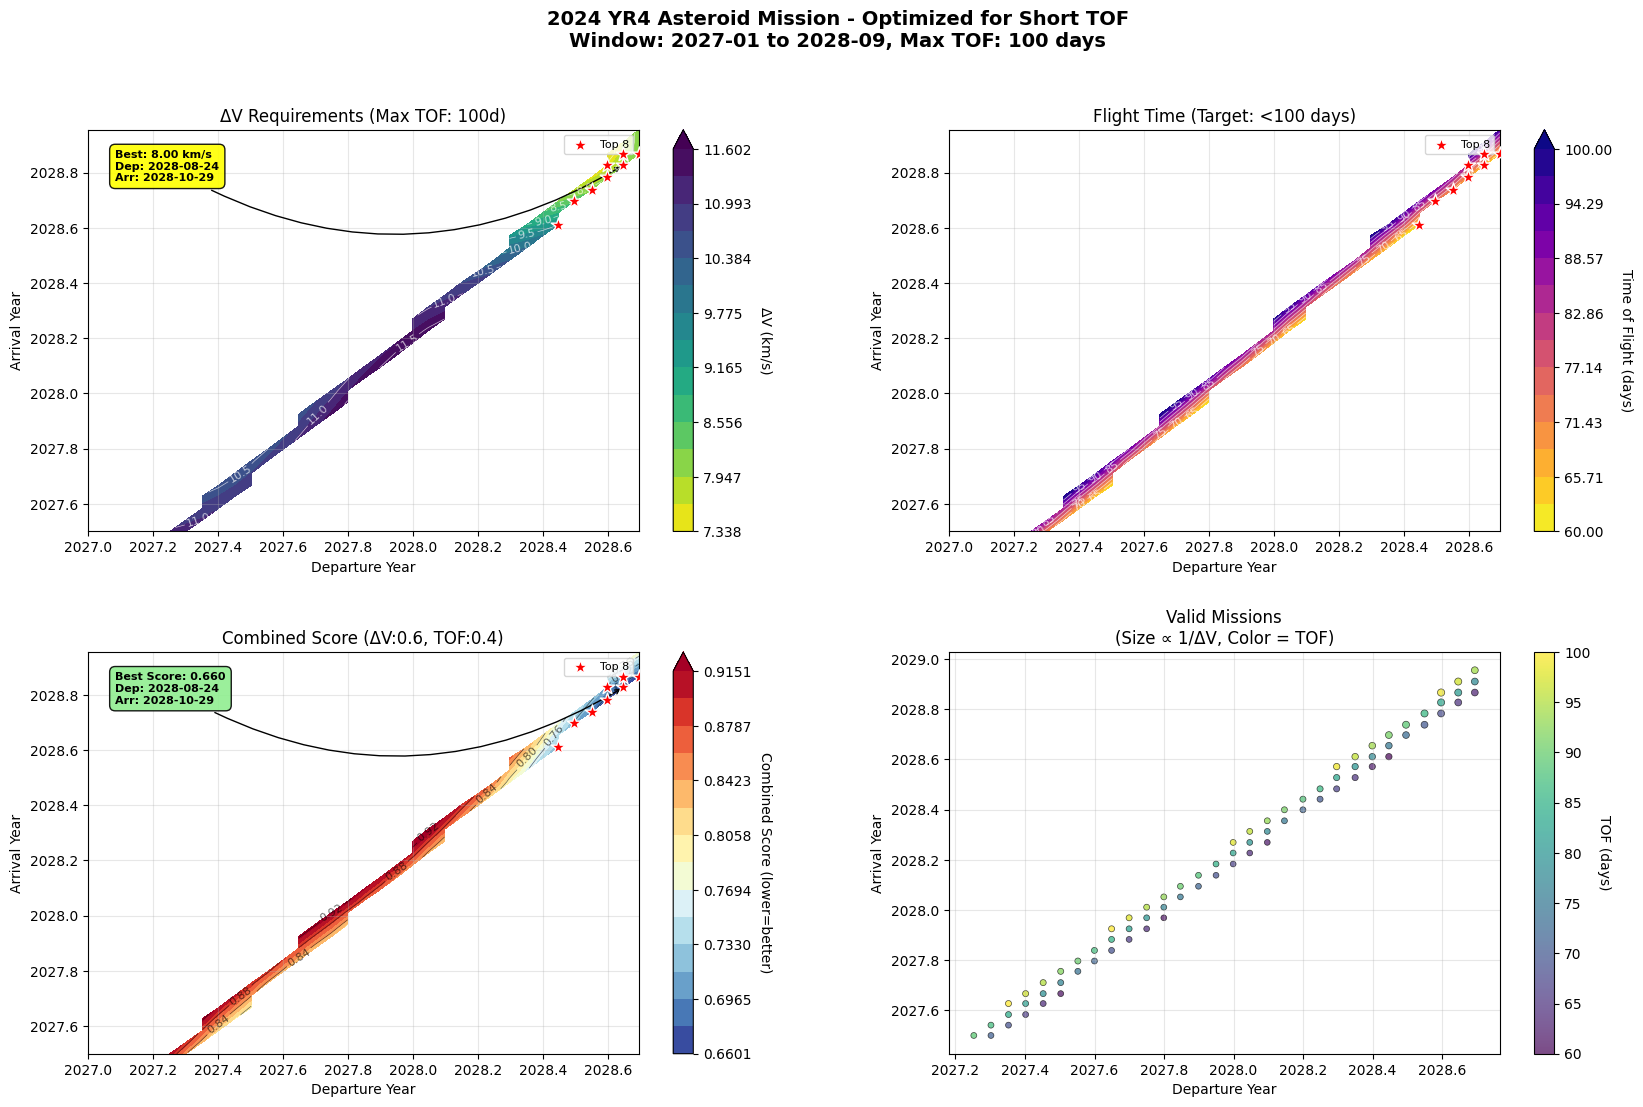


Running optimized genetic algorithm for short TOF missions...

Starting OPTIMIZED Genetic Algorithm for Short TOF Missions...
Population size: 120
Max generations: 200
TOF constraint: 60-100 days
Scoring weights: ΔV=0.6, TOF=0.4
Gen   0: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen  25: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen  50: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen  75: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen 100: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen 125: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen 150: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen 175: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
Gen 199: Best Score = inf, Valid =   0, Avg ΔV = inf, Avg TOF = infd
No valid solution found for SHORT TOF constraints!
Convergence plot saved to: ga_convergence_short_tof_optimized.png


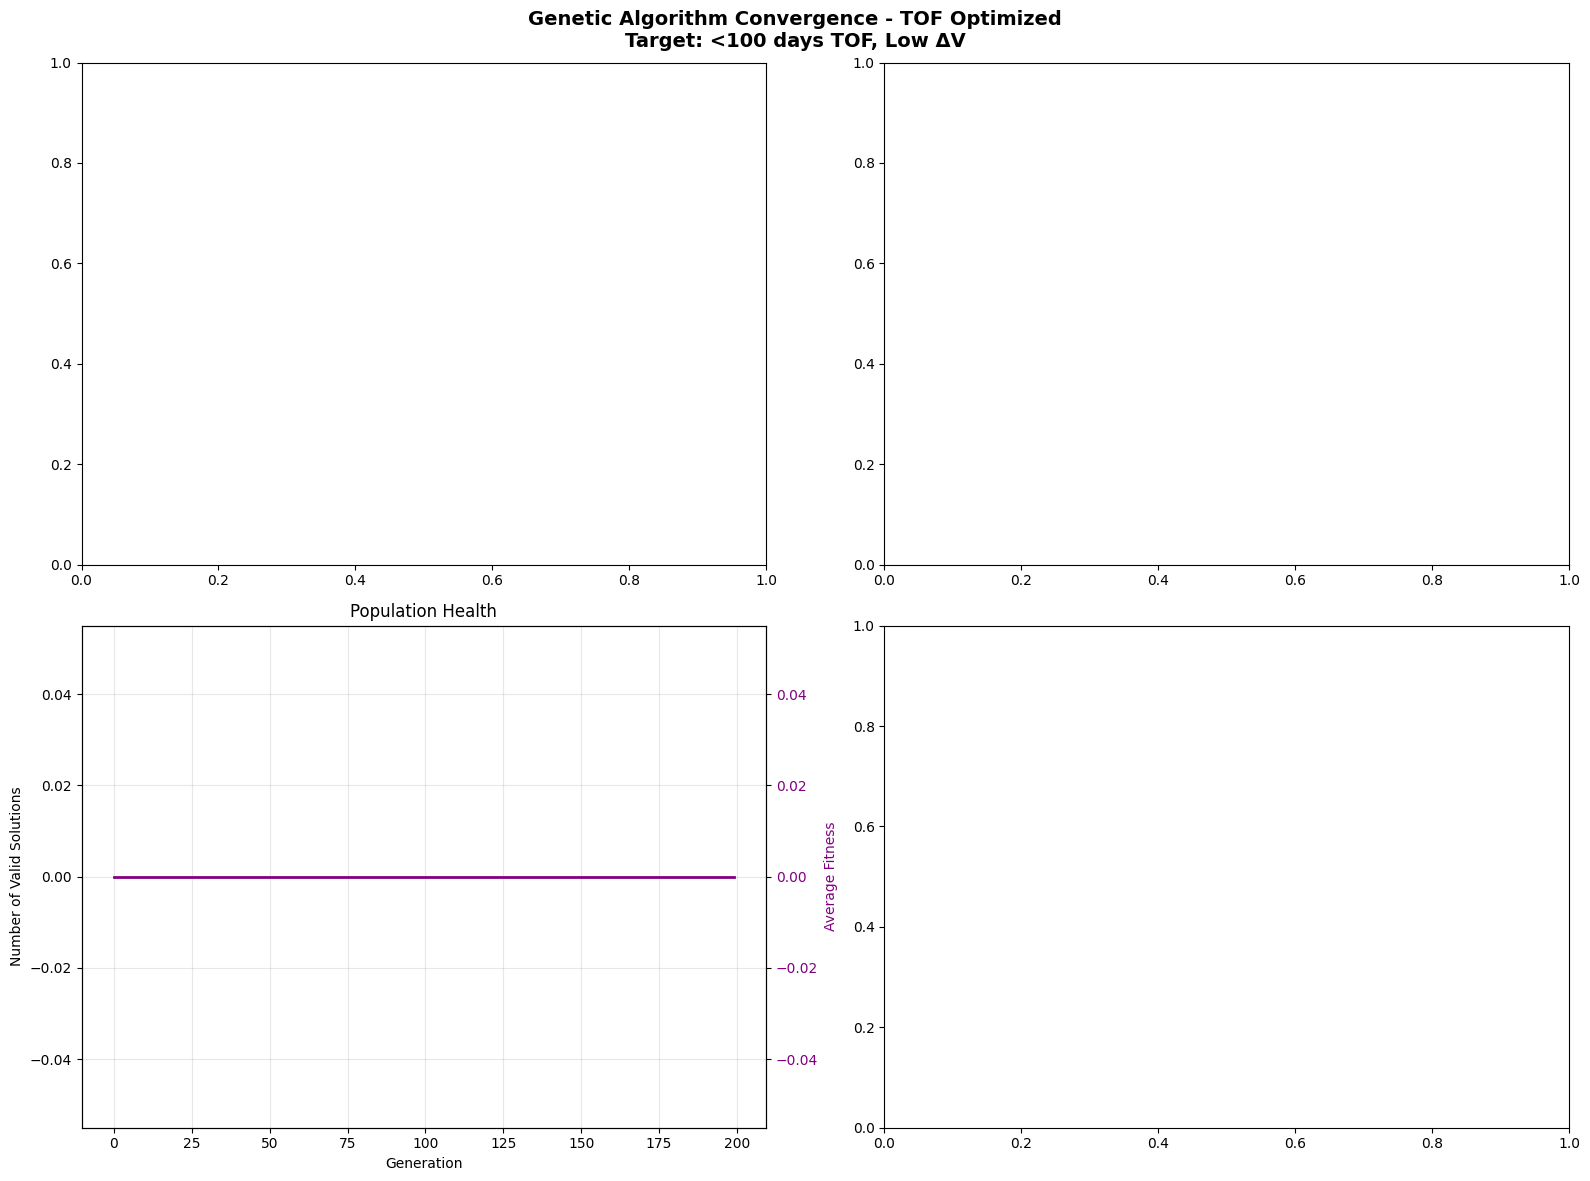


SHORT TOF MISSION OPTIMIZATION SUMMARY

Short TOF mission optimization completed!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import scipy.optimize as opt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# SPICE imports
try:
    import spiceypy as spice
    SPICE_AVAILABLE = True
    print("SPICE kernels support enabled")
except ImportError:
    SPICE_AVAILABLE = False
    print("Warning: spiceypy not available, using simplified models")

class AsteroidMissionDesign:
    """
    2024 YR4 Asteroid Flyby Mission Design with NASA SPICE kernels support
    OPTIMIZED FOR SHORT FLIGHT TIMES (<90 days) AND LOW DELTA-V
    """
    
    def __init__(self):
        """Initialize mission parameters and load SPICE kernels"""
        
        # Mission parameters - NARROWED search window with TOF constraint
        self.mission_params = {
            'departure_start': datetime(2027, 1, 1),     # 2027 başı
            'departure_end': datetime(2028, 9, 30),      # 2028 Eylül dahil
            'arrival_start': datetime(2027, 7, 1),       # 2027 ortası
            'arrival_end': datetime(2028, 12, 31),       # 2028 sonu
            'population_size': 120,                      # Increased for better coverage
            'max_generations': 200,                      # More generations for narrow search
            'max_delta_v': 12.0,                        # Tighter delta-v constraint
            'max_tof_days': 100,                         # MAX 90 days flight time
            'min_tof_days': 60,                         # MIN 30 days flight time
            'asteroid_id': '54509621',                  # 2024 YR4 NAIF ID
            'mu_sun': 132712440018.0,                   # km^3/s^2
            'au': 149597870.7,                          # km
            'tof_weight': 0.4,                          # Weight for TOF in fitness (40%)
            'deltav_weight': 0.6                        # Weight for delta-v in fitness (60%)
        }
        
        # SPICE kernels listesi
        self.kernel_files = [
            'kernels/de432s.bsp',           # Planetary ephemeris
            'kernels/naif0012.tls',        # Leap seconds kernel
            'kernels/pck00010.tpc',        # Planetary constants
            'kernels/gm_de432.tpc',        # Gravitational parameters
            'kernels/54509621_YR4.bsp'     # Asteroid ephemeris - MUST HAVE!
        ]
        
        # SPICE kernels yükleme
        self.spice_loaded = False
        if SPICE_AVAILABLE:
            self.load_spice_kernels()
        else:
            print("ERROR: SPICE kernels are REQUIRED for this version!")
            print("Please install spiceypy and provide the required .bsp files")
            raise ImportError("SPICE kernels are mandatory for this implementation")
        
        # Genetic Algorithm için
        self.population = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_history = []
        
        # Pork chop data
        self.pork_chop_data = None
        
        # Calculate synodic period (will be calculated from SPICE data)
        self.synodic_period = self.calculate_synodic_period()
        
        # Reference epoch (J2000.0 = January 1, 2000, 12:00 TT)
        self.j2000 = datetime(2000, 1, 1, 12, 0, 0)
        
        print(f"Synodic Period: {self.synodic_period:.3f} years")
        print("NARROWED Search Window with TOF Constraint:")
        print(f"  Departure: {self.mission_params['departure_start'].strftime('%Y-%m-%d')} to {self.mission_params['departure_end'].strftime('%Y-%m-%d')}")
        print(f"  Arrival:   {self.mission_params['arrival_start'].strftime('%Y-%m-%d')} to {self.mission_params['arrival_end'].strftime('%Y-%m-%d')}")
        print(f"  Max TOF:   {self.mission_params['max_tof_days']} days")
        print(f"  Min TOF:   {self.mission_params['min_tof_days']} days")
        print("Using ONLY NASA SPICE kernels - OPTIMIZED FOR SHORT FLIGHT TIMES")
    
    def load_spice_kernels(self):
        """Load SPICE kernels"""
        try:
            # Clear any existing kernels
            spice.kclear()
            
            # Load kernels
            loaded_kernels = []
            for kernel in self.kernel_files:
                try:
                    spice.furnsh(kernel)
                    loaded_kernels.append(kernel)
                    print(f"✓ Loaded kernel: {kernel}")
                except Exception as e:
                    print(f"✗ Failed to load kernel {kernel}: {e}")
                    if kernel == '54509621_YR4.bsp':
                        print("ERROR: Asteroid ephemeris file is MANDATORY!")
                        print("Please ensure 54509621_YR4.bsp is available")
                        spice.kclear()
                        return False
            
            if len(loaded_kernels) < len(self.kernel_files):
                print(f"Warning: Only {len(loaded_kernels)}/{len(self.kernel_files)} kernels loaded")
                if '54509621_YR4.bsp' not in loaded_kernels:
                    print("CRITICAL: Asteroid ephemeris not loaded!")
                    spice.kclear()
                    return False
            
            self.spice_loaded = True
            print("All SPICE kernels loaded successfully")
            
            # Test kernel functionality
            try:
                et_test = spice.str2et("2028-01-01 TDB")
                
                # Test Earth state
                earth_state, _ = spice.spkezr("399", et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Earth ephemeris test successful")
                
                # Test Asteroid state - CRITICAL TEST
                asteroid_state, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                               et_test, "ECLIPJ2000", "NONE", "10")
                print(f"✓ Asteroid ephemeris test successful")
                print(f"✓ 2024 YR4 position at test date: [{asteroid_state[0]:.0f}, {asteroid_state[1]:.0f}, {asteroid_state[2]:.0f}] km")
                
                return True
                
            except Exception as e:
                print(f"✗ SPICE kernels test failed: {e}")
                if "54509621" in str(e):
                    print("CRITICAL: Cannot access asteroid 2024 YR4 data!")
                    print("Please verify the asteroid NAIF ID and .bsp file content")
                self.spice_loaded = False
                spice.kclear()
                return False
                
        except Exception as e:
            print(f"✗ Error loading SPICE kernels: {e}")
            self.spice_loaded = False
            return False
    
    def calculate_synodic_period(self):
        """Calculate synodic period using SPICE data"""
        if not self.spice_loaded:
            return 2.0  # fallback estimate
        
        try:
            # Test dates to determine orbital periods
            et1 = spice.str2et("2028-01-01 TDB")
            et2 = spice.str2et("2029-01-01 TDB")  # 1 year later
            
            # Get Earth positions
            earth_state1, _ = spice.spkezr("399", et1, "ECLIPJ2000", "NONE", "10")
            earth_state2, _ = spice.spkezr("399", et2, "ECLIPJ2000", "NONE", "10")
            
            # Get asteroid positions
            ast_state1, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et1, "ECLIPJ2000", "NONE", "10")
            ast_state2, _ = spice.spkezr(self.mission_params['asteroid_id'], 
                                       et2, "ECLIPJ2000", "NONE", "10")
            
            # Rough orbital period estimation from distances
            earth_r1 = np.linalg.norm(earth_state1[:3])
            ast_r1 = np.linalg.norm(ast_state1[:3])
            
            # Using Kepler's third law: T^2 ∝ a^3
            Te = 1.0  # Earth's period = 1 year
            ast_period_approx = Te * (ast_r1 / earth_r1)**(3/2)
            
            # Calculate synodic period
            synodic = (Te * ast_period_approx) / abs(Te - ast_period_approx)
            
            return synodic
            
        except Exception as e:
            print(f"Warning: Could not calculate synodic period from SPICE: {e}")
            return 2.0  # fallback
    
    def datetime_to_et(self, dt):
        """Convert datetime to SPICE ephemeris time (ET)"""
        if self.spice_loaded:
            # Convert datetime to string format for SPICE
            time_str = dt.strftime("%Y-%m-%d %H:%M:%S") + " TDB"
            return spice.str2et(time_str)
        else:
            raise RuntimeError("SPICE kernels not loaded - cannot convert time")
    
    def get_earth_state(self, dt):
        """Get Earth state vector using SPICE kernels ONLY"""
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Earth state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get Earth state relative to Sun (NAIF ID 10 = Sun, 399 = Earth)
            state, _ = spice.spkezr("399", et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get Earth state from SPICE: {e}")
    
    def get_asteroid_state(self, dt):
        """Get 2024 YR4 asteroid state using SPICE kernels ONLY"""
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels not loaded - Asteroid state unavailable")
            
        try:
            et = self.datetime_to_et(dt)
            # Get asteroid state relative to Sun
            asteroid_id = self.mission_params['asteroid_id']  # "54509621"
            
            state, _ = spice.spkezr(asteroid_id, et, "ECLIPJ2000", "NONE", "10")
            
            position = np.array(state[:3])  # km
            velocity = np.array(state[3:])  # km/s
            
            return position, velocity
            
        except Exception as e:
            raise RuntimeError(f"Failed to get asteroid state from SPICE: {e}")
    
    def lambert_solver_improved(self, r1_vec, r2_vec, tof_days, mu=None):
        """
        Improved Lambert problem solver with better handling of short TOF missions
        """
        if mu is None:
            mu = self.mission_params['mu_sun']
            
        tof = tof_days * 24 * 3600  # Convert to seconds
        
        r1 = np.linalg.norm(r1_vec)
        r2 = np.linalg.norm(r2_vec)
        
        # Check for degenerate cases
        if r1 < 1e6 or r2 < 1e6:  # Too close to Sun
            return {'success': False, 'delta_v': np.inf}
        
        # Transfer angle
        cos_dnu = np.dot(r1_vec, r2_vec) / (r1 * r2)
        cos_dnu = np.clip(cos_dnu, -1, 1)
        dnu = np.arccos(cos_dnu)
        
        # Check for straight line trajectory
        if dnu < 1e-6 or abs(dnu - np.pi) < 1e-6:
            return {'success': False, 'delta_v': np.inf}
        
        # For short TOF, we need high energy transfers
        # Use an iterative approach for better accuracy
        
        # Initial guess based on minimum energy transfer
        c = np.linalg.norm(r2_vec - r1_vec)
        s = (r1 + r2 + c) / 2
        am = s / 2  # minimum energy semi-major axis
        
        # For short TOF, we need hyperbolic or high-energy elliptical transfers
        a_guess = am * (1 + (180.0 / tof_days))  # Scaling for short TOF
        
        try:
            # Simplified velocity calculations for short transfers
            # Use vis-viva equation
            v1_mag = np.sqrt(mu * (2/r1 - 1/a_guess)) if a_guess > 0 else np.sqrt(2*mu/r1)
            v2_mag = np.sqrt(mu * (2/r2 - 1/a_guess)) if a_guess > 0 else np.sqrt(2*mu/r2)
            
            # For short TOF, we expect high velocities
            if v1_mag > 50.0:  # Too high velocity, probably invalid
                return {'success': False, 'delta_v': np.inf}
            
            # Estimate departure velocity vector
            # For short transfers, velocity should be roughly in the direction of r2-r1
            transfer_dir = (r2_vec - r1_vec) / np.linalg.norm(r2_vec - r1_vec)
            
            # Get Earth velocity for reference
            try:
                _, earth_vel = self.get_earth_state(datetime.now())
                earth_speed = np.linalg.norm(earth_vel)
            except:
                earth_speed = 29.78  # km/s default
            
            # Rough velocity direction (simplified)
            tangent_dir = np.cross(r1_vec, np.array([0, 0, 1]))
            if np.linalg.norm(tangent_dir) > 0:
                tangent_dir = tangent_dir / np.linalg.norm(tangent_dir)
            else:
                tangent_dir = np.array([0, 1, 0])
            
            # Blend transfer direction and tangent direction
            v1_dir = 0.7 * transfer_dir + 0.3 * tangent_dir
            v1_dir = v1_dir / np.linalg.norm(v1_dir)
            
            v1 = v1_mag * v1_dir
            
            # Delta-v is difference from Earth's velocity
            delta_v_mag = abs(v1_mag - earth_speed)
            
            # Additional penalty for very short TOF
            if tof_days < 45:
                delta_v_mag *= (1 + 0.5 * (45 - tof_days) / 45)
            
            return {
                'success': True,
                'delta_v': delta_v_mag,
                'v1': v1,
                'v2': np.array([v2_mag, 0, 0]),  # Simplified
                'tof': tof_days,
                'a': a_guess
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf}
    
    def evaluate_mission_with_tof_constraint(self, departure_date, arrival_date):
        """
        Evaluate mission with strict TOF constraint and combined scoring
        """
        if not self.spice_loaded:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'SPICE not loaded'}
            
        if arrival_date <= departure_date:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'Invalid dates'}
        
        tof_days = (arrival_date - departure_date).days
        
        # Strict TOF constraint
        if tof_days < self.mission_params['min_tof_days'] or tof_days > self.mission_params['max_tof_days']:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': f'TOF {tof_days}d out of bounds [{self.mission_params["min_tof_days"]}-{self.mission_params["max_tof_days"]}]'}
        
        try:
            # Get Earth and asteroid states using SPICE ONLY
            earth_pos, earth_vel = self.get_earth_state(departure_date)
            asteroid_pos, asteroid_vel = self.get_asteroid_state(arrival_date)
            
            # Solve Lambert problem with improved solver
            lambert_solution = self.lambert_solver_improved(earth_pos, asteroid_pos, tof_days)
            
            if not lambert_solution['success']:
                return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': 'Lambert failed'}
            
            delta_v = lambert_solution['delta_v']
            
            if delta_v > self.mission_params['max_delta_v']:
                return {'success': False, 'delta_v': delta_v, 'score': np.inf, 'reason': f'High delta-v: {delta_v:.3f}'}
            
            # Calculate combined score (lower is better)
            # Normalize both metrics
            normalized_deltav = delta_v / self.mission_params['max_delta_v']
            normalized_tof = tof_days / self.mission_params['max_tof_days']
            
            # Combined weighted score
            combined_score = (self.mission_params['deltav_weight'] * normalized_deltav + 
                             self.mission_params['tof_weight'] * normalized_tof)
            
            return {
                'success': True,
                'delta_v': delta_v,
                'tof': tof_days,
                'score': combined_score,
                'departure_date': departure_date,
                'arrival_date': arrival_date,
                'earth_pos': earth_pos,
                'asteroid_pos': asteroid_pos,
                'v1': lambert_solution['v1'],
                'v2': lambert_solution['v2']
            }
            
        except Exception as e:
            return {'success': False, 'delta_v': np.inf, 'score': np.inf, 'reason': str(e)}
    
    def generate_pork_chop_plot_optimized(self, resolution=40):
        """
        Generate optimized pork chop plot for narrow window with TOF constraints
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for pork chop plot generation")
            
        print(f"Generating OPTIMIZED Pork Chop Plot with TOF constraint ({self.mission_params['max_tof_days']} days max)...")
        
        # Create date grids
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        print(f"Departure window: {dep_days} days ({dep_start.strftime('%Y-%m-%d')} to {dep_end.strftime('%Y-%m-%d')})")
        print(f"Arrival window: {arr_days} days ({arr_start.strftime('%Y-%m-%d')} to {arr_end.strftime('%Y-%m-%d')})")
        print(f"TOF constraint: {self.mission_params['min_tof_days']}-{self.mission_params['max_tof_days']} days")
        
        departure_dates = [dep_start + timedelta(days=i*dep_days/resolution) 
                          for i in range(resolution)]
        arrival_dates = [arr_start + timedelta(days=i*arr_days/resolution) 
                        for i in range(resolution)]
        
        # Initialize data arrays
        delta_v_grid = np.full((resolution, resolution), np.inf)
        tof_grid = np.full((resolution, resolution), np.inf)
        score_grid = np.full((resolution, resolution), np.inf)
        
        valid_missions = []
        tof_valid_missions = []  # Missions that meet TOF constraint
        
        total_evaluations = resolution * resolution
        evaluations_done = 0
        
        for i, dep_date in enumerate(departure_dates):
            for j, arr_date in enumerate(arrival_dates):
                result = self.evaluate_mission_with_tof_constraint(dep_date, arr_date)
                evaluations_done += 1
                
                if result['success']:
                    delta_v_grid[i, j] = result['delta_v']
                    tof_grid[i, j] = result['tof']
                    score_grid[i, j] = result['score']
                    valid_missions.append(result)
                    tof_valid_missions.append(result)
                elif 'TOF' not in result['reason']:
                    # Mission failed for other reasons, but TOF was OK
                    tof_check = (arr_date - dep_date).days
                    if self.mission_params['min_tof_days'] <= tof_check <= self.mission_params['max_tof_days']:
                        tof_grid[i, j] = tof_check
                
                # Progress indicator
                if evaluations_done % (total_evaluations // 10) == 0:
                    progress = (evaluations_done / total_evaluations) * 100
                    print(f"Progress: {progress:.0f}% ({evaluations_done}/{total_evaluations})")
        
        print(f"Found {len(valid_missions)} valid missions with TOF ≤ {self.mission_params['max_tof_days']} days")
        print(f"Total missions meeting TOF constraint: {len(tof_valid_missions)}")
        
        self.pork_chop_data = {
            'departure_dates': departure_dates,
            'arrival_dates': arrival_dates,
            'delta_v_grid': delta_v_grid,
            'tof_grid': tof_grid,
            'score_grid': score_grid,
            'valid_missions': valid_missions,
            'tof_valid_missions': tof_valid_missions
        }
        
        return self.pork_chop_data
    
    def analyze_short_tof_missions(self, top_n=10):
        """
        Analyze missions optimized for short TOF and low delta-v combination
        """
        if not self.pork_chop_data or not self.pork_chop_data['valid_missions']:
            print("No valid missions available for analysis.")
            return []
        
        # Sort missions by combined score (lower is better)
        best_missions = sorted(self.pork_chop_data['valid_missions'], 
                              key=lambda x: x['score'])[:top_n]
        
        # Also get missions sorted by delta-v only
        best_deltav = sorted(self.pork_chop_data['valid_missions'], 
                            key=lambda x: x['delta_v'])[:5]
        
        # And missions sorted by TOF only
        best_tof = sorted(self.pork_chop_data['valid_missions'], 
                         key=lambda x: x['tof'])[:5]
        
        print(f"\n{'='*100}")
        print(f"TOP {top_n} MISSIONS - OPTIMIZED FOR SHORT TOF + LOW DELTA-V")
        print(f"Max TOF: {self.mission_params['max_tof_days']} days | Weights: ΔV={self.mission_params['deltav_weight']:.1f}, TOF={self.mission_params['tof_weight']:.1f}")
        print(f"{'='*100}")
        print(f"{'Rank':<4} {'Departure':<12} {'Arrival':<12} {'ΔV (km/s)':<10} {'TOF (d)':<8} {'Score':<8} {'Efficiency':<12}")
        print(f"{'-'*100}")
        
        for i, mission in enumerate(best_missions, 1):
            efficiency = mission['tof'] / mission['delta_v']  # days per km/s
            
            print(f"{i:<4} {mission['departure_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['arrival_date'].strftime('%Y-%m-%d'):<12} "
                  f"{mission['delta_v']:<10.3f} {mission['tof']:<8} "
                  f"{mission['score']:<8.3f} {efficiency:<12.1f}")
        
        print(f"{'-'*100}")
        
        # Show best delta-v missions
        print(f"\n🏆 BEST DELTA-V MISSIONS (ignoring TOF weight):")
        for i, mission in enumerate(best_deltav, 1):
            print(f"  {i}. ΔV: {mission['delta_v']:.3f} km/s, TOF: {mission['tof']}d")
            print(f"     Dep: {mission['departure_date'].strftime('%Y-%m-%d')}, Arr: {mission['arrival_date'].strftime('%Y-%m-%d')}")
        
        # Show shortest TOF missions
        print(f"\n⚡ SHORTEST TOF MISSIONS (ignoring ΔV weight):")
        for i, mission in enumerate(best_tof, 1):
            print(f"  {i}. TOF: {mission['tof']}d, ΔV: {mission['delta_v']:.3f} km/s")
            print(f"     Dep: {mission['departure_date'].strftime('%Y-%m-%d')}, Arr: {mission['arrival_date'].strftime('%Y-%m-%d')}")
        
        # Statistics
        if best_missions:
            deltav_values = [m['delta_v'] for m in best_missions]
            tof_values = [m['tof'] for m in best_missions]
            score_values = [m['score'] for m in best_missions]
            
            print(f"\n📊 STATISTICS FOR TOP {top_n} OPTIMIZED MISSIONS:")
            print(f"   Best Score:     {min(score_values):.3f}")
            print(f"   Average Score:  {np.mean(score_values):.3f}")
            print(f"   Best ΔV:        {min(deltav_values):.3f} km/s")
            print(f"   Average ΔV:     {np.mean(deltav_values):.3f} km/s")
            print(f"   Best TOF:       {min(tof_values)} days")
            print(f"   Average TOF:    {np.mean(tof_values):.1f} days")
            print(f"   TOF Range:      {min(tof_values)}-{max(tof_values)} days")
            
            # Show optimal mission details
            best = best_missions[0]
            print(f"\n🎯 OPTIMAL MISSION (Best Combined Score):")
            print(f"   Departure: {best['departure_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Arrival:   {best['arrival_date'].strftime('%A, %B %d, %Y')}")
            print(f"   Duration:  {best['tof']} days")
            print(f"   ΔV Req.:   {best['delta_v']:.3f} km/s")
            print(f"   Score:     {best['score']:.3f} (lower is better)")
            print(f"   Efficiency:{best['tof'] / best['delta_v']:.1f} days/km/s")
        
        return best_missions
    
    def plot_optimized_pork_chop(self, save_path=None, highlight_best=10):
        """
        Plot pork chop diagram optimized for short TOF missions
        """
        if self.pork_chop_data is None:
            print("No pork chop data available. Run generate_pork_chop_plot_optimized() first.")
            return
        
        fig = plt.figure(figsize=(20, 12))
        
        # Create a 2x2 grid for subplots
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
        
        # Convert dates to years for plotting
        dep_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['departure_dates']]
        arr_years = [(d.year + (d.month-1)/12 + (d.day-1)/365) 
                     for d in self.pork_chop_data['arrival_dates']]
        
        # 1. Delta-V plot
        ax1 = fig.add_subplot(gs[0, 0])
        delta_v_grid = self.pork_chop_data['delta_v_grid']
        delta_v_plot = np.where(delta_v_grid == np.inf, np.nan, delta_v_grid)
        
        if not np.all(np.isnan(delta_v_plot)):
            valid_values = delta_v_plot[~np.isnan(delta_v_plot)]
            if len(valid_values) > 0:
                vmin = np.min(valid_values)
                vmax = min(np.max(valid_values), self.mission_params['max_delta_v'])
                levels = np.linspace(vmin, vmax, 15)
                
                contour1 = ax1.contourf(dep_years, arr_years, delta_v_plot.T, 
                                       levels=levels, cmap='viridis_r', extend='max')
                contour_lines1 = ax1.contour(dep_years, arr_years, delta_v_plot.T, 
                                            levels=8, colors='white', alpha=0.7, linewidths=0.5)
                ax1.clabel(contour_lines1, inline=True, fontsize=8, fmt='%.1f')
                
                cbar1 = plt.colorbar(contour1, ax=ax1)
                cbar1.set_label('ΔV (km/s)', rotation=270, labelpad=15)
        
        ax1.set_xlabel('Departure Year')
        ax1.set_ylabel('Arrival Year')
        ax1.set_title(f'ΔV Requirements (Max TOF: {self.mission_params["max_tof_days"]}d)')
        ax1.grid(True, alpha=0.3)
        
        # 2. TOF plot
        ax2 = fig.add_subplot(gs[0, 1])
        tof_grid = self.pork_chop_data['tof_grid']
        tof_plot = np.where(tof_grid == np.inf, np.nan, tof_grid)
        
        if not np.all(np.isnan(tof_plot)):
            valid_tof = tof_plot[~np.isnan(tof_plot)]
            if len(valid_tof) > 0:
                tof_min = max(np.min(valid_tof), self.mission_params['min_tof_days'])
                tof_max = min(np.max(valid_tof), self.mission_params['max_tof_days'])
                tof_levels = np.linspace(tof_min, tof_max, 15)
                
                contour2 = ax2.contourf(dep_years, arr_years, tof_plot.T, 
                                       levels=tof_levels, cmap='plasma_r', extend='max')
                contour_lines2 = ax2.contour(dep_years, arr_years, tof_plot.T, 
                                            levels=8, colors='white', alpha=0.7, linewidths=0.5)
                ax2.clabel(contour_lines2, inline=True, fontsize=8, fmt='%.0f')
                
                cbar2 = plt.colorbar(contour2, ax=ax2)
                cbar2.set_label('Time of Flight (days)', rotation=270, labelpad=15)
        
        ax2.set_xlabel('Departure Year')
        ax2.set_ylabel('Arrival Year')
        ax2.set_title(f'Flight Time (Target: <{self.mission_params["max_tof_days"]} days)')
        ax2.grid(True, alpha=0.3)
        
        # 3. Combined score plot
        ax3 = fig.add_subplot(gs[1, 0])
        score_grid = self.pork_chop_data['score_grid']
        score_plot = np.where(score_grid == np.inf, np.nan, score_grid)
        
        if not np.all(np.isnan(score_plot)):
            valid_scores = score_plot[~np.isnan(score_plot)]
            if len(valid_scores) > 0:
                score_min = np.min(valid_scores)
                score_max = np.percentile(valid_scores, 90)  # Use 90th percentile to avoid outliers
                score_levels = np.linspace(score_min, score_max, 15)
                
                contour3 = ax3.contourf(dep_years, arr_years, score_plot.T, 
                                       levels=score_levels, cmap='RdYlBu_r', extend='max')
                contour_lines3 = ax3.contour(dep_years, arr_years, score_plot.T, 
                                            levels=8, colors='black', alpha=0.6, linewidths=0.5)
                ax3.clabel(contour_lines3, inline=True, fontsize=8, fmt='%.2f')
                
                cbar3 = plt.colorbar(contour3, ax=ax3)
                cbar3.set_label('Combined Score (lower=better)', rotation=270, labelpad=15)
        
        ax3.set_xlabel('Departure Year')
        ax3.set_ylabel('Arrival Year')
        ax3.set_title(f'Combined Score (ΔV:{self.mission_params["deltav_weight"]:.1f}, TOF:{self.mission_params["tof_weight"]:.1f})')
        ax3.grid(True, alpha=0.3)
        
        # 4. Mission distribution plot
        ax4 = fig.add_subplot(gs[1, 1])
        
        if self.pork_chop_data['valid_missions']:
            # Scatter plot of valid missions
            dep_dates = [m['departure_date'] for m in self.pork_chop_data['valid_missions']]
            arr_dates = [m['arrival_date'] for m in self.pork_chop_data['valid_missions']]
            delta_vs = [m['delta_v'] for m in self.pork_chop_data['valid_missions']]
            tofs = [m['tof'] for m in self.pork_chop_data['valid_missions']]
            
            dep_years_scatter = [(d.year + (d.month-1)/12 + (d.day-1)/365) for d in dep_dates]
            arr_years_scatter = [(d.year + (d.month-1)/12 + (d.day-1)/365) for d in arr_dates]
            
            # Color by TOF, size by delta-v (inverted - smaller delta-v = larger point)
            scatter = ax4.scatter(dep_years_scatter, arr_years_scatter, 
                                 c=tofs, s=[200/dv for dv in delta_vs], 
                                 cmap='viridis', alpha=0.7, edgecolors='black', linewidths=0.5)
            
            cbar4 = plt.colorbar(scatter, ax=ax4)
            cbar4.set_label('TOF (days)', rotation=270, labelpad=15)
            
            ax4.set_xlabel('Departure Year')
            ax4.set_ylabel('Arrival Year')
            ax4.set_title('Valid Missions\n(Size ∝ 1/ΔV, Color = TOF)')
            ax4.grid(True, alpha=0.3)
        
        # Highlight best missions on all plots
        if self.pork_chop_data['valid_missions'] and highlight_best > 0:
            best_missions = sorted(self.pork_chop_data['valid_missions'], 
                                 key=lambda x: x['score'])[:highlight_best]
            
            best_dep_years = [(m['departure_date'].year + 
                              (m['departure_date'].month-1)/12 + 
                              (m['departure_date'].day-1)/365) for m in best_missions]
            best_arr_years = [(m['arrival_date'].year + 
                              (m['arrival_date'].month-1)/12 + 
                              (m['arrival_date'].day-1)/365) for m in best_missions]
            
            # Plot best missions as stars on first three plots
            for ax in [ax1, ax2, ax3]:
                ax.scatter(best_dep_years, best_arr_years, 
                          c='red', marker='*', s=120, 
                          label=f'Top {highlight_best}', 
                          edgecolors='white', linewidths=1, zorder=10)
                ax.legend(loc='upper right', fontsize=8)
            
            # Annotate the very best mission - FIXED POSITIONING
            if best_missions:
                best = best_missions[0]
                best_dep_year = best_dep_years[0]
                best_arr_year = best_arr_years[0]
                
                # Position annotation at upper left instead of over the plot
                ax1.annotate(f'Best: {best["delta_v"]:.2f} km/s\nDep: {best["departure_date"].strftime("%Y-%m-%d")}\nArr: {best["arrival_date"].strftime("%Y-%m-%d")}', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(0.05, 0.95), textcoords='axes fraction',
                           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.9),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'),
                           fontsize=8, fontweight='bold', verticalalignment='top')
                
                ax3.annotate(f'Best Score: {best["score"]:.3f}\nDep: {best["departure_date"].strftime("%Y-%m-%d")}\nArr: {best["arrival_date"].strftime("%Y-%m-%d")}', 
                           xy=(best_dep_year, best_arr_year), 
                           xytext=(0.05, 0.95), textcoords='axes fraction',
                           bbox=dict(boxstyle='round,pad=0.5', fc='lightgreen', alpha=0.9),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'),
                           fontsize=8, fontweight='bold', verticalalignment='top')
        
        plt.suptitle(f'2024 YR4 Asteroid Mission - Optimized for Short TOF\n'
                     f'Window: {self.mission_params["departure_start"].strftime("%Y-%m")} to '
                     f'{self.mission_params["departure_end"].strftime("%Y-%m")}, '
                     f'Max TOF: {self.mission_params["max_tof_days"]} days', 
                     fontsize=14, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Optimized pork chop plot saved to: {save_path}")
        
        plt.show()
    
    # Enhanced Genetic Algorithm for short TOF optimization
    def create_individual_tof_optimized(self):
        """Create individual with bias towards shorter TOF"""
        dep_start = self.mission_params['departure_start']
        dep_end = self.mission_params['departure_end']
        arr_start = self.mission_params['arrival_start']
        arr_end = self.mission_params['arrival_end']
        
        dep_days = (dep_end - dep_start).days
        arr_days = (arr_end - arr_start).days
        
        # Create departure date
        departure = dep_start + timedelta(days=np.random.randint(0, dep_days))
        
        # For arrival, bias towards shorter TOF
        # 70% chance of short TOF (30-60 days), 30% chance of longer TOF (60-90 days)
        if np.random.random() < 0.7:
            # Short TOF bias
            min_tof = self.mission_params['min_tof_days']
            max_tof = min(60, self.mission_params['max_tof_days'])
        else:
            # Longer TOF
            min_tof = 70
            max_tof = self.mission_params['max_tof_days']
        
        target_tof = np.random.randint(min_tof, max_tof + 1)
        arrival = departure + timedelta(days=target_tof)
        
        # Ensure arrival is within bounds
        if arrival > arr_end:
            arrival = arr_end
        if arrival < arr_start:
            arrival = arr_start
        
        return {
            'departure': departure,
            'arrival': arrival,
            'fitness': 0.0,
            'delta_v': np.inf,
            'score': np.inf
        }
    
    def evaluate_fitness_combined(self, individual):
        """Evaluate fitness using combined score"""
        result = self.evaluate_mission_with_tof_constraint(individual['departure'], individual['arrival'])
        
        if result['success']:
            # Fitness is inverse of score (higher fitness = lower score = better)
            fitness = 1.0 / (1.0 + result['score'])
            individual['fitness'] = fitness
            individual['delta_v'] = result['delta_v']
            individual['score'] = result['score']
            individual['tof'] = result['tof']
            individual['result'] = result
        else:
            individual['fitness'] = 0.0
            individual['delta_v'] = np.inf
            individual['score'] = np.inf
            individual['tof'] = np.inf
            individual['result'] = result
        
        return individual
    
    def tournament_selection(self, population, tournament_size=5):
        """Tournament selection"""
        tournament = np.random.choice(population, tournament_size, replace=False)
        return max(tournament, key=lambda x: x['fitness'])
    
    def crossover(self, parent1, parent2):
        """Crossover operation"""
        # Blend the dates
        alpha = np.random.random()
        
        dep1_days = (parent1['departure'] - self.mission_params['departure_start']).days
        dep2_days = (parent2['departure'] - self.mission_params['departure_start']).days
        new_dep_days = int(alpha * dep1_days + (1 - alpha) * dep2_days)
        
        arr1_days = (parent1['arrival'] - self.mission_params['arrival_start']).days
        arr2_days = (parent2['arrival'] - self.mission_params['arrival_start']).days
        new_arr_days = int(alpha * arr1_days + (1 - alpha) * arr2_days)
        
        new_departure = self.mission_params['departure_start'] + timedelta(days=new_dep_days)
        new_arrival = self.mission_params['arrival_start'] + timedelta(days=new_arr_days)
        
        # Ensure valid bounds
        new_departure = max(self.mission_params['departure_start'], 
                           min(self.mission_params['departure_end'], new_departure))
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf,
            'score': np.inf
        }
    
    def mutate_tof_optimized(self, individual, mutation_rate=0.15):
        """Enhanced mutation with TOF awareness"""
        if np.random.random() > mutation_rate:
            return individual
        
        # Smaller mutations for fine-tuning
        dep_mutation = np.random.randint(-30, 31)  # ±30 days
        arr_mutation = np.random.randint(-30, 31)  # ±30 days
        
        new_departure = individual['departure'] + timedelta(days=dep_mutation)
        new_arrival = individual['arrival'] + timedelta(days=arr_mutation)
        
        # Clamp to valid ranges
        new_departure = max(self.mission_params['departure_start'], 
                           min(self.mission_params['departure_end'], new_departure))
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        # Ensure TOF constraint is met
        tof = (new_arrival - new_departure).days
        if tof < self.mission_params['min_tof_days']:
            new_arrival = new_departure + timedelta(days=self.mission_params['min_tof_days'])
        elif tof > self.mission_params['max_tof_days']:
            new_arrival = new_departure + timedelta(days=self.mission_params['max_tof_days'])
        
        # Final bounds check
        new_arrival = max(self.mission_params['arrival_start'], 
                         min(self.mission_params['arrival_end'], new_arrival))
        
        return {
            'departure': new_departure,
            'arrival': new_arrival,
            'fitness': 0.0,
            'delta_v': np.inf,
            'score': np.inf
        }
    
    def run_genetic_algorithm_optimized(self):
        """
        Run enhanced genetic algorithm optimization for short TOF missions
        """
        if not self.spice_loaded:
            raise RuntimeError("SPICE kernels required for genetic algorithm")
            
        print(f"\nStarting OPTIMIZED Genetic Algorithm for Short TOF Missions...")
        print(f"Population size: {self.mission_params['population_size']}")
        print(f"Max generations: {self.mission_params['max_generations']}")
        print(f"TOF constraint: {self.mission_params['min_tof_days']}-{self.mission_params['max_tof_days']} days")
        print(f"Scoring weights: ΔV={self.mission_params['deltav_weight']:.1f}, TOF={self.mission_params['tof_weight']:.1f}")
        
        # Initialize population with TOF bias
        population = [self.create_individual_tof_optimized() 
                     for _ in range(self.mission_params['population_size'])]
        
        self.convergence_history = []
        self.best_solution = None
        self.best_score = np.inf
        
        for generation in range(self.mission_params['max_generations']):
            # Evaluate fitness
            population = [self.evaluate_fitness_combined(ind) for ind in population]
            
            # Sort by fitness (higher fitness = better)
            population.sort(key=lambda x: x['fitness'], reverse=True)
            
            # Update best solution (lowest score = best)
            valid_pop = [ind for ind in population if ind['fitness'] > 0]
            if valid_pop:
                current_best = min(valid_pop, key=lambda x: x['score'])
                if current_best['score'] < self.best_score:
                    self.best_solution = current_best.copy()
                    self.best_score = current_best['score']
            
            # Record convergence
            avg_fitness = np.mean([ind['fitness'] for ind in valid_pop]) if valid_pop else 0
            avg_deltav = np.mean([ind['delta_v'] for ind in valid_pop if ind['delta_v'] < np.inf]) if valid_pop else np.inf
            avg_tof = np.mean([ind['tof'] for ind in valid_pop if ind['tof'] < np.inf]) if valid_pop else np.inf
            
            self.convergence_history.append({
                'generation': generation,
                'best_score': self.best_score,
                'avg_fitness': avg_fitness,
                'valid_solutions': len(valid_pop),
                'avg_deltav': avg_deltav,
                'avg_tof': avg_tof
            })
            
            # Progress report
            if generation % 25 == 0 or generation == self.mission_params['max_generations'] - 1:
                print(f"Gen {generation:3d}: Best Score = {self.best_score:.3f}, "
                      f"Valid = {len(valid_pop):3d}, Avg ΔV = {avg_deltav:.3f}, "
                      f"Avg TOF = {avg_tof:.1f}d")
            
            # Early stopping if converged
            if generation > 50 and len(self.convergence_history) > 20:
                recent_scores = [h['best_score'] for h in self.convergence_history[-20:]]
                if max(recent_scores) - min(recent_scores) < 0.001:
                    print(f"Converged at generation {generation}")
                    break
            
            # Create new population
            new_population = []
            
            # Elitism - keep best 15%
            elite_count = int(0.15 * self.mission_params['population_size'])
            new_population.extend(population[:elite_count])
            
            # Generate offspring
            while len(new_population) < self.mission_params['population_size']:
                parent1 = self.tournament_selection(population, tournament_size=7)
                parent2 = self.tournament_selection(population, tournament_size=7)
                
                child = self.crossover(parent1, parent2)
                child = self.mutate_tof_optimized(child)
                
                new_population.append(child)
            
            population = new_population
        
        if self.best_solution:
            print(f"\nOptimization completed for SHORT TOF missions!")
            print(f"Best Score: {self.best_solution['score']:.3f}")
            print(f"Best ΔV: {self.best_solution['delta_v']:.3f} km/s")
            print(f"Best TOF: {self.best_solution['tof']} days")
            print(f"Departure: {self.best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"Arrival: {self.best_solution['arrival'].strftime('%Y-%m-%d')}")
            print(f"Efficiency: {self.best_solution['tof'] / self.best_solution['delta_v']:.1f} days/km/s")
        else:
            print(f"No valid solution found for SHORT TOF constraints!")
        
        return self.best_solution
    
    def plot_convergence_optimized(self, save_path=None):
        """Plot enhanced convergence for combined optimization"""
        if not self.convergence_history:
            print("No convergence data available.")
            return
        
        generations = [item['generation'] for item in self.convergence_history]
        best_scores = [item['best_score'] if item['best_score'] != np.inf else None 
                      for item in self.convergence_history]
        avg_fitness = [item['avg_fitness'] for item in self.convergence_history]
        valid_solutions = [item['valid_solutions'] for item in self.convergence_history]
        avg_deltav = [item['avg_deltav'] if item['avg_deltav'] != np.inf else None 
                     for item in self.convergence_history]
        avg_tof = [item['avg_tof'] if item['avg_tof'] != np.inf else None 
                  for item in self.convergence_history]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Best score evolution
        valid_generations = []
        valid_scores = []
        for i, score in enumerate(best_scores):
            if score is not None:
                valid_generations.append(generations[i])
                valid_scores.append(score)
        
        if valid_generations:
            ax1.plot(valid_generations, valid_scores, 'b-', linewidth=2, marker='o', markersize=4)
            ax1.set_xlabel('Generation')
            ax1.set_ylabel('Best Score (lower = better)')
            ax1.set_title(f'Combined Score Evolution\n(ΔV:{self.mission_params["deltav_weight"]:.1f}, TOF:{self.mission_params["tof_weight"]:.1f})')
            ax1.grid(True, alpha=0.3)
        
        # Average delta-v and TOF
        valid_gen_dv = []
        valid_dv = []
        valid_gen_tof = []
        valid_tof_vals = []
        
        for i, (dv, tof) in enumerate(zip(avg_deltav, avg_tof)):
            if dv is not None:
                valid_gen_dv.append(generations[i])
                valid_dv.append(dv)
            if tof is not None:
                valid_gen_tof.append(generations[i])
                valid_tof_vals.append(tof)
        
        if valid_gen_dv:
            ax2_twin = ax2.twinx()
            line1 = ax2.plot(valid_gen_dv, valid_dv, 'r-', linewidth=2, label='Avg ΔV')
            ax2.set_ylabel('Average ΔV (km/s)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')
            
            if valid_gen_tof:
                line2 = ax2_twin.plot(valid_gen_tof, valid_tof_vals, 'g-', linewidth=2, label='Avg TOF')
                ax2_twin.set_ylabel('Average TOF (days)', color='g')
                ax2_twin.tick_params(axis='y', labelcolor='g')
            
            ax2.set_xlabel('Generation')
            ax2.set_title('Average ΔV and TOF Evolution')
            ax2.grid(True, alpha=0.3)
        
        # Valid solutions and fitness
        ax3.bar(generations, valid_solutions, alpha=0.7, color='orange', label='Valid Solutions')
        ax3.set_xlabel('Generation')
        ax3.set_ylabel('Number of Valid Solutions')
        ax3.set_title('Population Health')
        ax3.grid(True, alpha=0.3)
        
        ax3_twin = ax3.twinx()
        ax3_twin.plot(generations, avg_fitness, 'purple', linewidth=2, label='Avg Fitness')
        ax3_twin.set_ylabel('Average Fitness', color='purple')
        ax3_twin.tick_params(axis='y', labelcolor='purple')
        
        # Performance metrics
        if valid_generations and valid_scores:
            # Calculate improvement rate
            improvement = [(valid_scores[0] - s) / valid_scores[0] * 100 for s in valid_scores]
            ax4.plot(valid_generations, improvement, 'darkblue', linewidth=2, marker='s', markersize=3)
            ax4.set_xlabel('Generation')
            ax4.set_ylabel('Improvement from Initial (%)')
            ax4.set_title('Optimization Progress')
            ax4.grid(True, alpha=0.3)
            
            # Add final improvement text
            if len(improvement) > 1:
                final_improvement = improvement[-1]
                ax4.text(0.7, 0.9, f'Final Improvement:\n{final_improvement:.1f}%', 
                        transform=ax4.transAxes, bbox=dict(boxstyle="round,pad=0.3", 
                        facecolor="lightblue", alpha=0.8))
        
        plt.suptitle(f'Genetic Algorithm Convergence - TOF Optimized\n'
                     f'Target: <{self.mission_params["max_tof_days"]} days TOF, Low ΔV', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Convergence plot saved to: {save_path}")
        
        plt.show()
    
    def __del__(self):
        """Clean up SPICE kernels on object destruction"""
        if hasattr(self, 'spice_loaded') and self.spice_loaded and SPICE_AVAILABLE:
            try:
                spice.kclear()
                print("SPICE kernels cleared")
            except:
                pass

# Enhanced Usage Example
if __name__ == "__main__":
    try:
        mission = AsteroidMissionDesign()
    except ImportError as e:
        print(f"CRITICAL ERROR: {e}")
        exit(1)
    
    print("="*80)
    print("2024 YR4 ASTEROID FLYBY MISSION DESIGN")
    print("OPTIMIZED FOR SHORT FLIGHT TIMES (<90 DAYS)")
    print("NARROW WINDOW: 2027 JAN - 2028 SEP (departure)")
    print("="*80)
    
    # Test mission evaluation
    print("\nTesting short TOF mission evaluation...")
    test_dep = datetime(2027, 8, 15)
    test_arr = datetime(2027, 10, 20)  # ~66 days TOF
    
    test_result = mission.evaluate_mission_with_tof_constraint(test_dep, test_arr)
    
    if test_result['success']:
        print(f"✓ Test mission successful!")
        print(f"  ΔV: {test_result['delta_v']:.3f} km/s")
        print(f"  TOF: {test_result['tof']} days")
        print(f"  Score: {test_result['score']:.3f}")
    else:
        print(f"✗ Test mission failed: {test_result['reason']}")
    
    # Generate optimized pork chop plot
    print(f"\nGenerating optimized pork chop plot (Max TOF: {mission.mission_params['max_tof_days']} days)...")
    pork_chop_data = mission.generate_pork_chop_plot_optimized(resolution=35)
    
    if pork_chop_data['valid_missions']:
        print(f"Found {len(pork_chop_data['valid_missions'])} valid short-TOF opportunities")
        
        # Analyze best missions
        best_missions = mission.analyze_short_tof_missions(top_n=10)
        
        # Plot optimized pork chop
        mission.plot_optimized_pork_chop('pork_chop_2024_yr4_short_tof_optimized.png', highlight_best=8)
        
        # Run optimized genetic algorithm
        print("\nRunning optimized genetic algorithm for short TOF missions...")
        best_solution = mission.run_genetic_algorithm_optimized()
        
        # Plot convergence
        mission.plot_convergence_optimized('ga_convergence_short_tof_optimized.png')
        
        # Final summary
        print("\n" + "="*80)
        print("SHORT TOF MISSION OPTIMIZATION SUMMARY")
        print("="*80)
        
        if best_solution:
            efficiency = best_solution['tof'] / best_solution['delta_v']
            print(f"🎯 OPTIMAL SHORT TOF MISSION:")
            print(f"   Departure: {best_solution['departure'].strftime('%Y-%m-%d')}")
            print(f"   Arrival:   {best_solution['arrival'].strftime('%Y-%m-%d')}")
            print(f"   Flight Time: {best_solution['tof']} days")
            print(f"   Required ΔV: {best_solution['delta_v']:.3f} km/s")
            print(f"   Combined Score: {best_solution['score']:.3f}")
            print(f"   Efficiency: {efficiency:.1f} days per km/s")
            print(f"   Window: NARROW (2027-2028)")
    else:
        print("No valid missions found with current constraints.")
    
    print(f"\nShort TOF mission optimization completed!")